# Proyecto final: detección de fraude transaccional con aprendizaje automático

## 1. Datos generales del proyecto

**Elaborado por:** Fernando Corrales Quirós  
**Curso:** Fundamentos de Analítica de Datos  
**Dataset:** IEEE-CIS Fraud Detection  
**Enfoque de trabajo:** Este notebook establece la base metodológica y técnica del proyecto, con énfasis en la organización reproducible del entorno, la validación de rutas y la carga inicial de las fuentes de datos como soporte del análisis diagnóstico del dataset.


## 2. Contexto del problema

La detección de fraude en transacciones de comercio electrónico consiste en identificar operaciones con alta probabilidad de ser ilegítimas dentro de un flujo masivo de compras digitales. Este problema combina retos operativos, estadísticos y computacionales, ya que las organizaciones deben discriminar entre comportamiento legítimo y comportamiento anómalo en escenarios con gran volumen de datos, alta dimensionalidad y cambios constantes en los patrones de ataque.

Su relevancia es considerable porque el fraude financiero genera pérdidas económicas directas, afecta la confianza de los usuarios, incrementa costos de verificación y puede deteriorar la experiencia del cliente cuando un sistema bloquea operaciones válidas. En consecuencia, construir procesos analíticos rigurosos para comprender este tipo de datos resulta pertinente tanto desde una perspectiva académica como aplicada.

El dataset IEEE-CIS Fraud Detection es adecuado para un proyecto de maestría porque ofrece un caso realista de clasificación supervisada con volumen considerable, variedad de variables transaccionales e información complementaria de identidad. Esta combinación permite estudiar el problema con profundidad metodológica, documentar decisiones técnicas y desarrollar un flujo de trabajo reproducible como base para una lectura analítica rigurosa del conjunto de datos.


## 3. Objetivo general

Establecer una base reproducible para el análisis del problema IEEE-CIS Fraud Detection, mediante la correcta configuración del entorno de trabajo, la validación de las fuentes de datos y la carga inicial de los archivos principales, con el fin de disponer de un punto de partida técnico claro y trazable para el estudio diagnóstico del dataset.

## 4. Pregunta de investigación

¿De qué manera una preparación rigurosa del entorno, las rutas y la carga inicial de datos puede fortalecer la reproducibilidad y la trazabilidad metodológica de un proyecto orientado a la detección de fraude en transacciones de comercio electrónico?


## 5. Descripción del dataset IEEE-CIS Fraud Detection

El archivo `train_transaction.csv` contiene la información principal de las transacciones incluidas en el conjunto de entrenamiento. En esta tabla se encuentran variables asociadas con el evento transaccional, montos, atributos derivados y la variable objetivo `isFraud`, que indica si la transacción fue clasificada como fraudulenta.

El archivo `train_identity.csv` incorpora variables complementarias relacionadas con identidad y dispositivo. Estas columnas amplían el contexto de algunas transacciones y aportan información adicional para la integración y el análisis estructural del problema.

Ambas tablas se relacionan mediante la columna `TransactionID`, que actúa como identificador común entre la información transaccional y la información de identidad.

En este proyecto, `isFraud` se considera la variable objetivo de interés para el estudio supervisado del problema.

Es importante aclarar que `TransactionDT` no representa una fecha de calendario real, sino un desplazamiento temporal relativo respecto de un punto de referencia interno del dataset. Por esa razón, su interpretación debe hacerse con cautela y sin asumir equivalencia directa con fechas reales.


## 6. Configuración del entorno y rutas del proyecto

En este apartado se define una configuración inicial orientada a detectar correctamente la raíz del proyecto, construir rutas estables y validar la disponibilidad de los archivos antes de cualquier análisis.


### Nota de ejecución local y en Google Colab

Este notebook puede ejecutarse en un entorno local o en Google Colab. Para Colab, se recomienda subir o clonar el repositorio completo y colocar los archivos `train_transaction.csv` y `train_identity.csv` dentro de `data/raw/`. Si el entorno no tiene instaladas las dependencias del proyecto, puede ejecutarse la instalación desde `requirements.txt` antes de iniciar la carga de datos.


In [1]:
# Orientación de entorno: identifica si la ejecución ocurre localmente o en Google Colab.
# No instala dependencias automáticamente; solo deja claro el comando recomendado y la ubicación esperada de los CSV.
from pathlib import Path
import sys

IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()

if IN_COLAB:
    print("Entorno Google Colab detectado.")
    print("Si faltan dependencias, ejecute en una celda aparte: %pip install -r requirements.txt")
    print("Ubique train_transaction.csv y train_identity.csv en data/raw/ dentro del repositorio.")
else:
    print("Entorno local detectado. Verifique que data/raw/ contenga los archivos CSV requeridos.")


Entorno local detectado. Verifique que data/raw/ contenga los archivos CSV requeridos.


In [2]:
# Preparación de rutas: importa utilidades del sistema para localizar el repositorio de forma reproducible.
from pathlib import Path
import os
import sys

# Detección simple de entorno administrado; se usa solo para mensajes de diagnóstico, no para cambiar la lógica analítica.
IN_MANAGED_NOTEBOOK = Path("/content").exists()

# Registro del directorio actual para usarlo como punto de partida en la búsqueda del proyecto.
CURRENT_WORKDIR = Path(os.getcwd()).resolve()

# Nombre esperado del repositorio para localizar la raíz del proyecto de forma consistente.
PROJECT_NAME = "ieee-cis-fraud-detection"


# Función auxiliar para localizar la raíz del proyecto tanto en ejecución local como en entornos administrados.
def find_project_root(start_path: Path, project_name: str) -> Path:
    """Busca la raíz del proyecto recorriendo rutas probables y valida su estructura mínima."""

    # Se preparan rutas candidatas a partir del directorio actual y sus directorios padre.
    candidate_paths = [start_path, *start_path.parents]

    # También se incluyen ubicaciones frecuentes cuando el cuaderno se abre desde una raíz externa.
    candidate_paths.extend(
        [
            start_path / project_name,
            Path("/content") / project_name,
            Path("/content/drive/MyDrive") / project_name,
        ]
    )

    # Se eliminan duplicados preservando el orden original para una búsqueda limpia.
    unique_candidates = []
    seen_candidates = set()
    for candidate in candidate_paths:
        candidate = candidate.resolve()
        if candidate not in seen_candidates:
            unique_candidates.append(candidate)
            seen_candidates.add(candidate)

    # Se valida que la carpeta candidata tenga la estructura mínima esperada del proyecto.
    for candidate in unique_candidates:
        if candidate.name == project_name and (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    # Si no se encuentra la raíz, se informa de forma explícita para facilitar la corrección.
    raise FileNotFoundError(
        "No fue posible localizar la raíz del proyecto 'ieee-cis-fraud-detection'. "
        "Verifique la ruta de trabajo actual y la ubicación del repositorio."
    )


# Definición de la raíz del proyecto a partir de la búsqueda automática.
PROJECT_ROOT = find_project_root(CURRENT_WORKDIR, PROJECT_NAME)

# Definición del directorio de datos crudos que contiene las fuentes originales del proyecto.
DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Construcción explícita de las rutas de los archivos requeridos para la revisión inicial.
TRANSACTION_PATH = DATA_DIR / "train_transaction.csv"
IDENTITY_PATH = DATA_DIR / "train_identity.csv"

# Mensajes de diagnóstico para documentar el entorno y facilitar la trazabilidad de la ejecución.
print("Diagnóstico del entorno de trabajo")
print(f"- Entorno administrado detectado: {IN_MANAGED_NOTEBOOK}")
print(f"- Directorio de trabajo actual: {CURRENT_WORKDIR}")
print(f"- Raíz del proyecto detectada: {PROJECT_ROOT}")
print(f"- Directorio de datos detectado: {DATA_DIR}")
print(f"- Ruta de train_transaction.csv: {TRANSACTION_PATH}")
print(f"- Ruta de train_identity.csv: {IDENTITY_PATH}")

# Validación de existencia de los archivos antes de iniciar la carga de datos.
missing_files = [str(path) for path in [TRANSACTION_PATH, IDENTITY_PATH] if not path.exists()]

# Si falta algún archivo, se detiene la ejecución con un mensaje claro y accionable.
if missing_files:
    missing_report = "\n".join(missing_files)
    raise FileNotFoundError(
        "No se encontraron todos los archivos requeridos en 'data/raw/'. "
        f"Revise las siguientes rutas:\n{missing_report}"
    )

# Confirmación final de que la preparación de rutas quedó correctamente establecida.
print("Validación completada: los archivos requeridos están disponibles para la carga inicial.")


Diagnóstico del entorno de trabajo
- Entorno administrado detectado: False
- Directorio de trabajo actual: C:\Users\Fernando\Documents\ieee-cis-fraud-detection\notebooks
- Raíz del proyecto detectada: C:\Users\Fernando\Documents\ieee-cis-fraud-detection
- Directorio de datos detectado: C:\Users\Fernando\Documents\ieee-cis-fraud-detection\data\raw
- Ruta de train_transaction.csv: C:\Users\Fernando\Documents\ieee-cis-fraud-detection\data\raw\train_transaction.csv
- Ruta de train_identity.csv: C:\Users\Fernando\Documents\ieee-cis-fraud-detection\data\raw\train_identity.csv
Validación completada: los archivos requeridos están disponibles para la carga inicial.


In [3]:
# Importaciones principales para manipulación de datos y soporte gráfico.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de display para presentar vistas preliminares de forma clara en el notebook.
from IPython.display import display

# Configuración visual básica y no intrusiva para mantener coherencia de presentación.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Confirmación de las bibliotecas cargadas para fines de trazabilidad técnica.
print("Bibliotecas iniciales cargadas correctamente.")
print(f"- pandas: {pd.__version__}")
print(f"- numpy: {np.__version__}")


Bibliotecas iniciales cargadas correctamente.
- pandas: 3.0.2
- numpy: 2.4.4


## 7. Carga inicial de datos fuente

La siguiente celda realiza una carga preliminar de los archivos principales del conjunto de entrenamiento. El objetivo de este apartado no es profundizar en el análisis, sino verificar que los datos puedan leerse correctamente, documentar su tamaño inicial y observar una vista preliminar de su estructura.


In [4]:
# Función auxiliar para convertir el consumo de memoria a megabytes con fines descriptivos.
def memory_in_mb(dataframe: pd.DataFrame) -> float:
    """Calcula la memoria aproximada utilizada por un DataFrame en megabytes."""
    return dataframe.memory_usage(deep=True).sum() / (1024 ** 2)


# Carga del archivo principal de transacciones; contiene el universo de estudio y la variable objetivo.
df_transaction = pd.read_csv(TRANSACTION_PATH)

# Carga del archivo complementario de identidad; aporta variables de dispositivo e identidad cuando existen.
df_identity = pd.read_csv(IDENTITY_PATH)

# Reporte inicial del tamaño de cada conjunto de datos para documentar la escala del problema.
print("Dimensiones de los datasets cargados")
print(f"- train_transaction.csv: {df_transaction.shape[0]:,} filas x {df_transaction.shape[1]:,} columnas")
print(f"- train_identity.csv: {df_identity.shape[0]:,} filas x {df_identity.shape[1]:,} columnas")

# Cálculo de memoria consumida por cada DataFrame para anticipar decisiones de gestión de recursos.
transaction_memory_mb = memory_in_mb(df_transaction)
identity_memory_mb = memory_in_mb(df_identity)
print("\nMemoria aproximada utilizada por cada DataFrame")
print(f"- df_transaction: {transaction_memory_mb:,.2f} MB")
print(f"- df_identity: {identity_memory_mb:,.2f} MB")

# Selección de columnas relevantes para una referencia metodológica inicial, sin realizar integraciones adicionales.
transaction_relevant_columns = [
    column
    for column in [
        "TransactionID",
        "isFraud",
        "TransactionDT",
        "TransactionAmt",
        "ProductCD",
        "card1",
        "card4",
        "addr1",
        "addr2",
        "P_emaildomain",
        "R_emaildomain",
    ]
    if column in df_transaction.columns
]

identity_relevant_columns = [
    column
    for column in [
        "TransactionID",
        "DeviceType",
        "DeviceInfo",
        "id_12",
        "id_15",
        "id_30",
        "id_31",
        "id_33",
    ]
    if column in df_identity.columns
]

# Presentación resumida de columnas clave para orientar la lectura inicial del proyecto.
print("\nColumnas relevantes identificadas en train_transaction.csv")
print(transaction_relevant_columns)
print("\nColumnas relevantes identificadas en train_identity.csv")
print(identity_relevant_columns)

# Vista preliminar de las primeras filas para verificar la lectura correcta de la estructura tabular.
print("\nVista preliminar de train_transaction.csv")
display(df_transaction.head())

print("Vista preliminar de train_identity.csv")
display(df_identity.head())


Dimensiones de los datasets cargados
- train_transaction.csv: 590,540 filas x 394 columnas
- train_identity.csv: 144,233 filas x 41 columnas

Memoria aproximada utilizada por cada DataFrame
- df_transaction: 2,062.07 MB
- df_identity: 143.14 MB

Columnas relevantes identificadas en train_transaction.csv
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card4', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']

Columnas relevantes identificadas en train_identity.csv
['TransactionID', 'DeviceType', 'DeviceInfo', 'id_12', 'id_15', 'id_30', 'id_31', 'id_33']

Vista preliminar de train_transaction.csv


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Vista preliminar de train_identity.csv


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


## 8. Auditoría inicial del dataset unido

La auditoría inicial del dataset tiene como propósito establecer una comprensión diagnóstica del conjunto de datos ya cargado, antes de definir decisiones de preprocesamiento, selección de variables o modelado. Esta revisión permite identificar la estructura global del problema, el grado de completitud de la información y algunos patrones descriptivos de interés metodológico.

La tabla `train_transaction` se utilizará como base porque contiene el universo principal de transacciones y la variable objetivo `isFraud`, que es central para el problema de detección de fraude. La unión con `train_identity` debe realizarse mediante `TransactionID`, ya que este identificador enlaza la información transaccional con los atributos complementarios de identidad y dispositivo.

Se empleará un `left join` desde transacciones hacia identidad para preservar todas las observaciones de `train_transaction`, incluso cuando no exista información de identidad asociada. Esta decisión es coherente con una auditoría inicial, porque evita perder registros relevantes y permite cuantificar explícitamente la cobertura de la tabla complementaria.


In [5]:
# Preparación de las columnas de identidad que se usarán para verificar cobertura después de la unión.
identity_feature_columns = [column for column in df_identity.columns if column != "TransactionID"]

# Registro de dimensiones previas para documentar el efecto de la integración.
transaction_shape_before_join = df_transaction.shape
identity_shape_before_join = df_identity.shape

# Unión principal del dataset: se usa TransactionID como llave y left join para no perder transacciones etiquetadas.
df_audit = df_transaction.merge(
    df_identity,
    on="TransactionID",
    how="left",
    validate="one_to_one",
)

# Medición de cobertura: cuantifica cuántas transacciones quedan sin atributos de identidad tras la unión.
transactions_without_identity = df_audit[identity_feature_columns].isna().all(axis=1).sum()
transactions_without_identity_pct = (transactions_without_identity / len(df_audit)) * 100

# Reporte comparativo de dimensiones antes y después de la unión para asegurar trazabilidad.
print("Dimensiones antes y después de la unión")
print(
    f"- df_transaction antes de la unión: {transaction_shape_before_join[0]:,} filas x {transaction_shape_before_join[1]:,} columnas"
)
print(
    f"- df_identity antes de la unión: {identity_shape_before_join[0]:,} filas x {identity_shape_before_join[1]:,} columnas"
)
print(f"- df_audit después de la unión: {df_audit.shape[0]:,} filas x {df_audit.shape[1]:,} columnas")
print(
    f"- Transacciones sin datos de identidad: {transactions_without_identity:,} "
    f"({transactions_without_identity_pct:,.2f}%)"
)

# Identificación de tipos de variables para dimensionar el espacio de análisis antes de modelar.
numeric_columns = df_audit.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df_audit.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Cálculo de memoria total usada por el DataFrame unido para dimensionar su costo computacional.
audit_memory_mb = memory_in_mb(df_audit)

# Cálculo de faltantes: permite priorizar variables problemáticas y anticipar decisiones de depuración.
total_missing_values = int(df_audit.isna().sum().sum())
missing_count_per_column = df_audit.isna().sum().sort_values(ascending=False)
missing_percentage_per_column = (df_audit.isna().mean() * 100).sort_values(ascending=False)

# Construcción de una tabla resumen para las columnas con mayor proporción de faltantes.
missing_summary = pd.DataFrame(
    {
        "columna": missing_count_per_column.index,
        "faltantes_totales": missing_count_per_column.values,
        "porcentaje_faltantes": missing_percentage_per_column.values.round(2),
    }
)
top_missing_columns = missing_summary[missing_summary["faltantes_totales"] > 0].head(20).reset_index(drop=True)

# Construcción de una tabla resumen de tipos de datos para caracterizar la estructura del dataset unido.
dtype_summary = (
    df_audit.dtypes.astype(str)
    .value_counts()
    .rename_axis("tipo_de_dato")
    .reset_index(name="cantidad_columnas")
)

# Resumen de la variable objetivo para cuantificar el balance de clases al inicio de la auditoría.
target_distribution = (
    df_audit["isFraud"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("isFraud")
    .reset_index(name="conteo")
)
target_distribution["porcentaje"] = ((target_distribution["conteo"] / len(df_audit)) * 100).round(2)
target_distribution["categoría"] = target_distribution["isFraud"].map({0: "No fraude (0)", 1: "Fraude (1)"})

# Funciones auxiliares de formateo para mejorar la legibilidad de las tablas en el notebook.
def format_integer(value: int) -> str:
    """Convierte un entero a una cadena con separador de miles."""
    return f"{int(value):,}"


def format_decimal(value: float) -> str:
    """Convierte un valor numérico a una cadena con dos decimales."""
    return f"{float(value):,.2f}"


def format_percentage(value: float) -> str:
    """Convierte un porcentaje a una cadena legible con dos decimales."""
    return f"{float(value):,.2f}%"


# Tabla síntesis del estado estructural general del DataFrame integrado con valores formateados.
audit_overview_display = pd.DataFrame(
    {
        "métrica": [
            "Filas",
            "Columnas",
            "Columnas numéricas",
            "Columnas categóricas",
            "Memoria usada (MB)",
            "Faltantes totales",
        ],
        "valor": [
            format_integer(df_audit.shape[0]),
            format_integer(df_audit.shape[1]),
            format_integer(len(numeric_columns)),
            format_integer(len(categorical_columns)),
            format_decimal(audit_memory_mb),
            format_integer(total_missing_values),
        ],
    }
)

# Versión formateada del resumen de tipos de datos para evitar notación poco legible.
dtype_summary_display = dtype_summary.copy()
dtype_summary_display["cantidad_columnas"] = dtype_summary_display["cantidad_columnas"].map(format_integer)

# Versión formateada del top de faltantes con conteos y porcentajes legibles.
top_missing_columns_display = top_missing_columns.copy()
top_missing_columns_display["faltantes_totales"] = top_missing_columns_display["faltantes_totales"].map(format_integer)
top_missing_columns_display["porcentaje_faltantes"] = top_missing_columns_display["porcentaje_faltantes"].map(format_percentage)

# Versión formateada de la distribución de la variable objetivo para lectura directa.
target_distribution_display = target_distribution[["isFraud", "categoría", "conteo", "porcentaje"]].copy()
target_distribution_display["conteo"] = target_distribution_display["conteo"].map(format_integer)
target_distribution_display["porcentaje"] = target_distribution_display["porcentaje"].map(format_percentage)

# Presentación de las tablas resumen principales para documentar la auditoría inicial.
print("\nResumen estructural del dataset unido")
display(audit_overview_display.style.hide(axis="index"))

print("Resumen de tipos de datos")
display(dtype_summary_display.style.hide(axis="index"))

print("Top de columnas con mayor porcentaje de faltantes")
display(top_missing_columns_display.style.hide(axis="index"))

print("Distribución de la variable objetivo isFraud")
display(target_distribution_display.style.hide(axis="index"))


Dimensiones antes y después de la unión
- df_transaction antes de la unión: 590,540 filas x 394 columnas
- df_identity antes de la unión: 144,233 filas x 41 columnas
- df_audit después de la unión: 590,540 filas x 434 columnas
- Transacciones sin datos de identidad: 446,307 (75.58%)

Resumen estructural del dataset unido


métrica,valor
Filas,"590,540"
Columnas,434
Columnas numéricas,403
Columnas categóricas,31
Memoria usada (MB),"2,513.97"
Faltantes totales,"115,523,073"


Resumen de tipos de datos


tipo_de_dato,cantidad_columnas
float64,399
str,31
int64,4


Top de columnas con mayor porcentaje de faltantes


columna,faltantes_totales,porcentaje_faltantes
id_24,"585,793",99.20%
id_25,"585,408",99.13%
id_07,"585,385",99.13%
id_08,"585,385",99.13%
id_21,"585,381",99.13%
id_26,"585,377",99.13%
id_27,"585,371",99.12%
id_23,"585,371",99.12%
id_22,"585,371",99.12%
dist2,"552,913",93.63%


Distribución de la variable objetivo isFraud


isFraud,categoría,conteo,porcentaje
0,No fraude (0),"569,877",96.50%
1,Fraude (1),"20,663",3.50%


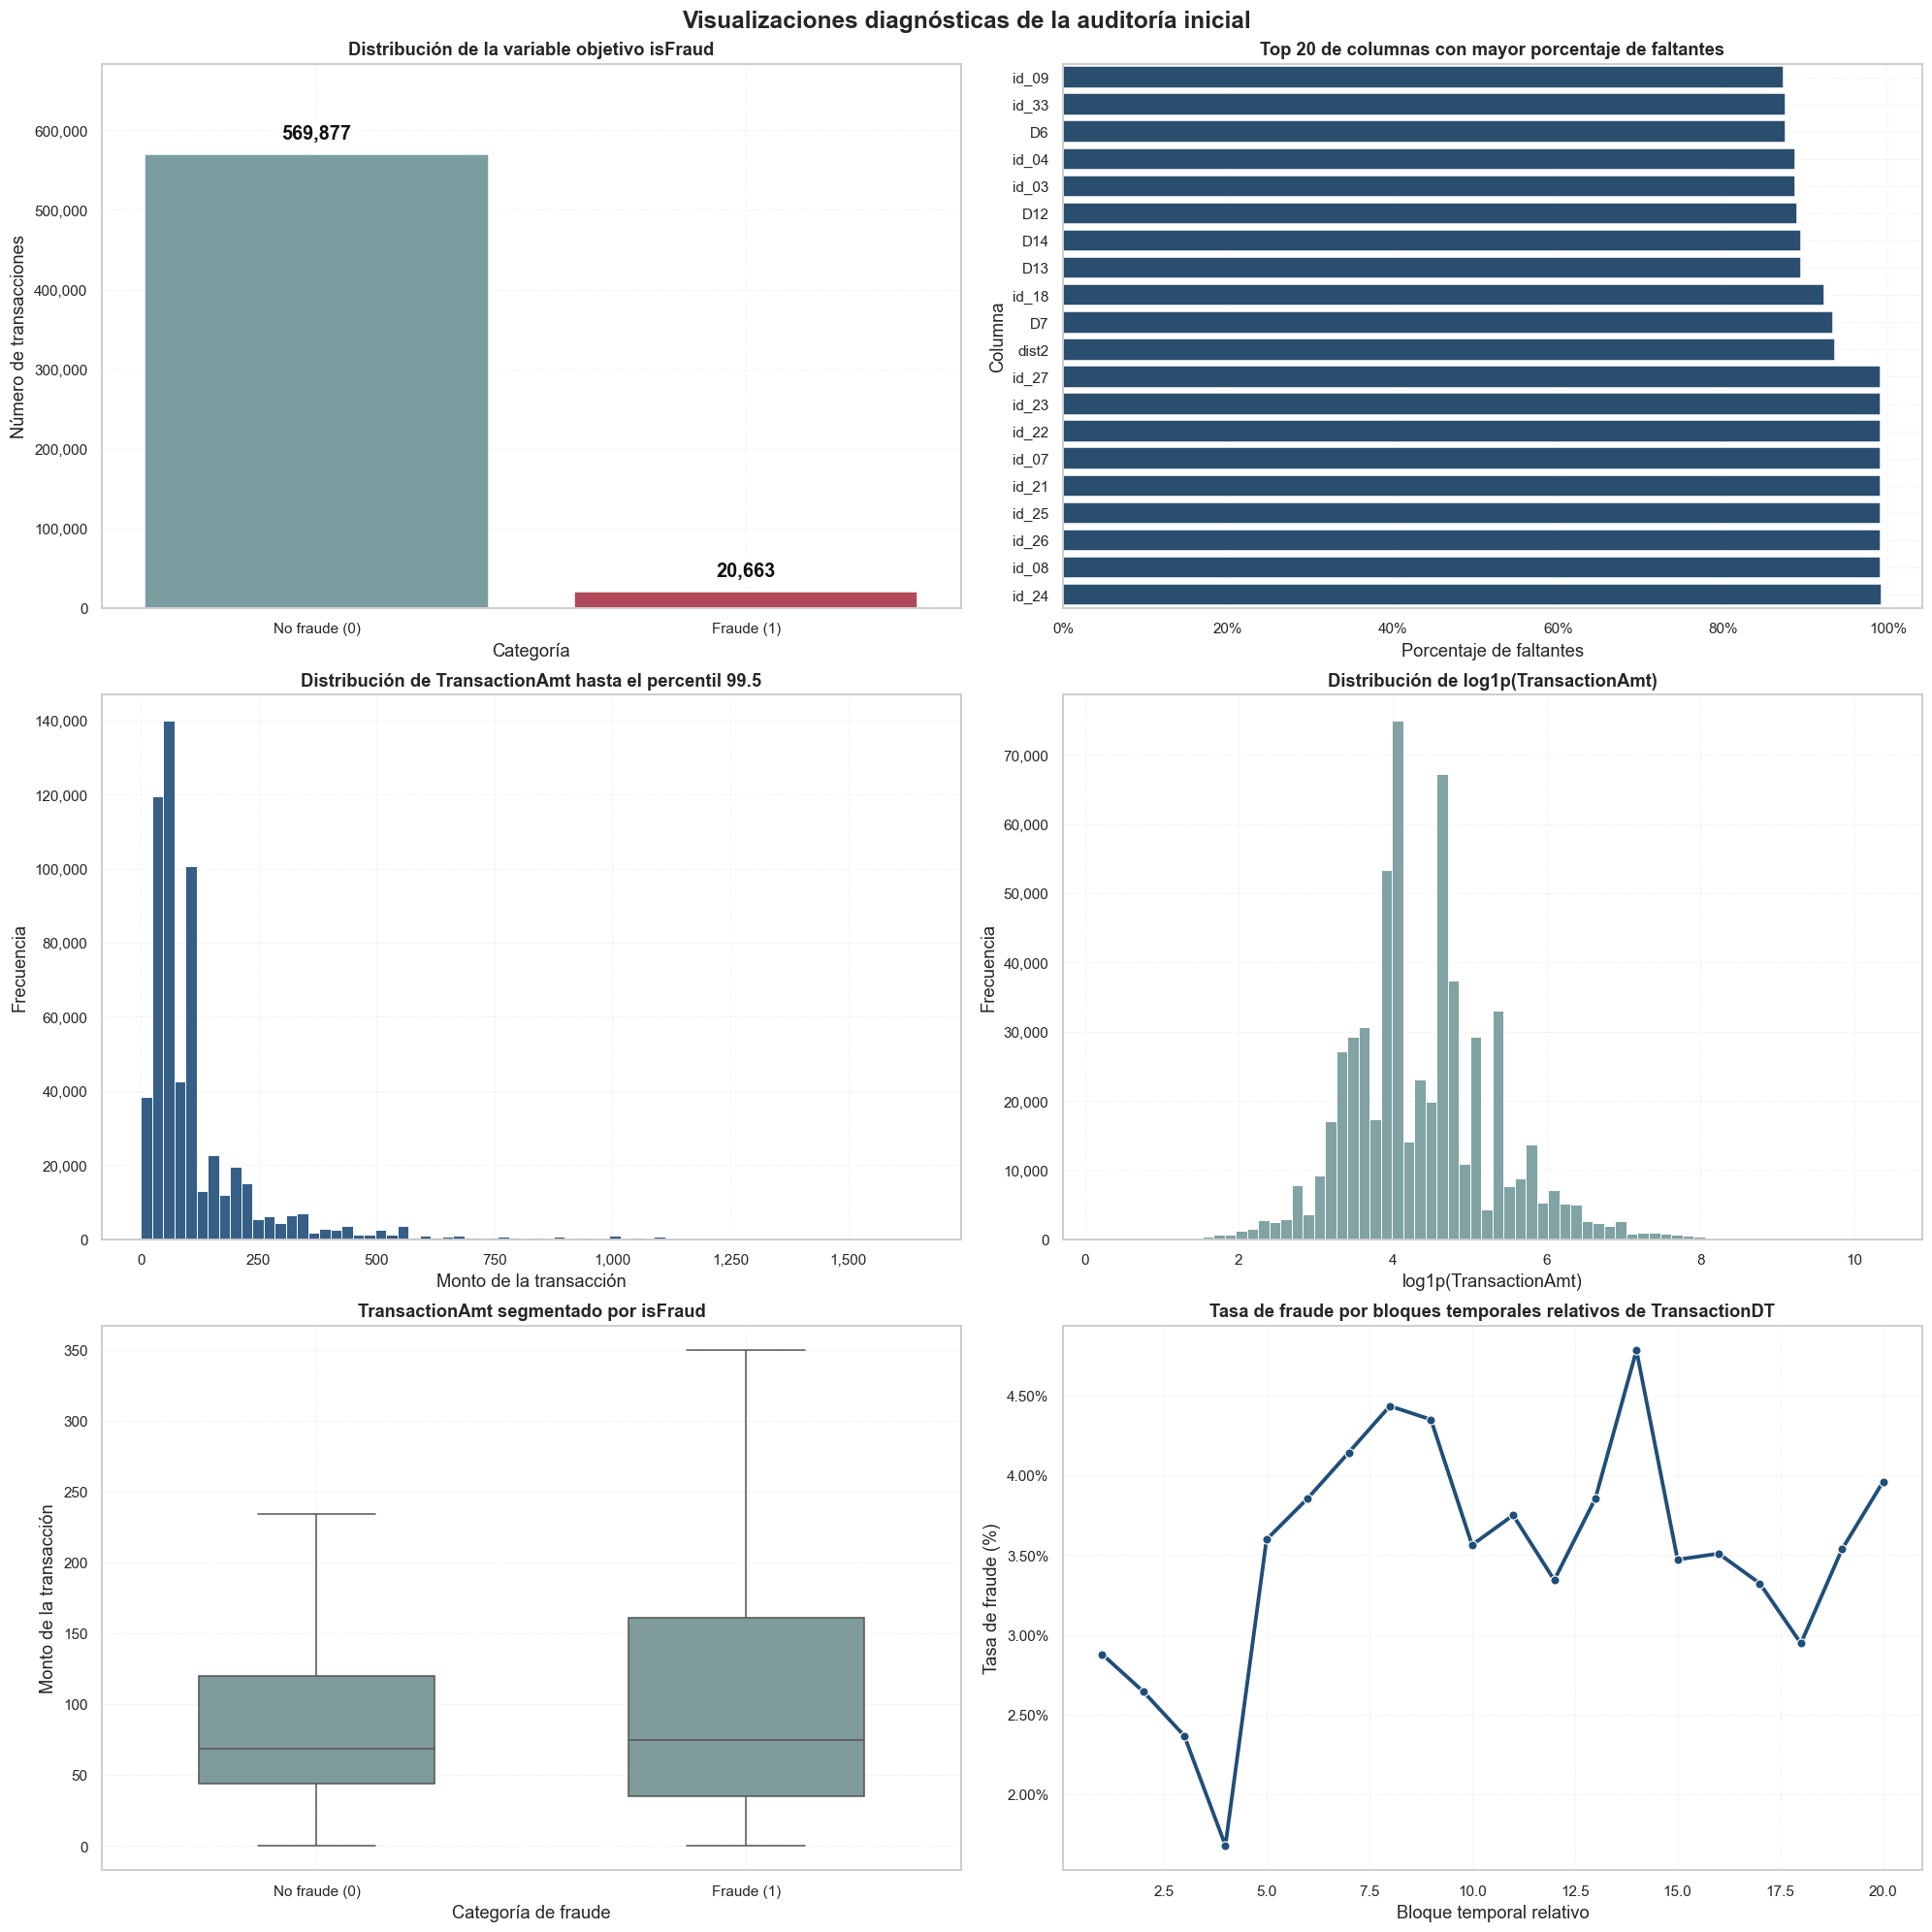

In [6]:
# Importación del formateador de ejes para mejorar la legibilidad numérica de los gráficos.
from matplotlib.ticker import FuncFormatter

# Preparación de tablas auxiliares pequeñas para las visualizaciones diagnósticas.
missing_plot_data = top_missing_columns.copy().sort_values("porcentaje_faltantes", ascending=True)
fraud_plot_data = target_distribution[["categoría", "conteo"]].copy()
amount_plot_data = df_audit[["TransactionAmt", "isFraud"]].copy()
amount_plot_data["clase_fraude"] = amount_plot_data["isFraud"].map({0: "No fraude (0)", 1: "Fraude (1)"})
transaction_amt_series = amount_plot_data["TransactionAmt"].dropna().copy()
transaction_amt_clip_limit = transaction_amt_series.quantile(0.995)
transaction_amt_clipped = transaction_amt_series[transaction_amt_series <= transaction_amt_clip_limit].copy()
transaction_amt_log = np.log1p(transaction_amt_series)

# Construcción de un subconjunto temporal para evitar operaciones innecesarias sobre el DataFrame completo.
temporal_audit = df_audit[["TransactionDT", "isFraud"]].copy()

# Construcción de bloques temporales relativos para observar si la tasa de fraude cambia dentro del orden disponible.
time_block_count = min(20, int(temporal_audit["TransactionDT"].nunique()))
temporal_audit["TransactionDT_block"] = pd.qcut(
    temporal_audit["TransactionDT"],
    q=time_block_count,
    duplicates="drop",
)
fraud_rate_by_time = (
    temporal_audit
    .groupby("TransactionDT_block", observed=False)["isFraud"]
    .mean()
    .mul(100)
    .reset_index(name="tasa_fraude_pct")
)
fraud_rate_by_time["bloque_temporal"] = np.arange(1, len(fraud_rate_by_time) + 1)

# Configuración del lienzo general para mantener una presentación uniforme y profesional.
fig, axes = plt.subplots(3, 2, figsize=(18, 18), constrained_layout=True)
axes = axes.flatten()
color_main = "#1f4e79"
color_aux = "#7a9e9f"
color_alert = "#b04a5a"
label_bbox = dict(boxstyle="round,pad=0.28", facecolor="white", edgecolor="none", alpha=0.90)

# Gráfico de barras para visualizar el desbalance inicial de la variable objetivo.
bar_ax = sns.barplot(
    data=fraud_plot_data,
    x="categoría",
    y="conteo",
    color=color_main,
    ax=axes[0],
)
for patch, bar_color in zip(bar_ax.patches, [color_aux, color_alert]):
    patch.set_facecolor(bar_color)
axes[0].set_ylim(0, fraud_plot_data["conteo"].max() * 1.20)
axes[0].bar_label(
    bar_ax.containers[0],
    labels=[f"{value:,}" for value in fraud_plot_data["conteo"]],
    padding=8,
    fontsize=13,
    fontweight="bold",
    color="#111111",
    bbox=label_bbox,
)
axes[0].set_title("Distribución de la variable objetivo isFraud", fontweight="semibold")
axes[0].set_xlabel("Categoría")
axes[0].set_ylabel("Número de transacciones")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{int(value):,}"))

# Gráfico horizontal para destacar las columnas con mayor porcentaje de valores faltantes.
sns.barplot(
    data=missing_plot_data,
    x="porcentaje_faltantes",
    y="columna",
    color=color_main,
    ax=axes[1],
)
axes[1].set_title("Top 20 de columnas con mayor porcentaje de faltantes", fontweight="semibold")
axes[1].set_xlabel("Porcentaje de faltantes")
axes[1].set_ylabel("Columna")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0f}%"))

# Histograma recortado para observar con mayor detalle la masa principal de TransactionAmt.
sns.histplot(
    transaction_amt_clipped,
    bins=70,
    color=color_main,
    alpha=0.90,
    edgecolor="white",
    ax=axes[2],
)
axes[2].set_title("Distribución de TransactionAmt hasta el percentil 99.5", fontweight="semibold")
axes[2].set_xlabel("Monto de la transacción")
axes[2].set_ylabel("Frecuencia")
axes[2].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{int(value):,}"))

# Histograma en escala logarítmica para describir con mayor claridad la cola larga de TransactionAmt.
sns.histplot(
    transaction_amt_log,
    bins=70,
    color=color_aux,
    alpha=0.95,
    edgecolor="white",
    ax=axes[3],
)
axes[3].set_title("Distribución de log1p(TransactionAmt)", fontweight="semibold")
axes[3].set_xlabel("log1p(TransactionAmt)")
axes[3].set_ylabel("Frecuencia")
axes[3].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{int(value):,}"))

# Boxplot segmentado por fraude para comparar de forma robusta la dispersión de los montos.
sns.boxplot(
    data=amount_plot_data.dropna(subset=["TransactionAmt"]),
    x="clase_fraude",
    y="TransactionAmt",
    showfliers=False,
    color=color_aux,
    width=0.55,
    ax=axes[4],
)
axes[4].set_title("TransactionAmt segmentado por isFraud", fontweight="semibold")
axes[4].set_xlabel("Categoría de fraude")
axes[4].set_ylabel("Monto de la transacción")
axes[4].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))

# Gráfico temporal relativo para observar la variación preliminar de la tasa de fraude en bloques ordenados.
sns.lineplot(
    data=fraud_rate_by_time,
    x="bloque_temporal",
    y="tasa_fraude_pct",
    marker="o",
    color=color_main,
    linewidth=2.5,
    ax=axes[5],
)
axes[5].set_title("Tasa de fraude por bloques temporales relativos de TransactionDT", fontweight="semibold")
axes[5].set_xlabel("Bloque temporal relativo")
axes[5].set_ylabel("Tasa de fraude (%)")
axes[5].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}%"))

# Ajustes comunes de estilo para reforzar una presentación sobria y legible.
for axis in axes:
    axis.grid(alpha=0.25, linestyle="--", linewidth=0.6)
    axis.tick_params(labelsize=10)

# Título general del bloque gráfico para reforzar su cohesión visual.
fig.suptitle("Visualizaciones diagnósticas de la auditoría inicial", fontsize=16, fontweight="semibold")
plt.show()


### 8.1 Interpretación inicial de la auditoría diagnóstica

Para describir `TransactionAmt` con mayor fidelidad visual, se presentan dos vistas complementarias: un histograma recortado hasta el percentil 99.5, que concentra la atención en la masa principal de la distribución, y un histograma de `log1p(TransactionAmt)`, que comprime la cola larga sin alterar el orden relativo de los montos. Esta combinación facilita una lectura más estable de una variable fuertemente asimétrica.

La distribución de `isFraud` permite observar de manera preliminar un desbalance de clases, situación esperable en problemas reales de fraude. Este rasgo es metodológicamente importante porque muestra que una lectura basada solo en frecuencias absolutas o en exactitud global sería insuficiente para describir el problema.

La presencia de valores faltantes en numerosas columnas sugiere que la completitud de la información es heterogénea y que existen variables con cobertura limitada. Esta observación indica que el dataset contiene fuentes de información con distintos niveles de disponibilidad y que la interpretación de varias columnas requiere cautela.

El comportamiento preliminar de `TransactionAmt` ofrece una primera señal sobre la dispersión de los montos y sobre posibles diferencias entre transacciones fraudulentas y no fraudulentas. La distribución observada sugiere asimetría y la coexistencia de montos muy concentrados con valores extremos.

El patrón temporal relativo derivado de `TransactionDT` sugiere que la tasa de fraude no necesariamente permanece estable a lo largo del orden temporal del dataset. Dado que `TransactionDT` representa un desplazamiento relativo y no fechas de calendario reales, la lectura debe mantenerse prudente y centrada en cambios de comportamiento dentro del orden observado.

En conjunto, estos hallazgos importan metodológicamente porque delimitan riesgos, orientan prioridades analíticas y refuerzan la necesidad de una lectura reproducible y técnicamente controlada del dataset.


### 8.2 Hallazgos preliminares de la auditoría inicial

Las observaciones iniciales muestran que la tabla de transacciones constituye una base adecuada para el análisis porque concentra la variable objetivo y preserva el universo de estudio. La unión mediante `TransactionID` permite incorporar información de identidad sin perder trazabilidad, y al mismo tiempo deja visible que no todas las transacciones cuentan con datos complementarios.

Desde una perspectiva estructural, el dataset unido presenta alta dimensionalidad, coexistencia de variables numéricas y categóricas, y una carga importante de valores faltantes. Estos rasgos introducen riesgos metodológicos tempranos, entre ellos sesgos por cobertura desigual, decisiones sensibles sobre manejo de ausencias y posibles diferencias entre subpoblaciones con y sin información de identidad.

Estas evidencias muestran que la lectura del dataset exige especial cuidado en la interpretación de faltantes, cobertura de identidad y comportamiento temporal relativo. La auditoría inicial, por tanto, cumple una función de delimitación técnica y no de cierre analítico.


### 8.3 Limitaciones de la auditoría inicial

Esta auditoría es estrictamente diagnóstica y no constituye por sí misma un pipeline de preparación definitivo. Aunque permite caracterizar la estructura general del dataset y algunos patrones descriptivos, no resuelve de manera integral las decisiones técnicas asociadas con tratamiento de variables, validación o evaluación predictiva.

En este notebook no se incorporan procedimientos de imputación, transformaciones de codificación, selección de variables ni evaluación de modelos. Por ello, los resultados documentados aquí deben interpretarse como una caracterización inicial del comportamiento estructural del dataset.

En consecuencia, el alcance de esta revisión se limita a la descripción diagnóstica del conjunto de datos y no a la formulación de conclusiones sustantivas sobre el desempeño de un sistema de detección de fraude.


## 9. Análisis exploratorio profundo del dataset unido

El propósito de este análisis exploratorio profundo es identificar patrones diferenciadores entre fraude y no fraude sobre el dataframe unido `df_audit`, examinar variables numéricas y categóricas con capacidad interpretativa, y caracterizar el comportamiento temporal del fenómeno desde una perspectiva descriptiva y comparativa.

La lectura se concentra en señales observables, diferencias de riesgo entre segmentos y límites de cobertura de variables seleccionadas, manteniendo un enfoque estrictamente diagnóstico.


### 9.1 Exploración numérica comparativa: montos y distancias

Se examinan variables numéricas con capacidad descriptiva directa, priorizando `TransactionAmt`, `dist1`, `dist2` y un conjunto reducido de variables adicionales que permiten contextualizar magnitud, dispersión y contraste entre fraude y no fraude.


In [7]:
# Función auxiliar para convertir intervalos numéricos en etiquetas legibles para gráficos y tablas.
def format_interval_label(interval, decimals: int = 1) -> str:
    """Convierte un intervalo de pandas en una etiqueta legible con formato numérico."""
    return f"{interval.left:,.{decimals}f} a {interval.right:,.{decimals}f}"


# Función auxiliar para resumir tasa de fraude por cuantiles sobre una variable numérica.
def build_rate_by_quantile(series: pd.Series, target: pd.Series, q: int = 8, decimals: int = 1) -> pd.DataFrame:
    """Genera bins por cuantiles y resume frecuencia y tasa de fraude por intervalo."""

    valid_data = pd.DataFrame({"valor": series, "isFraud": target}).dropna().copy()
    quantile_count = max(2, min(q, int(valid_data["valor"].nunique())))
    valid_data["bin"] = pd.qcut(valid_data["valor"], q=quantile_count, duplicates="drop")

    summary = (
        valid_data
        .groupby("bin", observed=False)["isFraud"]
        .agg(transacciones="size", tasa_fraude="mean")
        .reset_index()
    )
    summary["tasa_fraude_pct"] = summary["tasa_fraude"] * 100
    summary["intervalo"] = summary["bin"].apply(lambda interval: format_interval_label(interval, decimals=decimals))
    return summary


# Función auxiliar para resumir variables categóricas con sus categorías más frecuentes.
def build_top_category_summary(dataframe: pd.DataFrame, column: str, top_n: int = 8) -> pd.DataFrame:
    """Resume frecuencia y tasa de fraude de las categorías más frecuentes de una variable."""

    category_data = dataframe[[column, "isFraud"]].copy()
    category_data[column] = category_data[column].fillna("FALTANTE")

    summary = (
        category_data
        .groupby(column, observed=False)["isFraud"]
        .agg(transacciones="size", tasa_fraude="mean")
        .reset_index()
        .rename(columns={column: "categoría"})
    )
    summary["tasa_fraude_pct"] = summary["tasa_fraude"] * 100
    top_categories = summary.sort_values("transacciones", ascending=False).head(top_n)["categoría"].tolist()
    plot_data = summary[summary["categoría"].isin(top_categories)].copy()
    plot_data["categoría"] = pd.Categorical(plot_data["categoría"], categories=top_categories, ordered=True)
    return plot_data.sort_values("categoría")


Resumen comparativo de variables numéricas seleccionadas


variable,cobertura_pct,mediana_no_fraude,mediana_fraude,media_no_fraude,media_fraude
TransactionAmt,100.00%,68.50,75.00,134.51,149.24
dist1,40.35%,8.00,10.00,117.36,174.59
dist2,6.37%,36.00,49.00,235.20,201.47
C1,100.00%,1.00,2.00,13.31,35.54
D1,99.79%,4.00,0.00,96.36,38.71


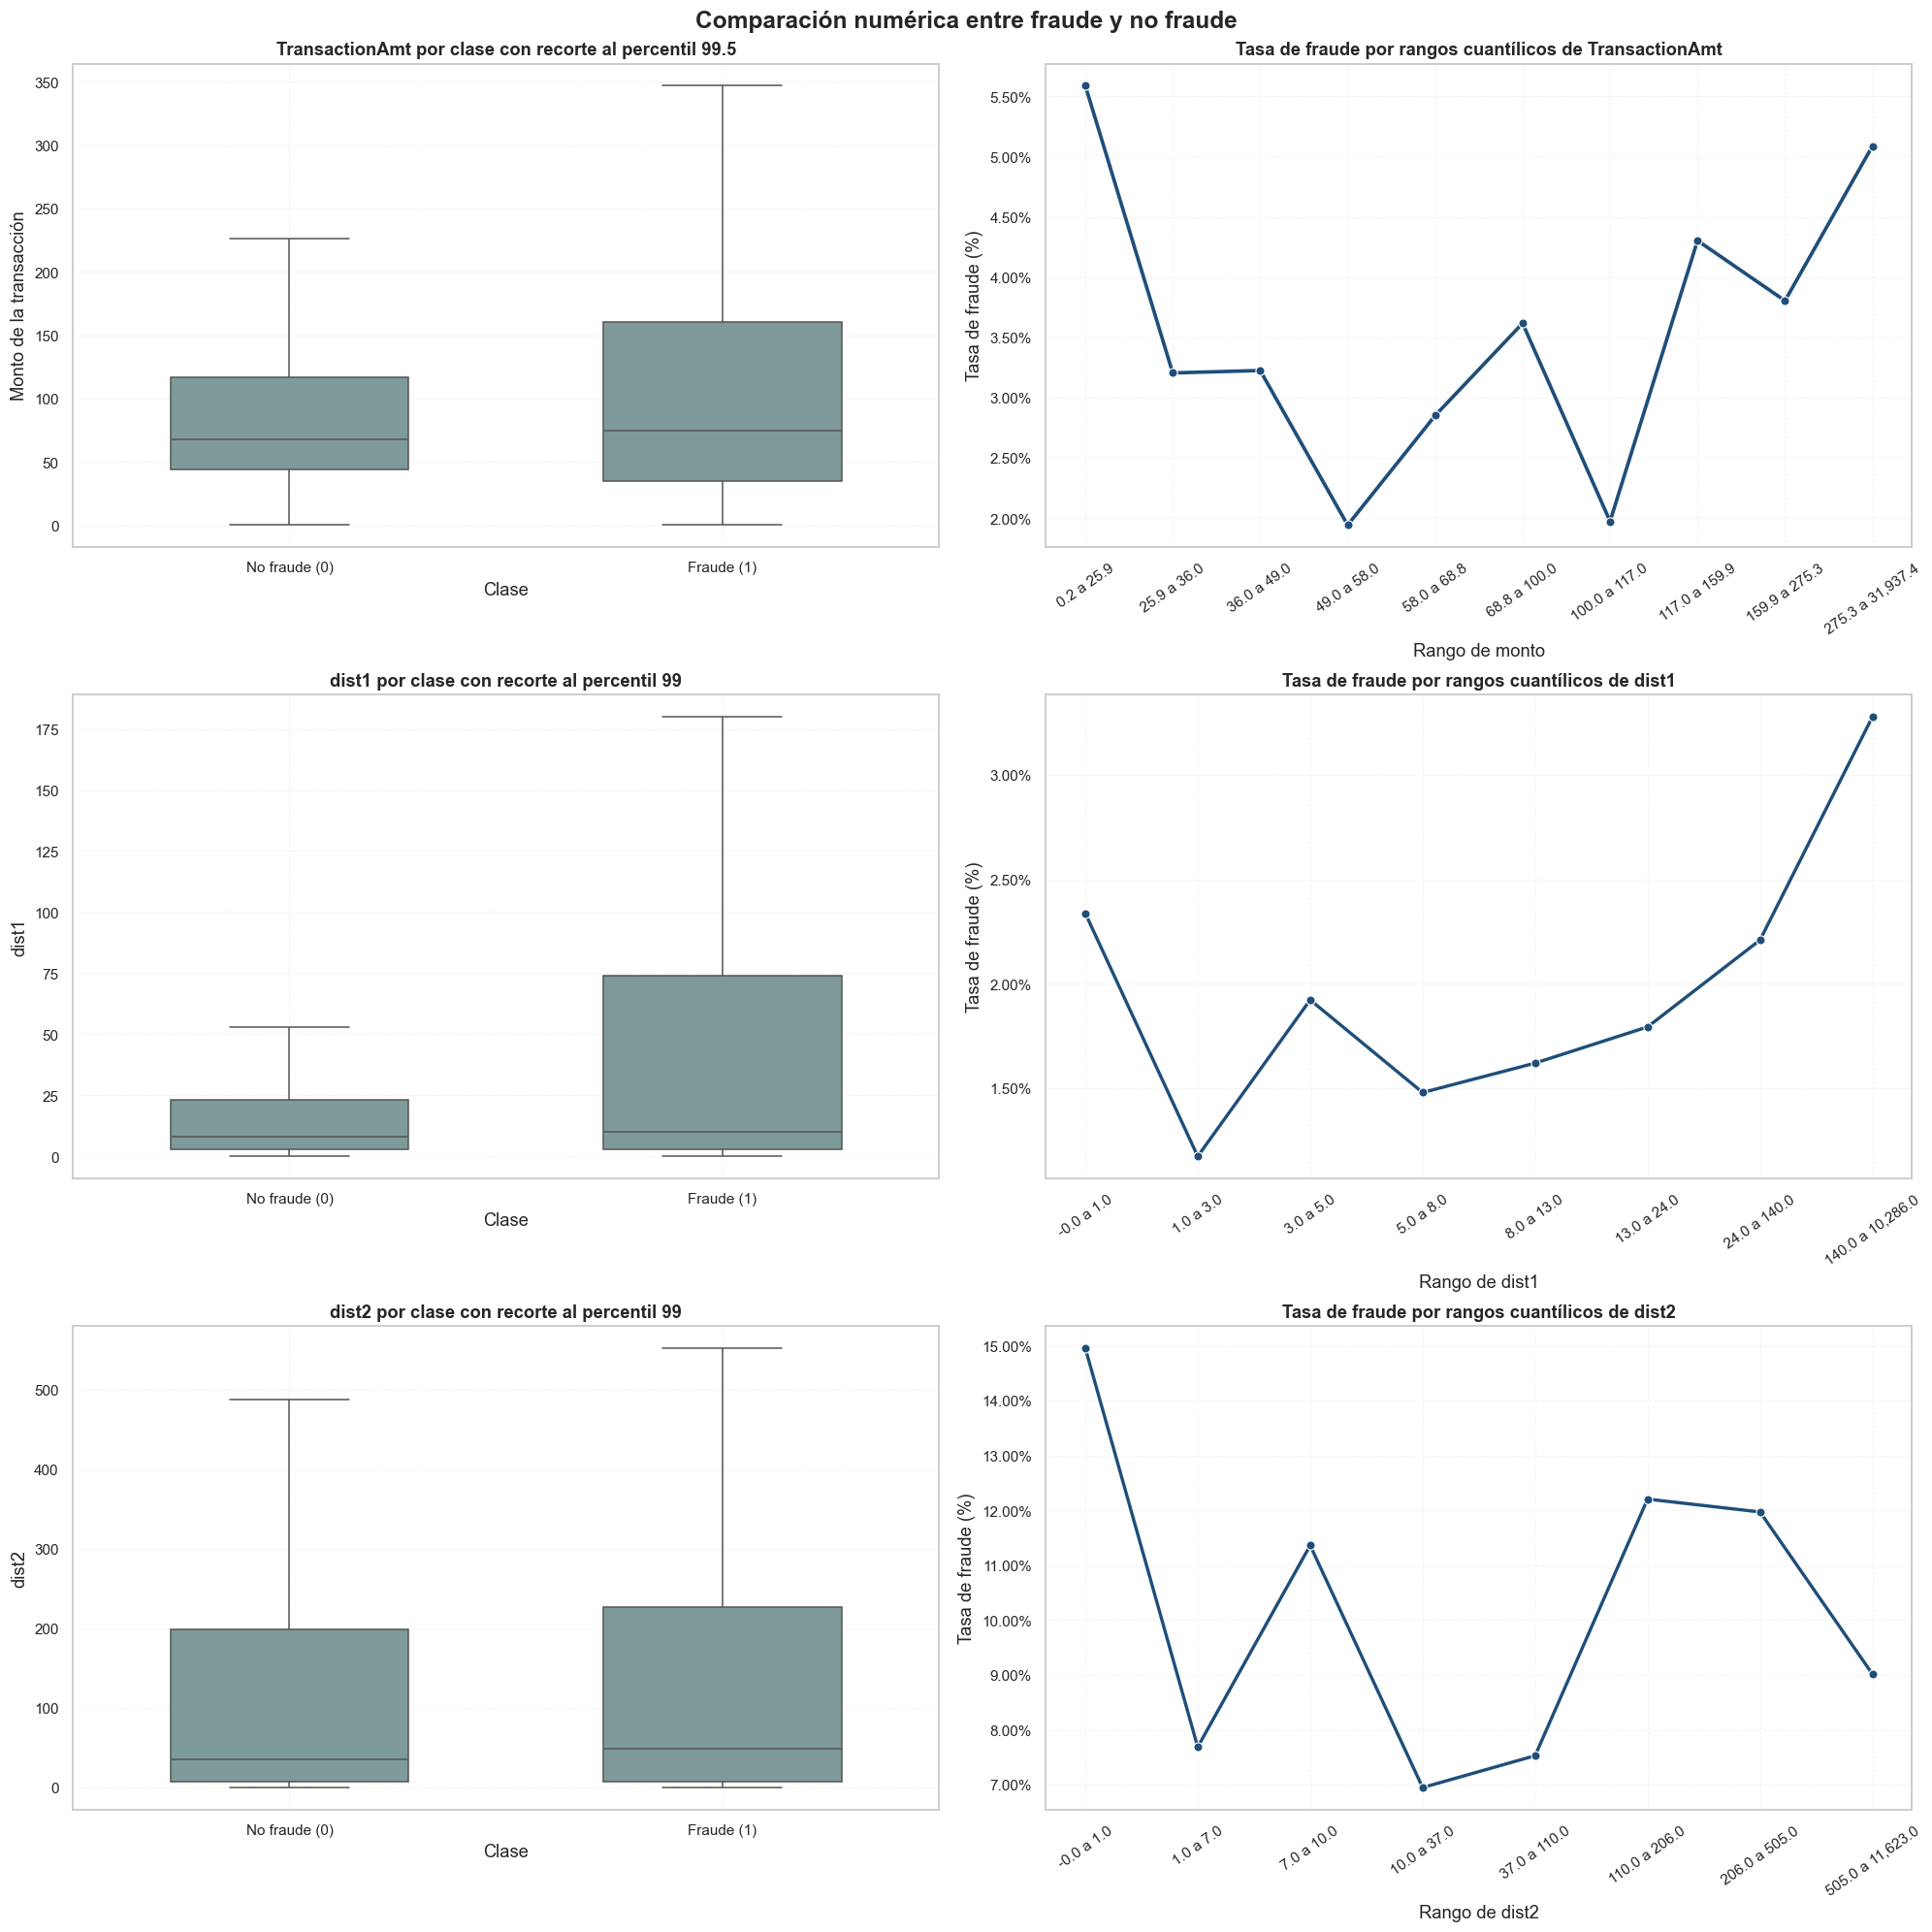

In [8]:
# Selección de variables numéricas interpretables; se evita saturar el análisis con columnas de difícil lectura.
numeric_profile_vars = [column for column in ["TransactionAmt", "dist1", "dist2", "C1", "D1"] if column in df_audit.columns]

# Tabla comparativa por clase: resume si las variables numéricas muestran señales descriptivas entre fraude y no fraude.
numeric_profile_rows = []
for column in numeric_profile_vars:
    fraud_zero = df_audit.loc[df_audit["isFraud"] == 0, column].dropna()
    fraud_one = df_audit.loc[df_audit["isFraud"] == 1, column].dropna()
    numeric_profile_rows.append(
        {
            "variable": column,
            "cobertura_pct": df_audit[column].notna().mean() * 100,
            "mediana_no_fraude": fraud_zero.median() if not fraud_zero.empty else np.nan,
            "mediana_fraude": fraud_one.median() if not fraud_one.empty else np.nan,
            "media_no_fraude": fraud_zero.mean() if not fraud_zero.empty else np.nan,
            "media_fraude": fraud_one.mean() if not fraud_one.empty else np.nan,
        }
    )

numeric_profile_summary = pd.DataFrame(numeric_profile_rows)
numeric_profile_display = numeric_profile_summary.copy()
numeric_profile_display["cobertura_pct"] = numeric_profile_display["cobertura_pct"].map(format_percentage)
for column in ["mediana_no_fraude", "mediana_fraude", "media_no_fraude", "media_fraude"]:
    numeric_profile_display[column] = numeric_profile_display[column].map(format_decimal)

print("Resumen comparativo de variables numéricas seleccionadas")
display(numeric_profile_display.style.hide(axis="index"))

# Preparación de subconjuntos reducidos para evitar operaciones innecesarias sobre el DataFrame completo.
transaction_amt_compare = df_audit[["TransactionAmt", "isFraud"]].dropna().copy()
transaction_amt_compare["clase_fraude"] = transaction_amt_compare["isFraud"].map({0: "No fraude (0)", 1: "Fraude (1)"})
transaction_amt_clip = transaction_amt_compare["TransactionAmt"].quantile(0.995)
transaction_amt_compare = transaction_amt_compare[transaction_amt_compare["TransactionAmt"] <= transaction_amt_clip].copy()

dist1_compare = df_audit[["dist1", "isFraud"]].dropna().copy() if "dist1" in df_audit.columns else pd.DataFrame()
dist2_compare = df_audit[["dist2", "isFraud"]].dropna().copy() if "dist2" in df_audit.columns else pd.DataFrame()
if not dist1_compare.empty:
    dist1_compare["clase_fraude"] = dist1_compare["isFraud"].map({0: "No fraude (0)", 1: "Fraude (1)"})
    dist1_clip = dist1_compare["dist1"].quantile(0.99)
    dist1_compare = dist1_compare[dist1_compare["dist1"] <= dist1_clip].copy()
if not dist2_compare.empty:
    dist2_compare["clase_fraude"] = dist2_compare["isFraud"].map({0: "No fraude (0)", 1: "Fraude (1)"})
    dist2_clip = dist2_compare["dist2"].quantile(0.99)
    dist2_compare = dist2_compare[dist2_compare["dist2"] <= dist2_clip].copy()

# Construcción de tablas de tasa de fraude por rangos cuantílicos para las variables de distancia y monto.
transaction_amt_rate = build_rate_by_quantile(df_audit["TransactionAmt"], df_audit["isFraud"], q=10, decimals=1)
dist1_rate = build_rate_by_quantile(df_audit["dist1"], df_audit["isFraud"], q=8, decimals=1) if "dist1" in df_audit.columns else pd.DataFrame()
dist2_rate = build_rate_by_quantile(df_audit["dist2"], df_audit["isFraud"], q=8, decimals=1) if "dist2" in df_audit.columns else pd.DataFrame()

# Configuración visual del bloque numérico con seis paneles compactos y legibles.
fig, axes = plt.subplots(3, 2, figsize=(18, 18), constrained_layout=True)
axes = axes.flatten()
color_main = "#1f4e79"
color_aux = "#7a9e9f"
color_alert = "#b04a5a"

# Comparación robusta de montos entre fraude y no fraude después de recortar valores extremadamente altos.
sns.boxplot(
    data=transaction_amt_compare,
    x="clase_fraude",
    y="TransactionAmt",
    showfliers=False,
    color=color_aux,
    width=0.55,
    ax=axes[0],
)
axes[0].set_title("TransactionAmt por clase con recorte al percentil 99.5", fontweight="semibold")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Monto de la transacción")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))

# Tasa de fraude por rangos de monto para identificar segmentos con mayor riesgo relativo.
sns.lineplot(
    data=transaction_amt_rate,
    x="intervalo",
    y="tasa_fraude_pct",
    marker="o",
    color=color_main,
    linewidth=2.4,
    ax=axes[1],
)
axes[1].set_title("Tasa de fraude por rangos cuantílicos de TransactionAmt", fontweight="semibold")
axes[1].set_xlabel("Rango de monto")
axes[1].set_ylabel("Tasa de fraude (%)")
axes[1].tick_params(axis="x", rotation=35)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}%"))

# Comparación de dist1 por clase siempre que la variable tenga datos suficientes para su lectura.
if not dist1_compare.empty:
    sns.boxplot(
        data=dist1_compare,
        x="clase_fraude",
        y="dist1",
        showfliers=False,
        color=color_aux,
        width=0.55,
        ax=axes[2],
    )
    axes[2].set_title("dist1 por clase con recorte al percentil 99", fontweight="semibold")
    axes[2].set_xlabel("Clase")
    axes[2].set_ylabel("dist1")
else:
    axes[2].text(0.5, 0.5, "dist1 no dispone de cobertura suficiente", ha="center", va="center")
    axes[2].set_axis_off()

# Tasa de fraude por rangos de dist1 para observar cambios relativos sobre registros con información disponible.
if not dist1_rate.empty:
    sns.lineplot(
        data=dist1_rate,
        x="intervalo",
        y="tasa_fraude_pct",
        marker="o",
        color=color_main,
        linewidth=2.2,
        ax=axes[3],
    )
    axes[3].set_title("Tasa de fraude por rangos cuantílicos de dist1", fontweight="semibold")
    axes[3].set_xlabel("Rango de dist1")
    axes[3].set_ylabel("Tasa de fraude (%)")
    axes[3].tick_params(axis="x", rotation=35)
    axes[3].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}%"))
else:
    axes[3].text(0.5, 0.5, "dist1 no permite construir bins interpretables", ha="center", va="center")
    axes[3].set_axis_off()

# Comparación de dist2 por clase, incorporando cautela visual por su cobertura más reducida.
if not dist2_compare.empty:
    sns.boxplot(
        data=dist2_compare,
        x="clase_fraude",
        y="dist2",
        showfliers=False,
        color=color_aux,
        width=0.55,
        ax=axes[4],
    )
    axes[4].set_title("dist2 por clase con recorte al percentil 99", fontweight="semibold")
    axes[4].set_xlabel("Clase")
    axes[4].set_ylabel("dist2")
else:
    axes[4].text(0.5, 0.5, "dist2 no dispone de cobertura suficiente", ha="center", va="center")
    axes[4].set_axis_off()

# Tasa de fraude por rangos de dist2 sobre observaciones no faltantes.
if not dist2_rate.empty:
    sns.lineplot(
        data=dist2_rate,
        x="intervalo",
        y="tasa_fraude_pct",
        marker="o",
        color=color_main,
        linewidth=2.2,
        ax=axes[5],
    )
    axes[5].set_title("Tasa de fraude por rangos cuantílicos de dist2", fontweight="semibold")
    axes[5].set_xlabel("Rango de dist2")
    axes[5].set_ylabel("Tasa de fraude (%)")
    axes[5].tick_params(axis="x", rotation=35)
    axes[5].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}%"))
else:
    axes[5].text(0.5, 0.5, "dist2 no permite construir bins interpretables", ha="center", va="center")
    axes[5].set_axis_off()

# Ajustes comunes de estilo para mantener una presentación sobria y consistente.
for axis in axes:
    axis.grid(alpha=0.25, linestyle="--", linewidth=0.6)
    axis.tick_params(labelsize=10)

fig.suptitle("Comparación numérica entre fraude y no fraude", fontsize=16, fontweight="semibold")
plt.show()


La comparación numérica muestra que `TransactionAmt` presenta diferencias moderadas entre clases en términos de media y mediana, pero la lectura por rangos revela un patrón más informativo: el riesgo relativo tiende a elevarse en los montos más bajos y también en el tramo superior de la distribución, lo que sugiere un comportamiento no lineal.

En `dist1` se observa una separación leve entre clases y una tasa de fraude algo más elevada en rangos altos sobre los registros disponibles. En `dist2`, la lectura debe ser más cauta porque su cobertura es reducida; aun así, la comparación aporta una señal diagnóstica útil sobre heterogeneidad espacial o de distancia en un subconjunto pequeño del dataset.

Entre las variables adicionales resumidas, `C1` y `D1` destacan por mostrar contrastes más nítidos en sus estadísticos centrales. La principal limitación de este bloque es que las diferencias visuales no implican causalidad ni estabilidad fuera del conjunto observado, y además varias variables numéricas presentan colas largas o faltantes sustanciales.


### 9.2 Exploración categórica comparativa: producto, pago y dispositivo

La exploración categórica se organiza en variables de producto y medios de pago, y en variables de correo, dispositivo e indicadores de consistencia. En cada caso se distingue entre frecuencia de aparición y tasa de fraude, porque una categoría muy frecuente no necesariamente implica mayor riesgo relativo.


Resumen de categorías principales: producto y medios de pago


variable,categoría,transacciones,tasa_fraude_pct
ProductCD,W,"439,670",2.04%
ProductCD,C,"68,519",11.69%
ProductCD,R,"37,699",3.78%
ProductCD,H,"33,024",4.77%
ProductCD,S,"11,628",5.90%
card4,visa,"384,767",3.48%
card4,mastercard,"189,217",3.43%
card4,american express,"8,328",2.87%
card4,discover,"6,651",7.73%
card4,FALTANTE,"1,577",2.60%


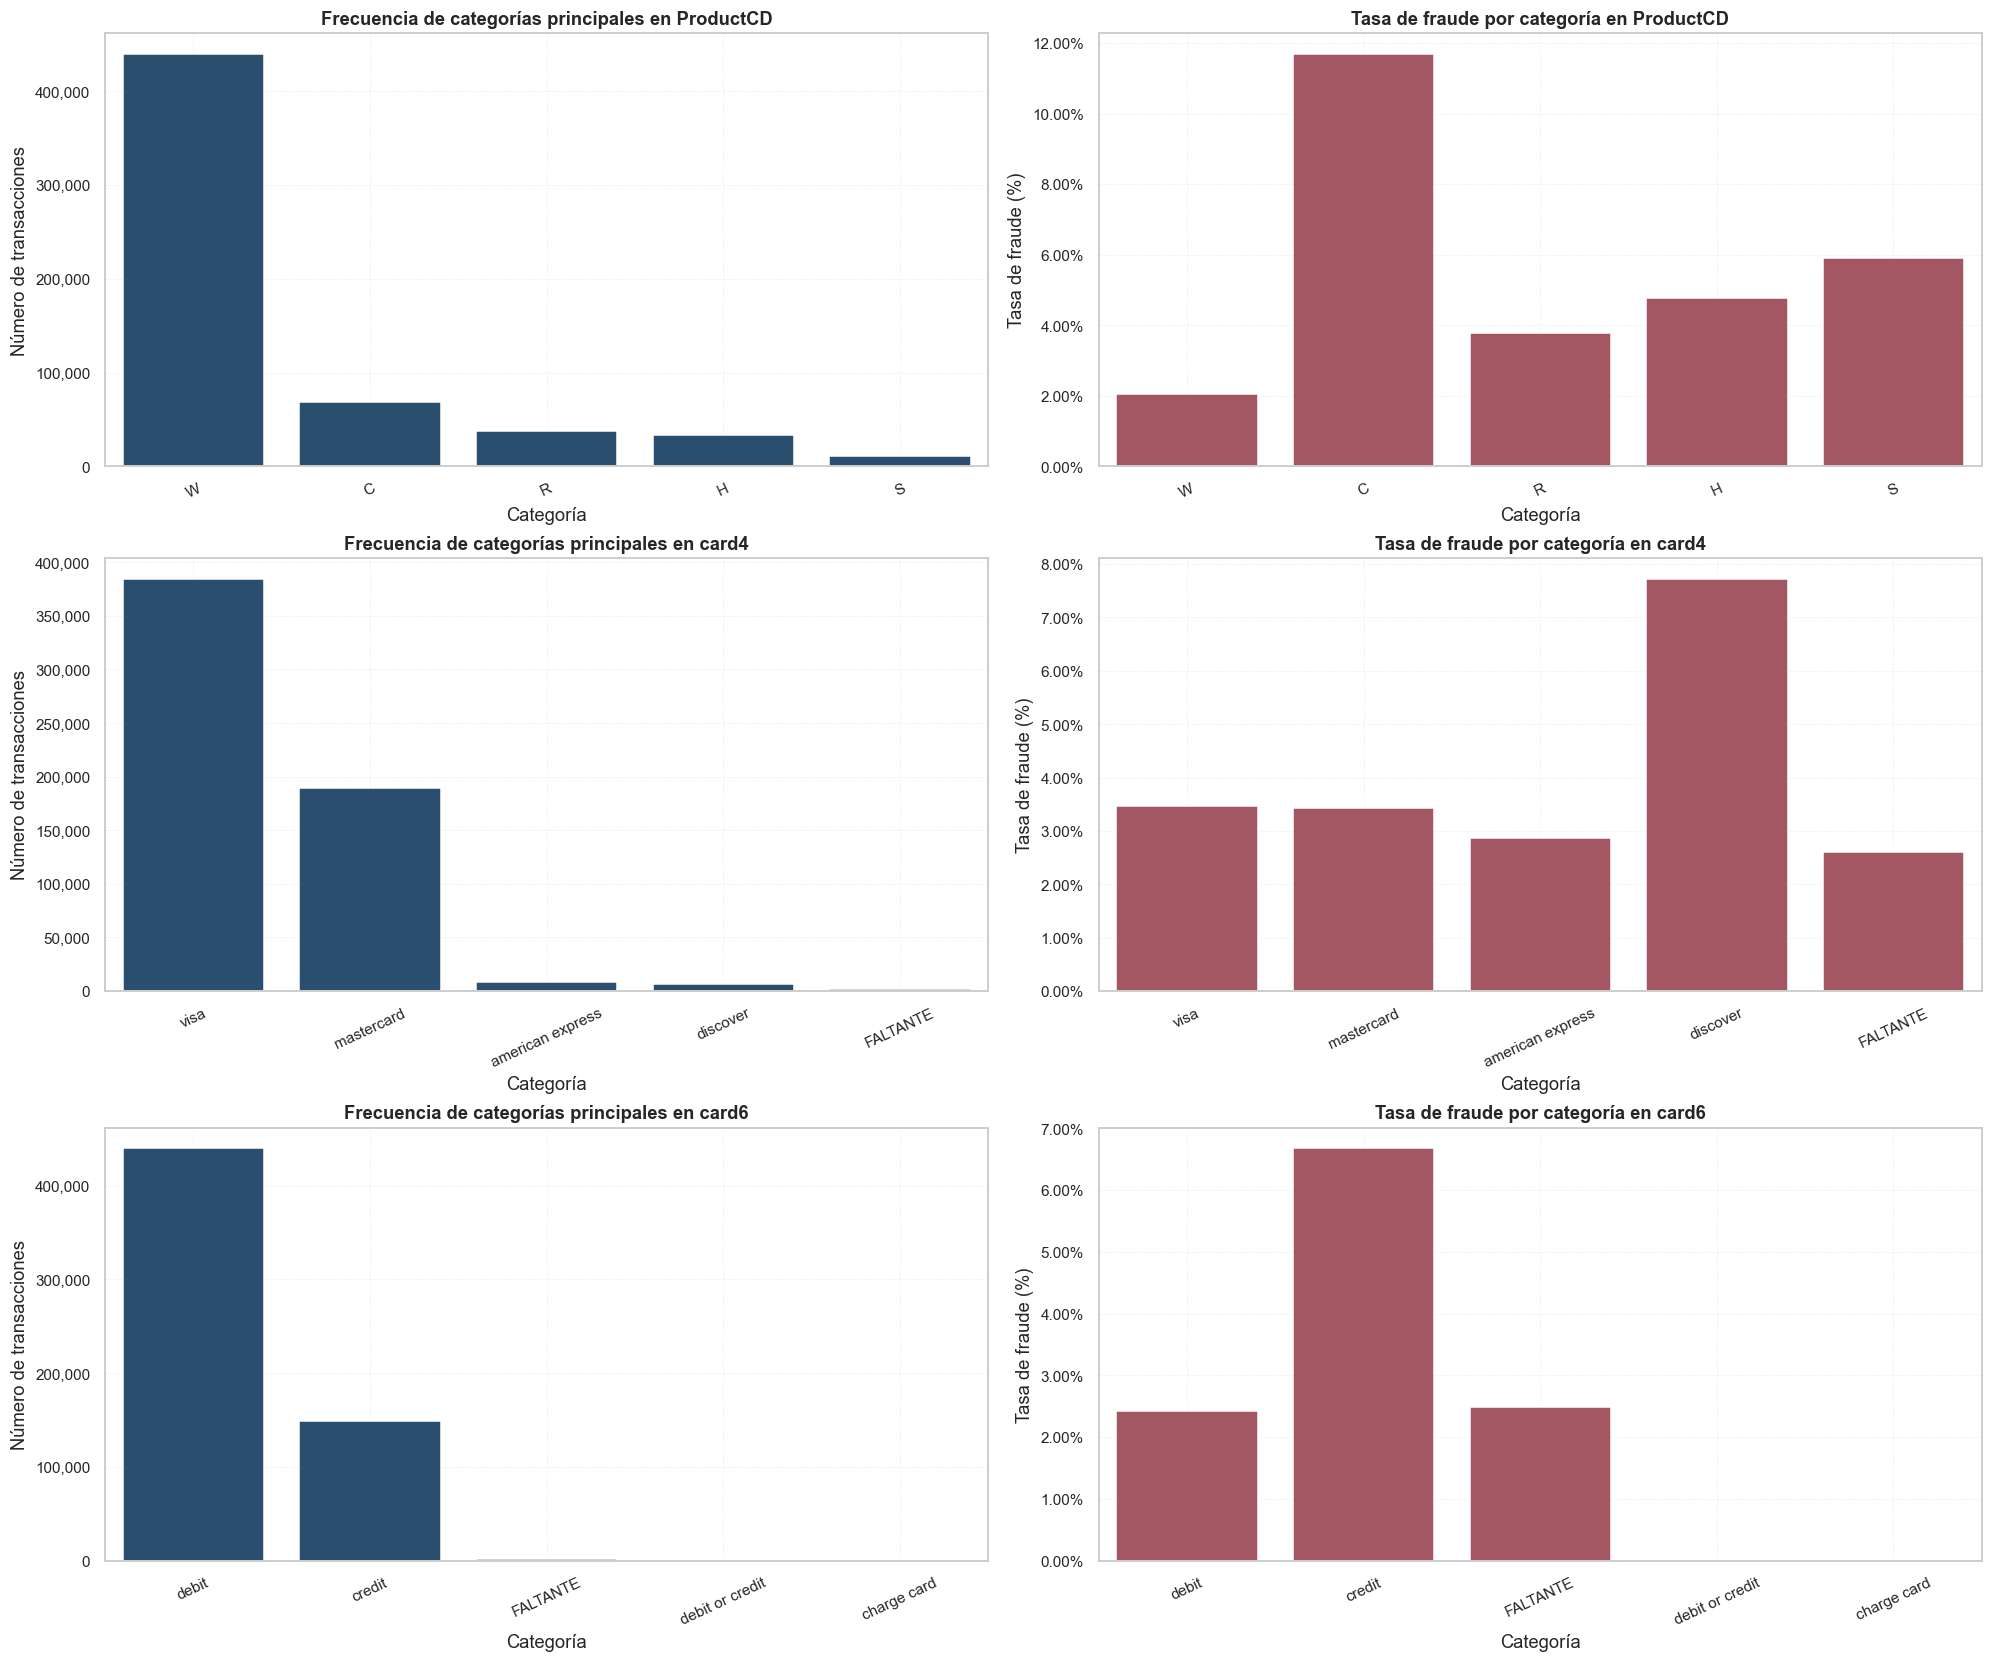

In [9]:
# Selección del primer bloque categórico: variables de producto y medio de pago con interpretación directa.
categorical_block_one = [column for column in ["ProductCD", "card4", "card6"] if column in df_audit.columns]
categorical_block_one_tables = []

# Para cada variable se contrasta volumen de transacciones y tasa de fraude, evitando confundir frecuencia con riesgo.
fig, axes = plt.subplots(len(categorical_block_one), 2, figsize=(18, 5 * len(categorical_block_one)), constrained_layout=True)
axes = np.atleast_2d(axes)

for row_index, column in enumerate(categorical_block_one):
    plot_data = build_top_category_summary(df_audit, column, top_n=8)
    table_data = plot_data.copy()
    table_data.insert(0, "variable", column)
    categorical_block_one_tables.append(table_data[["variable", "categoría", "transacciones", "tasa_fraude_pct"]])

    sns.barplot(
        data=plot_data,
        x="categoría",
        y="transacciones",
        color="#1f4e79",
        ax=axes[row_index, 0],
    )
    axes[row_index, 0].set_title(f"Frecuencia de categorías principales en {column}", fontweight="semibold")
    axes[row_index, 0].set_xlabel("Categoría")
    axes[row_index, 0].set_ylabel("Número de transacciones")
    axes[row_index, 0].tick_params(axis="x", rotation=25)
    axes[row_index, 0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{int(value):,}"))

    sns.barplot(
        data=plot_data,
        x="categoría",
        y="tasa_fraude_pct",
        color="#b04a5a",
        ax=axes[row_index, 1],
    )
    axes[row_index, 1].set_title(f"Tasa de fraude por categoría en {column}", fontweight="semibold")
    axes[row_index, 1].set_xlabel("Categoría")
    axes[row_index, 1].set_ylabel("Tasa de fraude (%)")
    axes[row_index, 1].tick_params(axis="x", rotation=25)
    axes[row_index, 1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}%"))

for axis in axes.flatten():
    axis.grid(alpha=0.25, linestyle="--", linewidth=0.6)
    axis.tick_params(labelsize=10)

categorical_block_one_summary = pd.concat(categorical_block_one_tables, ignore_index=True)
categorical_block_one_display = categorical_block_one_summary.copy()
categorical_block_one_display["transacciones"] = categorical_block_one_display["transacciones"].map(format_integer)
categorical_block_one_display["tasa_fraude_pct"] = categorical_block_one_display["tasa_fraude_pct"].map(format_percentage)

print("Resumen de categorías principales: producto y medios de pago")
display(categorical_block_one_display.style.hide(axis="index"))
plt.show()


En las variables de producto y medio de pago aparece una diferencia clara entre frecuencia y riesgo. `ProductCD` muestra que la categoría `W` domina el volumen de transacciones, pero `C` concentra una tasa de fraude muy superior. En `card4`, la categoría `discover` presenta un riesgo relativo más alto pese a representar una fracción pequeña del total. En `card6`, las tarjetas marcadas como `credit` exhiben una tasa de fraude mayor que las transacciones `debit`.

Estos patrones importan porque sugieren que el problema no se distribuye de manera uniforme entre segmentos comerciales y de pago. La limitación principal es que las categorías menos frecuentes pueden mostrar tasas elevadas con una base observacional reducida, por lo que el contraste debe leerse junto con el volumen asociado.


Resumen de categorías principales: correo, dispositivo e indicador M4


variable,categoría,transacciones,tasa_fraude_pct
P_emaildomain,gmail.com,"228,355",4.35%
P_emaildomain,yahoo.com,"100,934",2.28%
P_emaildomain,FALTANTE,"94,456",2.95%
P_emaildomain,hotmail.com,"45,250",5.30%
P_emaildomain,anonymous.com,"36,998",2.32%
P_emaildomain,aol.com,"28,289",2.18%
P_emaildomain,comcast.net,"7,888",3.12%
P_emaildomain,icloud.com,"6,267",3.14%
R_emaildomain,FALTANTE,"453,249",2.08%
R_emaildomain,gmail.com,"57,147",11.92%


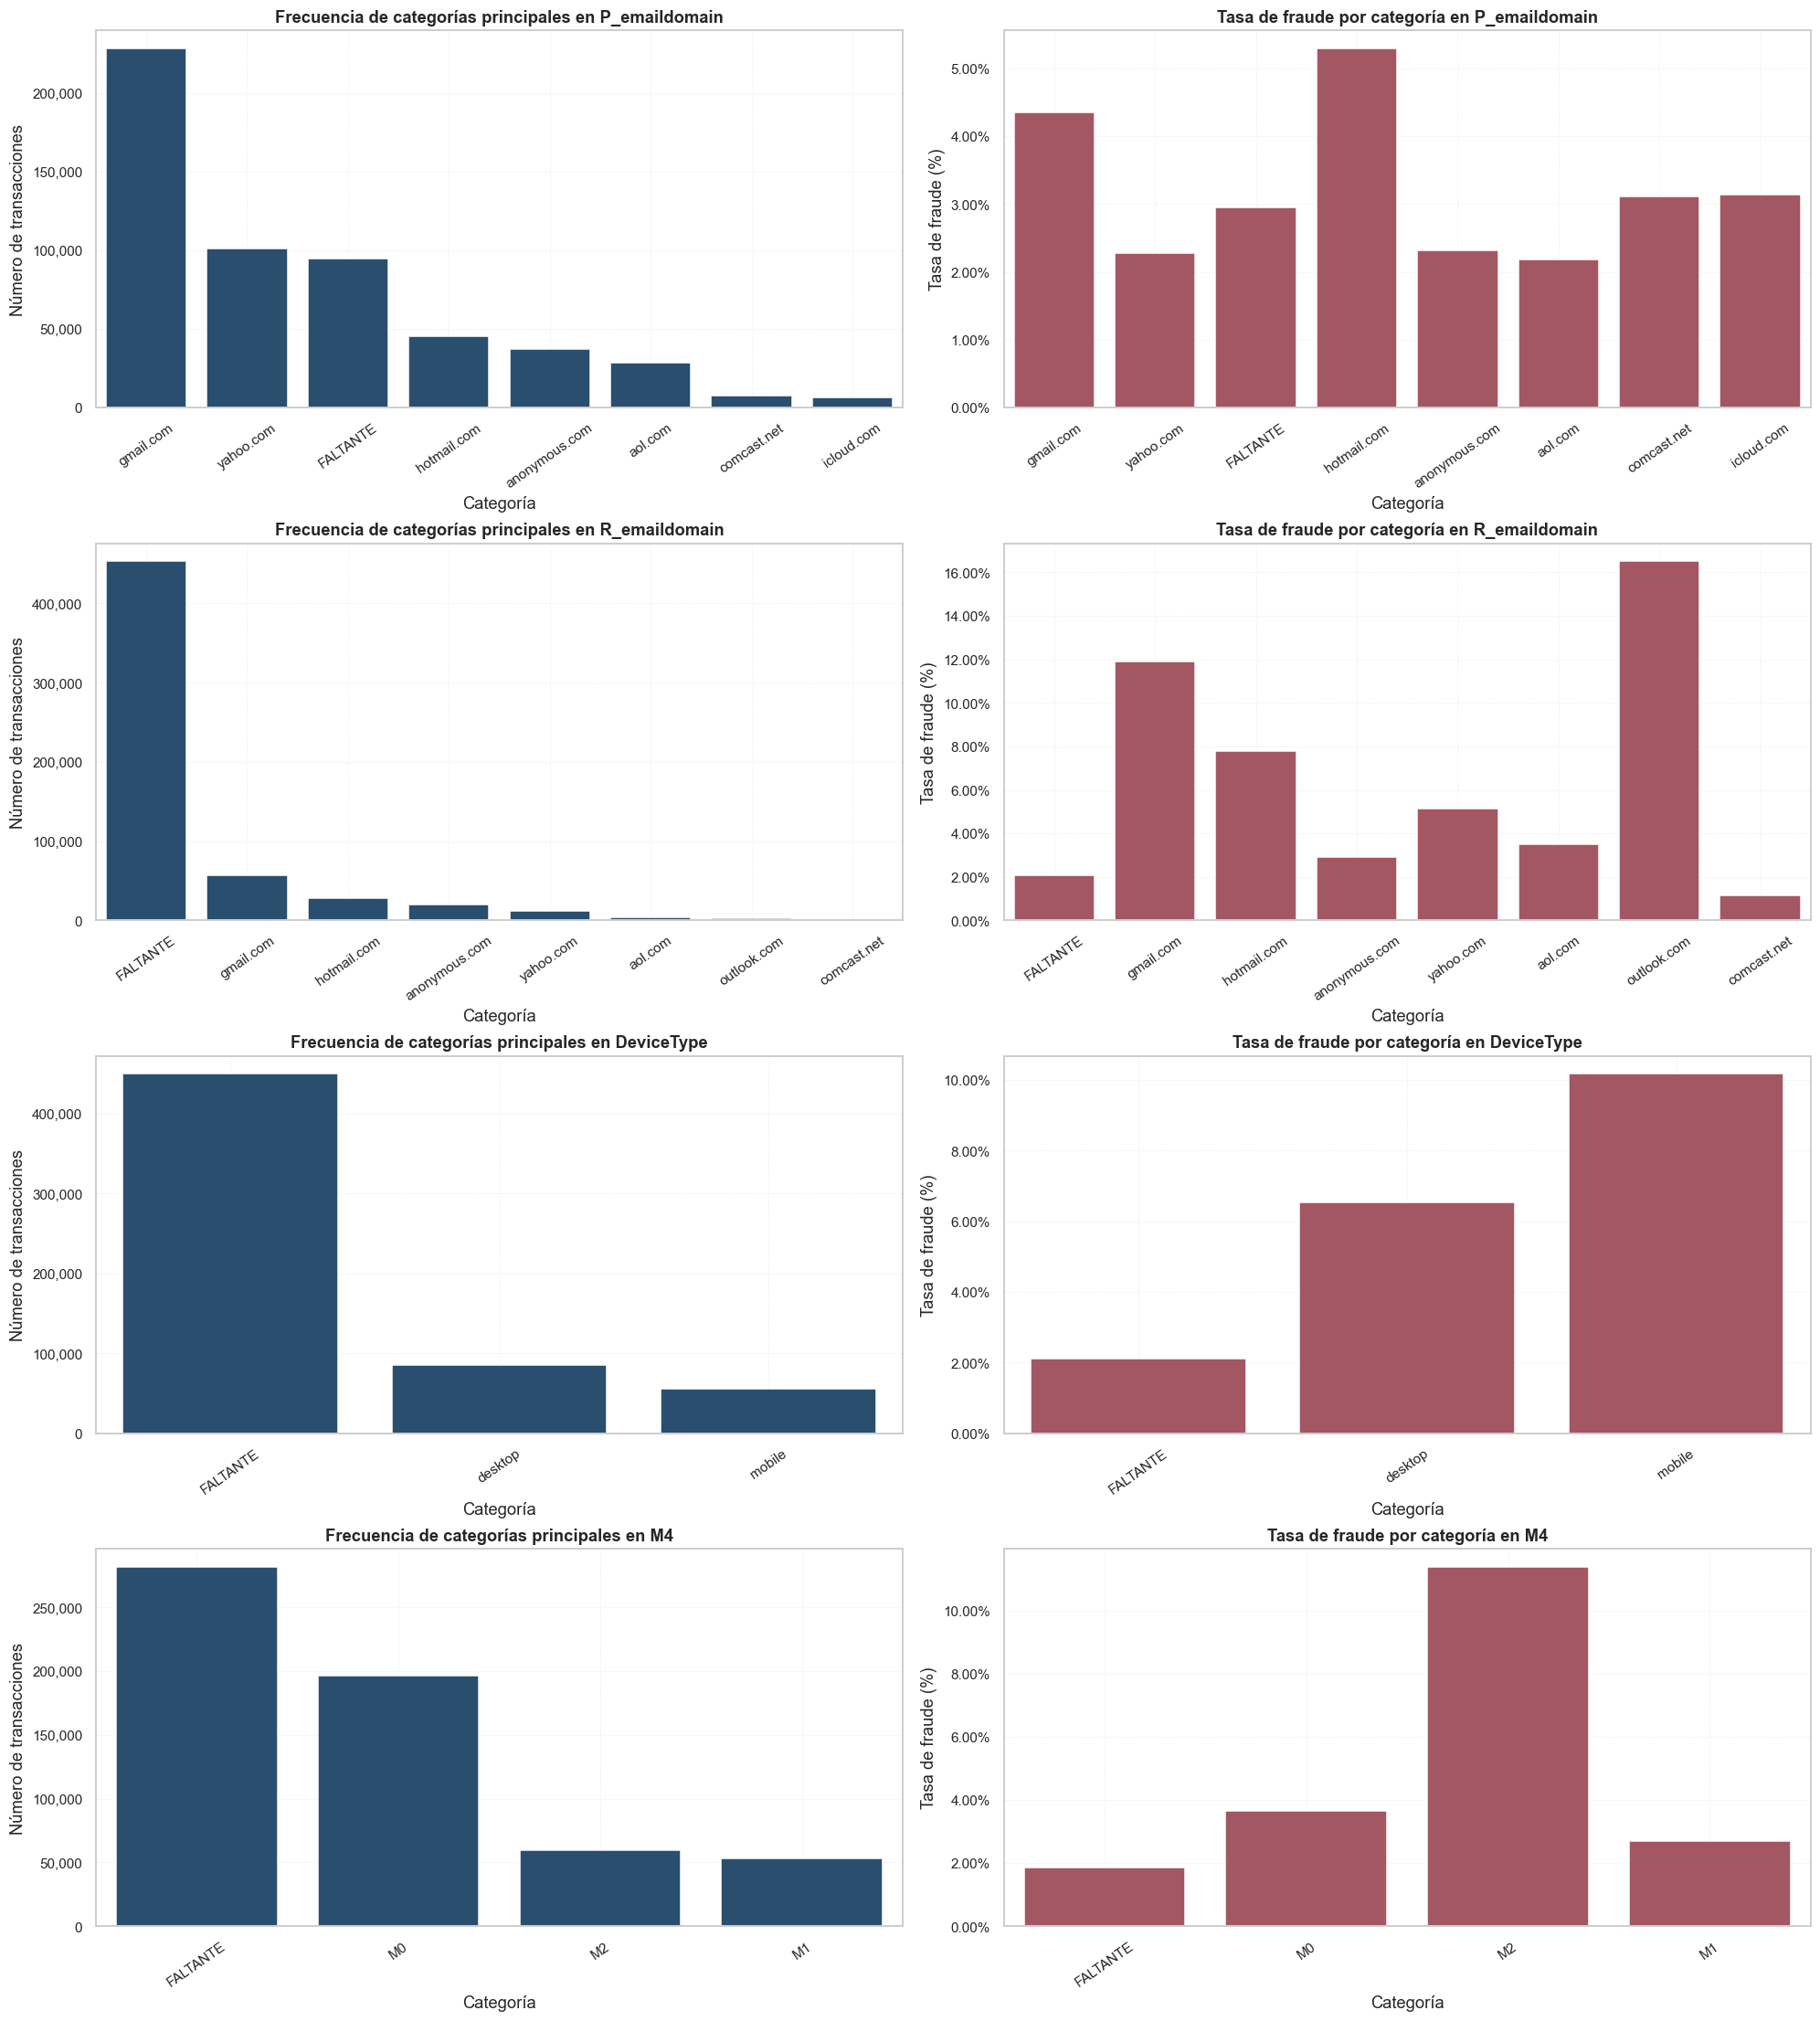

In [10]:
# Selección del segundo bloque categórico: correo, dispositivo e indicador M4 como señales de contexto transaccional.
categorical_block_two = [column for column in ["P_emaildomain", "R_emaildomain", "DeviceType", "M4"] if column in df_audit.columns]
categorical_block_two_tables = []

# Construcción de tablas resumen y visualizaciones comparativas para categorías interpretables y legibles.
fig, axes = plt.subplots(len(categorical_block_two), 2, figsize=(18, 5 * len(categorical_block_two)), constrained_layout=True)
axes = np.atleast_2d(axes)

for row_index, column in enumerate(categorical_block_two):
    plot_data = build_top_category_summary(df_audit, column, top_n=8)
    table_data = plot_data.copy()
    table_data.insert(0, "variable", column)
    categorical_block_two_tables.append(table_data[["variable", "categoría", "transacciones", "tasa_fraude_pct"]])

    sns.barplot(
        data=plot_data,
        x="categoría",
        y="transacciones",
        color="#1f4e79",
        ax=axes[row_index, 0],
    )
    axes[row_index, 0].set_title(f"Frecuencia de categorías principales en {column}", fontweight="semibold")
    axes[row_index, 0].set_xlabel("Categoría")
    axes[row_index, 0].set_ylabel("Número de transacciones")
    axes[row_index, 0].tick_params(axis="x", rotation=35)
    axes[row_index, 0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{int(value):,}"))

    sns.barplot(
        data=plot_data,
        x="categoría",
        y="tasa_fraude_pct",
        color="#b04a5a",
        ax=axes[row_index, 1],
    )
    axes[row_index, 1].set_title(f"Tasa de fraude por categoría en {column}", fontweight="semibold")
    axes[row_index, 1].set_xlabel("Categoría")
    axes[row_index, 1].set_ylabel("Tasa de fraude (%)")
    axes[row_index, 1].tick_params(axis="x", rotation=35)
    axes[row_index, 1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}%"))

for axis in axes.flatten():
    axis.grid(alpha=0.25, linestyle="--", linewidth=0.6)
    axis.tick_params(labelsize=10)

categorical_block_two_summary = pd.concat(categorical_block_two_tables, ignore_index=True)
categorical_block_two_display = categorical_block_two_summary.copy()
categorical_block_two_display["transacciones"] = categorical_block_two_display["transacciones"].map(format_integer)
categorical_block_two_display["tasa_fraude_pct"] = categorical_block_two_display["tasa_fraude_pct"].map(format_percentage)

print("Resumen de categorías principales: correo, dispositivo e indicador M4")
display(categorical_block_two_display.style.hide(axis="index"))
plt.show()


En las variables de correo y dispositivo destacan diferencias relevantes. `DeviceType` muestra una tasa de fraude claramente más alta en `mobile` que en `desktop`, mientras que `R_emaildomain` exhibe algunas categorías con riesgo elevado pese a una frecuencia bastante menor. En `M4`, la categoría `M2` concentra una señal de fraude visible y diferenciada frente al resto.

La importancia de este bloque reside en que combina variables de contexto transaccional con indicadores de consistencia y completitud. La limitación principal es que varias columnas incluyen una fracción sustancial de valores faltantes, y en dominios de correo menos frecuentes la tasa puede fluctuar por tamaño muestral reducido.


### 9.3 Estructura temporal y completitud de variables seleccionadas

El comportamiento temporal y la estructura de cobertura ayudan a dimensionar si el fenómeno cambia a lo largo del orden relativo de las transacciones y qué tan estable es la base informativa de las variables seleccionadas para la lectura exploratoria.


Cobertura de variables seleccionadas


variable,cobertura_pct
dist2,6.37%
R_emaildomain,23.25%
DeviceType,23.84%
dist1,40.35%
M4,52.34%
P_emaildomain,84.01%
card4,99.73%
card6,99.73%
TransactionAmt,100.00%
ProductCD,100.00%


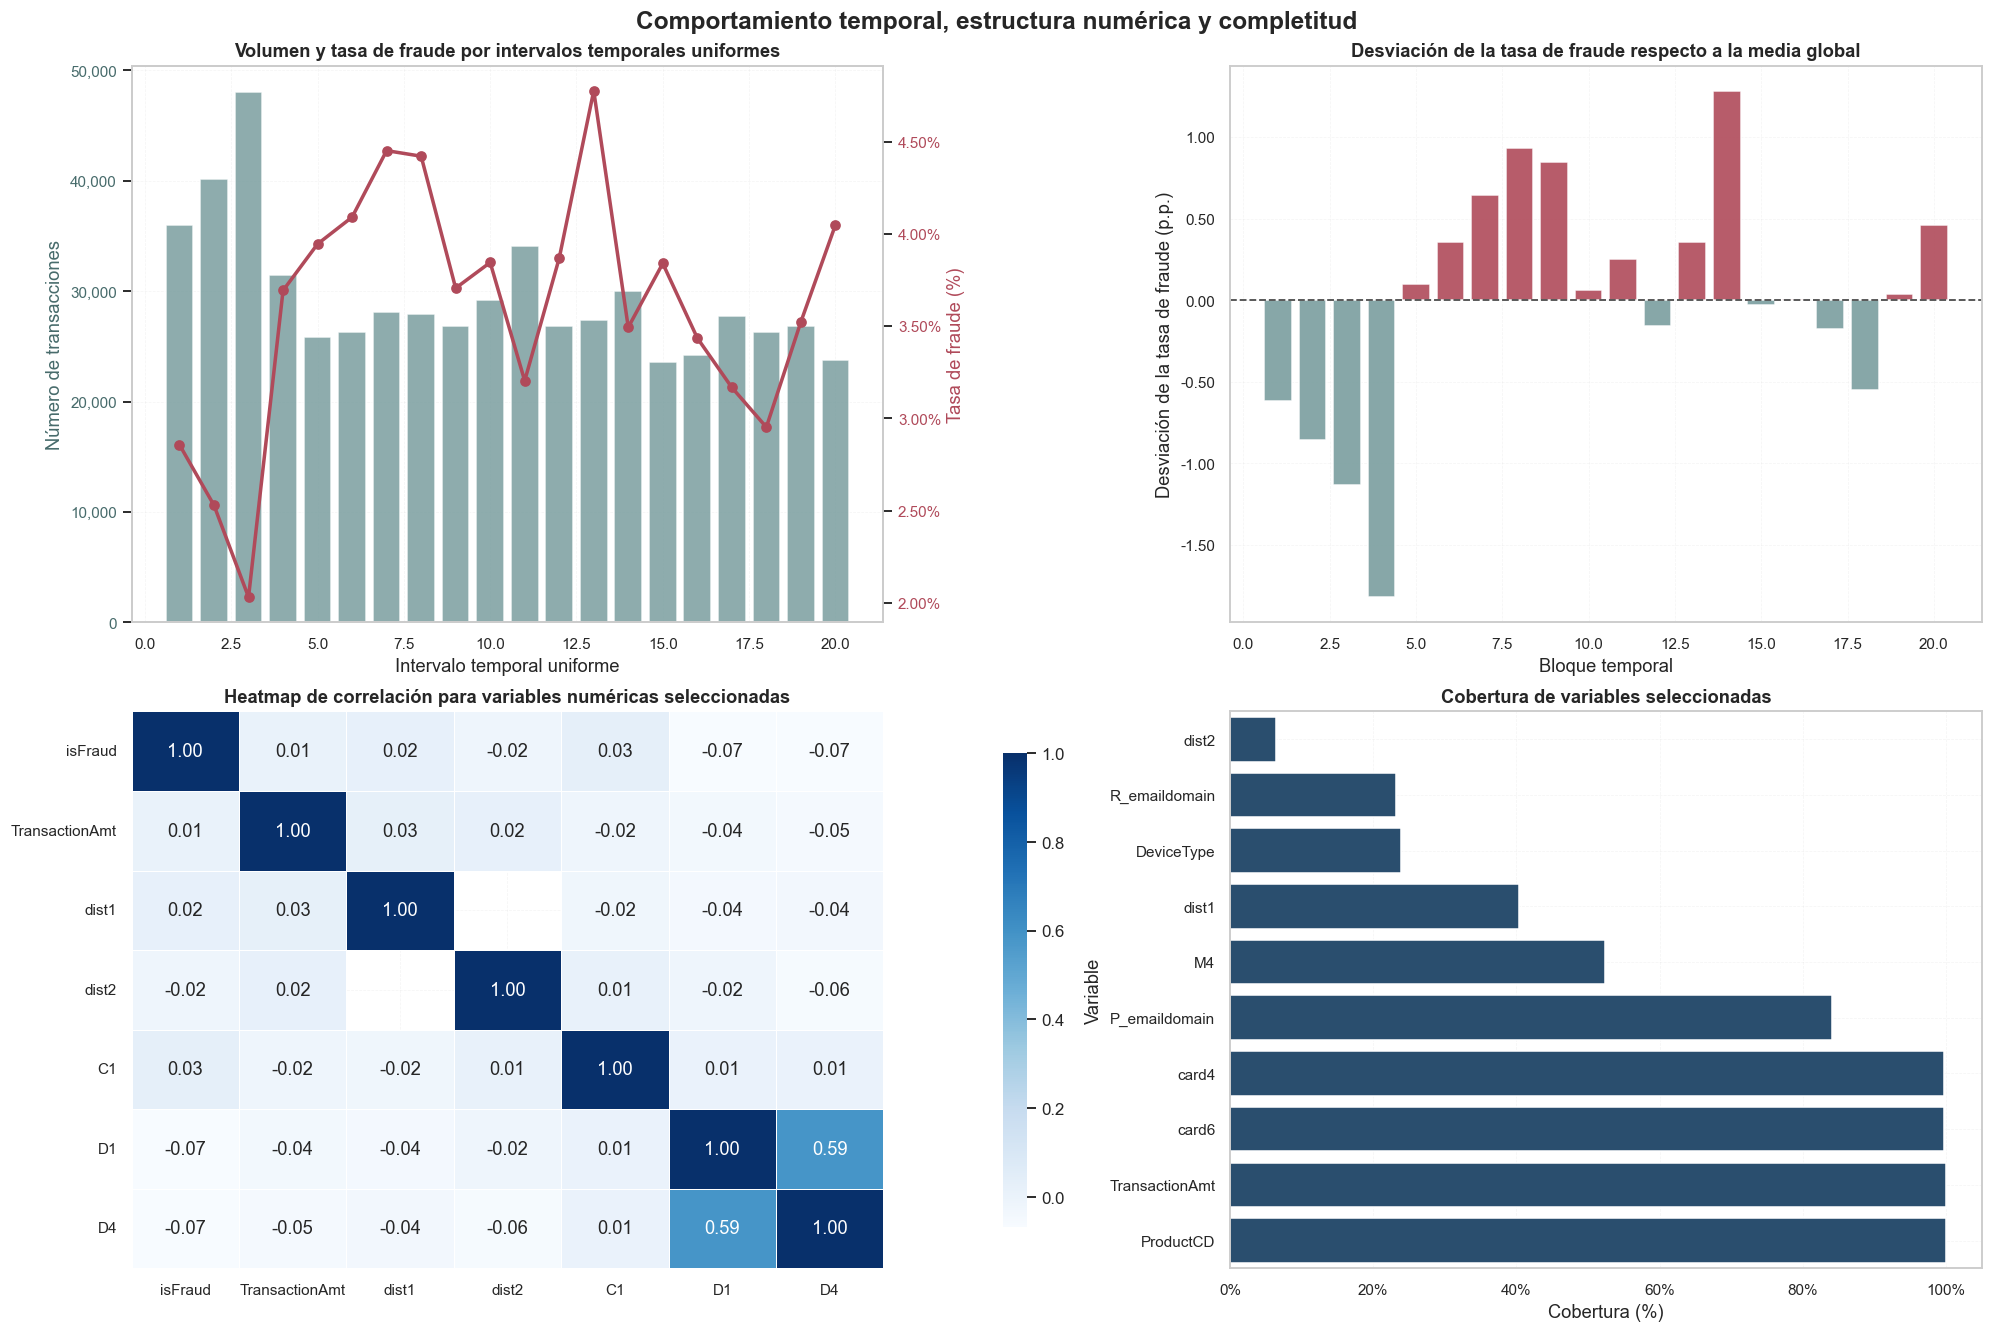

In [11]:
# Bloques temporales por cuantiles: estabilizan el tamaño de cada bloque para comparar tasas de fraude.
temporal_profile = df_audit[["TransactionDT", "isFraud"]].dropna().copy()
temporal_profile["bloque"] = pd.qcut(temporal_profile["TransactionDT"], q=20, duplicates="drop")
temporal_summary = (
    temporal_profile
    .groupby("bloque", observed=False)["isFraud"]
    .agg(transacciones="size", tasa_fraude="mean")
    .reset_index()
)
temporal_summary["tasa_fraude_pct"] = temporal_summary["tasa_fraude"] * 100
temporal_summary["bloque_temporal"] = np.arange(1, len(temporal_summary) + 1)

# Intervalos temporales de ancho uniforme: complementan los cuantiles al mostrar cambios de volumen y riesgo en el eje temporal.
temporal_uniform = df_audit[["TransactionDT", "isFraud"]].dropna().copy()
uniform_edges = np.linspace(
    temporal_uniform["TransactionDT"].min(),
    temporal_uniform["TransactionDT"].max(),
    21,
)
temporal_uniform["intervalo_uniforme"] = pd.cut(
    temporal_uniform["TransactionDT"],
    bins=uniform_edges,
    include_lowest=True,
    duplicates="drop",
)
temporal_uniform_summary = (
    temporal_uniform
    .groupby("intervalo_uniforme", observed=False)["isFraud"]
    .agg(transacciones="size", tasa_fraude="mean")
    .reset_index()
)
temporal_uniform_summary["tasa_fraude_pct"] = temporal_uniform_summary["tasa_fraude"] * 100
temporal_uniform_summary["bloque_uniforme"] = np.arange(1, len(temporal_uniform_summary) + 1)

# Cálculo de la tasa media global y su desviación por bloque temporal en puntos porcentuales.
global_fraud_rate_pct = df_audit["isFraud"].mean() * 100
temporal_summary["desviacion_pp"] = temporal_summary["tasa_fraude_pct"] - global_fraud_rate_pct
temporal_summary["color_desviacion"] = np.where(
    temporal_summary["desviacion_pp"] >= 0,
    "#b04a5a",
    "#7a9e9f",
)

# Selección razonable de variables numéricas para describir estructura correlacional interpretable.
correlation_vars = [column for column in ["isFraud", "TransactionAmt", "dist1", "dist2", "C1", "D1", "D4"] if column in df_audit.columns]
correlation_frame = df_audit[correlation_vars].copy()
correlation_matrix = correlation_frame.corr(numeric_only=True)

# Medición de completitud sobre variables seleccionadas para contextualizar cobertura y riesgo interpretativo.
coverage_vars = [column for column in ["TransactionAmt", "dist1", "dist2", "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain", "DeviceType", "M4"] if column in df_audit.columns]
coverage_summary = pd.DataFrame(
    {
        "variable": coverage_vars,
        "cobertura_pct": [df_audit[column].notna().mean() * 100 for column in coverage_vars],
    }
).sort_values("cobertura_pct", ascending=True)
coverage_display = coverage_summary.copy()
coverage_display["cobertura_pct"] = coverage_display["cobertura_pct"].map(format_percentage)

print("Cobertura de variables seleccionadas")
display(coverage_display.style.hide(axis="index"))

# Configuración del bloque gráfico de estructura temporal, correlacional y de completitud.
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

# Visualización combinada con intervalos temporales de ancho uniforme para distinguir volumen y riesgo.
axes[0, 0].bar(
    temporal_uniform_summary["bloque_uniforme"],
    temporal_uniform_summary["transacciones"],
    color="#7a9e9f",
    alpha=0.85,
)
axes[0, 0].set_title("Volumen y tasa de fraude por intervalos temporales uniformes", fontweight="semibold")
axes[0, 0].set_xlabel("Intervalo temporal uniforme")
axes[0, 0].set_ylabel("Número de transacciones", color="#476b6b")
axes[0, 0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{int(value):,}"))
axes[0, 0].tick_params(axis="y", labelcolor="#476b6b")

uniform_rate_axis = axes[0, 0].twinx()
uniform_rate_axis.plot(
    temporal_uniform_summary["bloque_uniforme"],
    temporal_uniform_summary["tasa_fraude_pct"],
    color="#b04a5a",
    marker="o",
    linewidth=2.3,
)
uniform_rate_axis.set_ylabel("Tasa de fraude (%)", color="#b04a5a")
uniform_rate_axis.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}%"))
uniform_rate_axis.tick_params(axis="y", labelcolor="#b04a5a")

# Visualización de la desviación temporal respecto a la tasa media global en puntos porcentuales.
axes[0, 1].bar(
    temporal_summary["bloque_temporal"],
    temporal_summary["desviacion_pp"],
    color=temporal_summary["color_desviacion"],
    alpha=0.90,
)
axes[0, 1].axhline(0, color="#4f4f4f", linewidth=1.2, linestyle="--")
axes[0, 1].set_title("Desviación de la tasa de fraude respecto a la media global", fontweight="semibold")
axes[0, 1].set_xlabel("Bloque temporal")
axes[0, 1].set_ylabel("Desviación de la tasa de fraude (p.p.)")
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}"))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"shrink": 0.85},
    ax=axes[1, 0],
)
axes[1, 0].set_title("Heatmap de correlación para variables numéricas seleccionadas", fontweight="semibold")

sns.barplot(
    data=coverage_summary,
    x="cobertura_pct",
    y="variable",
    color="#1f4e79",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Cobertura de variables seleccionadas", fontweight="semibold")
axes[1, 1].set_xlabel("Cobertura (%)")
axes[1, 1].set_ylabel("Variable")
axes[1, 1].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0f}%"))

for axis in axes.flatten():
    axis.grid(alpha=0.20, linestyle="--", linewidth=0.5)
    axis.tick_params(labelsize=10)

uniform_rate_axis.grid(False)
uniform_rate_axis.tick_params(labelsize=10)

fig.suptitle("Comportamiento temporal, estructura numérica y completitud", fontsize=16, fontweight="semibold")
plt.show()


Las visualizaciones muestran cuánto se aparta cada bloque temporal de la tasa media global de fraude, expresando esa diferencia en puntos porcentuales. Los valores positivos indican bloques con intensidad relativa superior al promedio del dataset, mientras que los valores negativos corresponden a bloques con intensidad relativa menor.

Esta lectura ayuda a identificar con rapidez qué segmentos temporales concentran una presión relativa más alta o más baja del fenómeno dentro del orden observado en `TransactionDT`. La interpretación debe mantenerse prudente, ya que se trata de un patrón descriptivo condicionado por la estructura temporal disponible en el conjunto de datos.

El heatmap confirma que las correlaciones lineales entre variables seleccionadas son, en general, moderadas o bajas, con la excepción de algunas relaciones internas como `D1` y `D4`. Esto indica que la señal no depende de una sola estructura lineal dominante y que distintas variables pueden aportar información complementaria sin redundancia inmediata.

La visualización de cobertura deja claro que columnas como `dist2`, `R_emaildomain` y `DeviceType` son potencialmente informativas, pero su disponibilidad es muy desigual. Esa limitación condiciona la fuerza interpretativa de cualquier patrón observado sobre subconjuntos con alta incompletitud.


### 9.4 Hallazgos relevantes del análisis exploratorio

Los patrones principales detectados muestran que la señal de fraude no se distribuye de forma homogénea. En variables numéricas, `TransactionAmt` presenta un comportamiento no lineal por rangos, mientras que `C1` y `D1` exhiben contrastes visibles entre fraude y no fraude. En variables categóricas, `ProductCD`, `card6`, `DeviceType`, `M4` y ciertos dominios de correo revelan segmentos con riesgo relativo claramente diferenciado.

Los segmentos con mayor tasa de fraude aparente se concentran en algunas categorías específicas de producto y comunicación, en transacciones asociadas con `DeviceType = mobile`, en la categoría `M4 = M2`, y en determinados rangos de monto y bloques temporales. Estas señales no se explican únicamente por frecuencia, lo que refuerza la necesidad de distinguir volumen de riesgo.

La estructura del problema también muestra complejidades relevantes: alta dimensionalidad, cobertura desigual en variables de identidad y dominios con distribución muy fragmentada. Esta combinación sugiere un fenómeno heterogéneo, con subpoblaciones que exhiben perfiles de riesgo claramente distintos dentro del mismo dataset.


### 9.5 Consideraciones analíticas del análisis exploratorio

En este dataset conviene separar con cuidado frecuencia y riesgo. Una categoría puede concentrar una gran proporción del volumen transaccional y, al mismo tiempo, mostrar una tasa de fraude relativamente moderada; de forma inversa, una categoría menos frecuente puede exhibir un riesgo porcentual alto sin dominar el conteo total de casos.

El desbalance de clases condiciona toda lectura exploratoria: pequeños cambios en la tasa de fraude pueden resultar relevantes, pero también pueden sobredimensionarse si no se consideran el tamaño muestral y la estabilidad de cada segmento. Esta tensión se vuelve más visible en categorías raras o en variables con fuerte fragmentación.

El EDA tiene límites interpretativos claros. Los patrones observados describen asociaciones dentro del conjunto disponible, pero no equivalen a evidencia causal ni a garantía de generalización. Además, las variables muy incompletas o extremadamente dispersas requieren una lectura prudente, porque la señal aparente puede depender de subconjuntos restringidos del universo transaccional.


## 10. Diseño metodológico, partición temporal y preprocesamiento

Este apartado establece una base reproducible para la preparación de datos en el problema de detección de fraude. El énfasis metodológico recae en tres principios: construir un pipeline consistente, evitar fuga de información durante la preparación de variables y respetar la estructura temporal relativa contenida en `TransactionDT`.

La intención no es entrenar modelos en este punto, sino dejar definidos y documentados los insumos que permiten alimentar algoritmos supervisados bajo criterios comparables y técnicamente defendibles.


### 10.1 Estrategia de partición temporal por TransactionDT

La partición se construye siguiendo el orden temporal relativo del dataset. En lugar de mezclar observaciones de forma aleatoria, se separan tres subconjuntos cronológicos usando cortes sobre valores únicos de `TransactionDT`: entrenamiento, validación y prueba.

Este criterio reduce el riesgo de sobreestimar desempeño mediante una mezcla artificial de registros tempranos y recientes. En problemas de fraude, un split aleatorio puede mezclar patrones de comportamiento que pertenecen a momentos distintos del proceso transaccional y producir una evaluación metodológicamente optimista.


Resumen de la partición temporal


conjunto,observaciones,participacion_pct,casos_fraude,tasa_fraude_pct,inicio_dt,fin_dt
Entrenamiento,"414,447",70.18%,"14,588",3.52%,"86,400","10,452,989"
Validación,"88,013",14.90%,"3,010",3.42%,"10,453,011","13,179,648"
Prueba,"88,080",14.92%,"3,065",3.48%,"13,179,655","15,811,131"


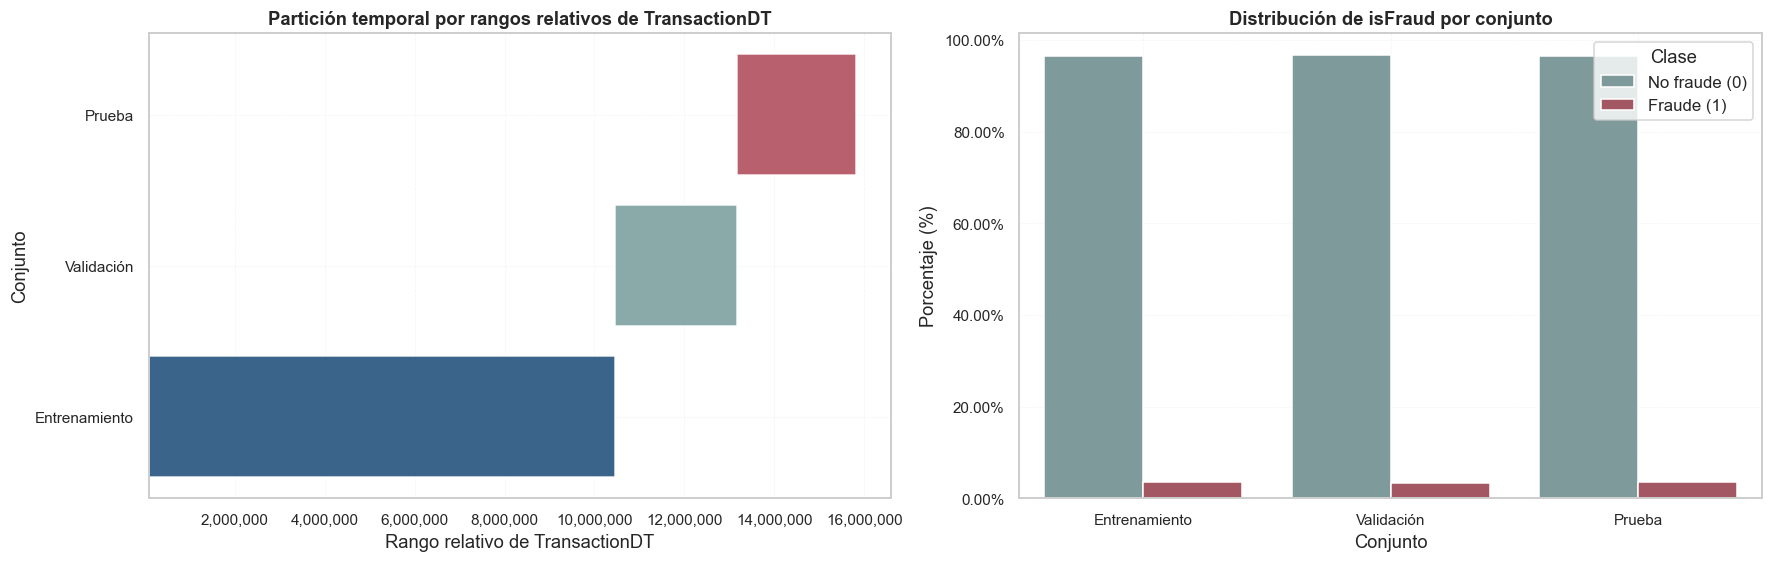

In [12]:
# Definición de columnas clave: centraliza la variable objetivo y el eje temporal para evitar inconsistencias posteriores.
target_column = "isFraud"
time_column = "TransactionDT"

# Copia de trabajo del dataset unido para evitar mutaciones accidentales sobre df_audit.
df_model_base = df_audit.copy()

# Validación de la columna temporal requerida para la estrategia cronológica.
if time_column not in df_model_base.columns:
    raise KeyError("La columna 'TransactionDT' no está disponible para construir la partición temporal.")

# Los cortes se calculan sobre valores temporales ordenados para preservar la secuencia relativa de TransactionDT.
sorted_time_values = np.sort(df_model_base[time_column].dropna().unique())
train_cut_index = min(int(len(sorted_time_values) * 0.70), len(sorted_time_values) - 1)
validation_cut_index = min(int(len(sorted_time_values) * 0.85), len(sorted_time_values) - 1)
train_cutoff = sorted_time_values[train_cut_index]
validation_cutoff = sorted_time_values[validation_cut_index]

# Construcción de subconjuntos cronológicos no superpuestos: entrenamiento, validación y prueba mantienen orden temporal.
train_mask = df_model_base[time_column] <= train_cutoff
validation_mask = (df_model_base[time_column] > train_cutoff) & (df_model_base[time_column] <= validation_cutoff)
test_mask = df_model_base[time_column] > validation_cutoff

# Almacenamiento de subconjuntos con nombres explícitos para reutilización posterior.
split_frames = {
    "Entrenamiento": df_model_base.loc[train_mask].copy(),
    "Validación": df_model_base.loc[validation_mask].copy(),
    "Prueba": df_model_base.loc[test_mask].copy(),
}

# Resumen descriptivo de cada partición para documentar tamaño, rango temporal y prevalencia de fraude.
split_summary_rows = []
for split_name, split_df in split_frames.items():
    split_summary_rows.append(
        {
            "conjunto": split_name,
            "observaciones": len(split_df),
            "participacion_pct": (len(split_df) / len(df_model_base)) * 100,
            "casos_fraude": int(split_df[target_column].sum()),
            "tasa_fraude_pct": split_df[target_column].mean() * 100,
            "inicio_dt": int(split_df[time_column].min()),
            "fin_dt": int(split_df[time_column].max()),
        }
    )

split_summary = pd.DataFrame(split_summary_rows)
split_summary_display = split_summary.copy()
split_summary_display["observaciones"] = split_summary_display["observaciones"].map(format_integer)
split_summary_display["participacion_pct"] = split_summary_display["participacion_pct"].map(format_percentage)
split_summary_display["casos_fraude"] = split_summary_display["casos_fraude"].map(format_integer)
split_summary_display["tasa_fraude_pct"] = split_summary_display["tasa_fraude_pct"].map(format_percentage)
split_summary_display["inicio_dt"] = split_summary_display["inicio_dt"].map(format_integer)
split_summary_display["fin_dt"] = split_summary_display["fin_dt"].map(format_integer)

print("Resumen de la partición temporal")
display(split_summary_display.style.hide(axis="index"))

# Construcción de la distribución porcentual de la variable objetivo en cada subconjunto.
class_distribution_rows = []
for split_name, split_df in split_frames.items():
    class_distribution = (
        split_df[target_column]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )
    for class_value, percentage in class_distribution.items():
        class_distribution_rows.append(
            {
                "conjunto": split_name,
                "clase": "No fraude (0)" if class_value == 0 else "Fraude (1)",
                "porcentaje": percentage,
            }
        )

class_distribution_df = pd.DataFrame(class_distribution_rows)

# Preparación de rangos temporales para una visualización simple y directa de la partición cronológica.
partition_ranges = split_summary[["conjunto", "inicio_dt", "fin_dt"]].copy()
partition_ranges["duracion"] = partition_ranges["fin_dt"] - partition_ranges["inicio_dt"]
partition_colors = {
    "Entrenamiento": "#1f4e79",
    "Validación": "#7a9e9f",
    "Prueba": "#b04a5a",
}

# Visualización conjunta del rango temporal asignado a cada conjunto y de la distribución de la variable objetivo.
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

for _, row in partition_ranges.iterrows():
    axes[0].barh(
        y=row["conjunto"],
        width=row["duracion"],
        left=row["inicio_dt"],
        color=partition_colors[row["conjunto"]],
        alpha=0.88,
    )

axes[0].set_title("Partición temporal por rangos relativos de TransactionDT", fontweight="semibold")
axes[0].set_xlabel("Rango relativo de TransactionDT")
axes[0].set_ylabel("Conjunto")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{int(value):,}"))

sns.barplot(
    data=class_distribution_df,
    x="conjunto",
    y="porcentaje",
    hue="clase",
    palette=["#7a9e9f", "#b04a5a"],
    ax=axes[1],
)
axes[1].set_title("Distribución de isFraud por conjunto", fontweight="semibold")
axes[1].set_xlabel("Conjunto")
axes[1].set_ylabel("Porcentaje (%)")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}%"))
axes[1].legend(title="Clase")

for axis in axes:
    axis.grid(alpha=0.20, linestyle="--", linewidth=0.5)
    axis.tick_params(labelsize=10)

plt.show()


La partición elegida preserva el orden relativo de `TransactionDT` y genera subconjuntos cronológicos no superpuestos. La prevalencia de fraude se mantiene en un rango cercano entre entrenamiento, validación y prueba, aunque con pequeñas variaciones que reflejan cambios del fenómeno a lo largo del tiempo.

Esta decisión tiene una implicación metodológica directa: el ajuste del pipeline y la evaluación quedan anclados en un esquema temporal más realista que un split aleatorio puro. Aun así, sigue existiendo el límite de que `TransactionDT` representa un desplazamiento relativo y no una fecha calendario explícita.


### 10.2 Depuración inicial de variables por faltantes y variabilidad

La depuración se define con reglas simples y reproducibles aplicadas únicamente sobre el conjunto de entrenamiento. El criterio principal excluye variables con un nivel extremo de faltantes y, de manera complementaria, elimina identificadores técnicos o columnas sin variación observable.


Columnas eliminadas y motivo de exclusión


columna,motivo,faltantes_entrenamiento_pct
id_24,Faltantes > 95% en entrenamiento,99.13%
id_25,Faltantes > 95% en entrenamiento,99.05%
id_07,Faltantes > 95% en entrenamiento,99.05%
id_08,Faltantes > 95% en entrenamiento,99.05%
id_26,Faltantes > 95% en entrenamiento,99.05%
id_21,Faltantes > 95% en entrenamiento,99.05%
id_22,Faltantes > 95% en entrenamiento,99.05%
id_23,Faltantes > 95% en entrenamiento,99.05%
id_27,Faltantes > 95% en entrenamiento,99.05%
TransactionID,Identificador técnico,0.00%



Inventario de variables después de la depuración inicial


métrica,valor
Columnas originales,433
Columnas eliminadas,11
Columnas conservadas,422
Variables numéricas finales,393
Variables categóricas finales,29


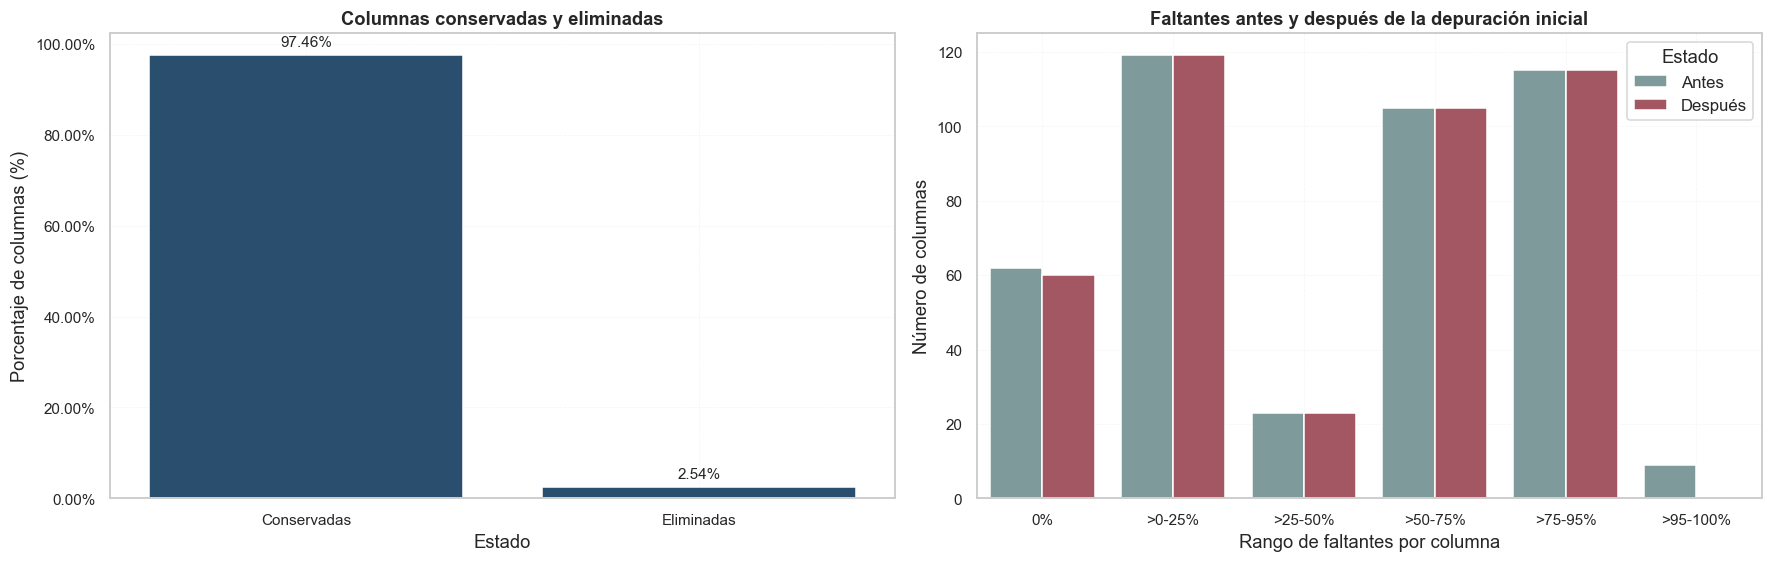

In [13]:
# Separación inicial de variable objetivo y variables predictoras en cada subconjunto.
X_train_raw = split_frames["Entrenamiento"].drop(columns=[target_column]).copy()
X_validation_raw = split_frames["Validación"].drop(columns=[target_column]).copy()
X_test_raw = split_frames["Prueba"].drop(columns=[target_column]).copy()
y_train = split_frames["Entrenamiento"][target_column].copy()
y_validation = split_frames["Validación"][target_column].copy()
y_test = split_frames["Prueba"][target_column].copy()

# El porcentaje de faltantes se calcula solo con entrenamiento para evitar fuga de información desde validación o prueba.
high_missing_threshold = 95.0
train_missing_pct = X_train_raw.isna().mean() * 100
high_missing_columns = train_missing_pct[train_missing_pct > high_missing_threshold].sort_values(ascending=False)

# Identificación de columnas técnicas o sin variación que no aportan valor al modelado supervisado.
identifier_columns = [column for column in ["TransactionID"] if column in X_train_raw.columns]
constant_columns = [column for column in X_train_raw.columns if X_train_raw[column].nunique(dropna=False) <= 1]

# Consolidación de columnas a excluir con justificación explícita y reproducible.
columns_to_drop = sorted(set(high_missing_columns.index.tolist() + identifier_columns + constant_columns))
drop_report_rows = []
for column in columns_to_drop:
    reasons = []
    if column in identifier_columns:
        reasons.append("Identificador técnico")
    if column in high_missing_columns.index:
        reasons.append(f"Faltantes > {high_missing_threshold:.0f}% en entrenamiento")
    if column in constant_columns:
        reasons.append("Varianza nula en entrenamiento")
    drop_report_rows.append(
        {
            "columna": column,
            "motivo": "; ".join(reasons),
            "faltantes_entrenamiento_pct": train_missing_pct[column],
        }
    )

dropped_columns_report = pd.DataFrame(drop_report_rows).sort_values(
    by=["faltantes_entrenamiento_pct", "columna"],
    ascending=[False, True],
).reset_index(drop=True)

# La lista de columnas excluidas se aprende en entrenamiento y se aplica sin cambios a validación y prueba.
X_train_filtered = X_train_raw.drop(columns=columns_to_drop).copy()
X_validation_filtered = X_validation_raw.drop(columns=columns_to_drop).copy()
X_test_filtered = X_test_raw.drop(columns=columns_to_drop).copy()

# Identificación del inventario final de variables numéricas y categóricas después de la depuración.
numeric_features_final = X_train_filtered.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_final = X_train_filtered.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Tabla resumen del universo de variables antes y después de la depuración inicial.
feature_inventory = pd.DataFrame(
    {
        "métrica": [
            "Columnas originales",
            "Columnas eliminadas",
            "Columnas conservadas",
            "Variables numéricas finales",
            "Variables categóricas finales",
        ],
        "valor": [
            format_integer(X_train_raw.shape[1]),
            format_integer(len(columns_to_drop)),
            format_integer(X_train_filtered.shape[1]),
            format_integer(len(numeric_features_final)),
            format_integer(len(categorical_features_final)),
        ],
    }
)

# Formateo del reporte de exclusiones para facilitar su revisión en el notebook.
dropped_columns_display = dropped_columns_report.copy()
dropped_columns_display["faltantes_entrenamiento_pct"] = dropped_columns_display["faltantes_entrenamiento_pct"].map(format_percentage)

print("Columnas eliminadas y motivo de exclusión")
display(dropped_columns_display.style.hide(axis="index"))
print("\nInventario de variables después de la depuración inicial")
display(feature_inventory.style.hide(axis="index"))

# Construcción de una comparación simple entre columnas eliminadas y conservadas.
column_status_summary = pd.DataFrame(
    {
        "estado": ["Conservadas", "Eliminadas"],
        "cantidad": [X_train_filtered.shape[1], len(columns_to_drop)],
    }
)
column_status_summary["porcentaje"] = (column_status_summary["cantidad"] / X_train_raw.shape[1]) * 100

# Distribución de faltantes antes y después de la depuración usando rangos interpretables.
missing_bin_edges = [-0.01, 0.0, 25.0, 50.0, 75.0, 95.0, 100.0]
missing_bin_labels = ["0%", ">0-25%", ">25-50%", ">50-75%", ">75-95%", ">95-100%"]
missing_before_bucket = pd.cut(
    train_missing_pct,
    bins=missing_bin_edges,
    labels=missing_bin_labels,
    include_lowest=True,
)
missing_after_pct = X_train_filtered.isna().mean() * 100
missing_after_bucket = pd.cut(
    missing_after_pct,
    bins=missing_bin_edges,
    labels=missing_bin_labels,
    include_lowest=True,
)
missing_bucket_summary = pd.concat(
    [
        missing_before_bucket.value_counts().reindex(missing_bin_labels, fill_value=0).rename("Antes"),
        missing_after_bucket.value_counts().reindex(missing_bin_labels, fill_value=0).rename("Después"),
    ],
    axis=1,
).reset_index().rename(columns={"index": "rango_faltantes"})
missing_bucket_plot = missing_bucket_summary.melt(
    id_vars="rango_faltantes",
    var_name="estado",
    value_name="columnas",
)

# Visualización de depuración para revisar impacto estructural sobre el conjunto de variables.
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

status_plot = sns.barplot(
    data=column_status_summary,
    x="estado",
    y="porcentaje",
    color="#1f4e79",
    ax=axes[0],
)
axes[0].set_title("Columnas conservadas y eliminadas", fontweight="semibold")
axes[0].set_xlabel("Estado")
axes[0].set_ylabel("Porcentaje de columnas (%)")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.2f}%"))
axes[0].bar_label(
    status_plot.containers[0],
    labels=[f"{value:.2f}%" for value in column_status_summary["porcentaje"]],
    padding=4,
    fontsize=10,
)

sns.barplot(
    data=missing_bucket_plot,
    x="rango_faltantes",
    y="columnas",
    hue="estado",
    palette=["#7a9e9f", "#b04a5a"],
    ax=axes[1],
)
axes[1].set_title("Faltantes antes y después de la depuración inicial", fontweight="semibold")
axes[1].set_xlabel("Rango de faltantes por columna")
axes[1].set_ylabel("Número de columnas")
axes[1].legend(title="Estado")

for axis in axes:
    axis.grid(alpha=0.20, linestyle="--", linewidth=0.5)
    axis.tick_params(labelsize=10)

plt.show()


La depuración inicial cambia el universo de variables de forma controlada: se excluyen columnas extremadamente incompletas, un identificador técnico y una variable sin variación en entrenamiento. El resultado conserva un espacio descriptivo amplio, con predominio de variables numéricas y un conjunto acotado de variables categóricas interpretables.

El gráfico de faltantes muestra que, aun después de esta depuración, persiste un número importante de columnas con incompletitud considerable. Esto implica que la imputación no es un detalle accesorio, sino una pieza central del diseño metodológico. La ventaja del criterio adoptado es que se mantiene estable, explícito y fácil de reproducir.


### 10.3 Preparación reproducible de datos con ColumnTransformer

La preparación se implementa mediante transformadores explícitos de scikit-learn ajustados únicamente sobre entrenamiento. Este esquema permite tratar faltantes de forma homogénea, preservar categorías no observadas mediante reglas consistentes y producir matrices listas para alimentar modelos supervisados sin decisiones dispersas en distintas celdas.


In [14]:
# Importaciones específicas para construir un pipeline reproducible de preprocesamiento.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Pipeline numérico: usa mediana aprendida en entrenamiento y conserva señales de ausencia mediante indicadores.
numeric_pipeline = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median", add_indicator=True)),
    ]
)

# Pipeline categórico: crea una categoría explícita para faltantes y codifica etiquetas de forma robusta ante valores no vistos.
categorical_pipeline = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="constant", fill_value="FALTANTE")),
        (
            "codificador",
            OneHotEncoder(handle_unknown="ignore", min_frequency=0.001, sparse_output=True),
        ),
    ]
)

# Integración de transformadores numéricos y categóricos en una sola estructura reproducible.
model_preprocessor = ColumnTransformer(
    transformers=[
        ("numericas", numeric_pipeline, numeric_features_final),
        ("categoricas", categorical_pipeline, categorical_features_final),
    ],
    remainder="drop",
    sparse_threshold=1.0,
)

# El preprocesador se ajusta solo en entrenamiento; validación y prueba se transforman con parámetros ya aprendidos.
X_train_prepared = model_preprocessor.fit_transform(X_train_filtered)
X_validation_prepared = model_preprocessor.transform(X_validation_filtered)
X_test_prepared = model_preprocessor.transform(X_test_filtered)
prepared_feature_names = model_preprocessor.get_feature_names_out()

# Función auxiliar para resumir dimensiones y densidad de las matrices preparadas.
def summarize_matrix(matrix, split_name: str) -> dict:
    """Resume forma, tipo y densidad aproximada de una matriz preparada."""

    non_zero = matrix.nnz if hasattr(matrix, "nnz") else int(np.count_nonzero(matrix))
    density_pct = (non_zero / (matrix.shape[0] * matrix.shape[1])) * 100
    return {
        "conjunto": split_name,
        "filas": matrix.shape[0],
        "columnas_transformadas": matrix.shape[1],
        "tipo_matriz": type(matrix).__name__,
        "densidad_pct": density_pct,
    }


# Resumen de componentes del preprocesador para documentar la función de cada bloque.
pipeline_components = pd.DataFrame(
    {
        "componente": [
            "Imputación numérica",
            "Indicadores de ausencia numérica",
            "Imputación categórica",
            "Codificación categórica",
        ],
        "aplica_a": [
            "Variables numéricas",
            "Variables numéricas",
            "Variables categóricas",
            "Variables categóricas",
        ],
        "función": [
            "Reemplaza faltantes con la mediana calculada en entrenamiento.",
            "Añade banderas cuando una variable numérica estuvo ausente.",
            "Asigna la etiqueta FALTANTE a categorías ausentes.",
            "Expande categorías y agrupa etiquetas muy raras con min_frequency=0.001.",
        ],
    }
)

# Resumen final de matrices listas para alimentar modelos supervisados.
prepared_matrices_summary = pd.DataFrame(
    [
        summarize_matrix(X_train_prepared, "Entrenamiento"),
        summarize_matrix(X_validation_prepared, "Validación"),
        summarize_matrix(X_test_prepared, "Prueba"),
    ]
)
prepared_matrices_display = prepared_matrices_summary.copy()
prepared_matrices_display["filas"] = prepared_matrices_display["filas"].map(format_integer)
prepared_matrices_display["columnas_transformadas"] = prepared_matrices_display["columnas_transformadas"].map(format_integer)
prepared_matrices_display["densidad_pct"] = prepared_matrices_display["densidad_pct"].map(format_percentage)

# Resumen adicional de la salida del preprocesador para registrar el inventario transformado.
prepared_inventory = pd.DataFrame(
    {
        "métrica": [
            "Variables numéricas de entrada",
            "Variables categóricas de entrada",
            "Columnas transformadas finales",
        ],
        "valor": [
            format_integer(len(numeric_features_final)),
            format_integer(len(categorical_features_final)),
            format_integer(len(prepared_feature_names)),
        ],
    }
)

print("Componentes del pipeline de preprocesamiento")
display(pipeline_components.style.hide(axis="index"))
print("\nResumen de matrices preparadas")
display(prepared_matrices_display.style.hide(axis="index"))
print("\nInventario final del espacio transformado")
display(prepared_inventory.style.hide(axis="index"))


Componentes del pipeline de preprocesamiento


componente,aplica_a,función
Imputación numérica,Variables numéricas,Reemplaza faltantes con la mediana calculada en entrenamiento.
Indicadores de ausencia numérica,Variables numéricas,Añade banderas cuando una variable numérica estuvo ausente.
Imputación categórica,Variables categóricas,Asigna la etiqueta FALTANTE a categorías ausentes.
Codificación categórica,Variables categóricas,Expande categorías y agrupa etiquetas muy raras con min_frequency=0.001.



Resumen de matrices preparadas


conjunto,filas,columnas_transformadas,tipo_matriz,densidad_pct
Entrenamiento,"414,447",928,csr_matrix,40.38%
Validación,"88,013",928,csr_matrix,41.17%
Prueba,"88,080",928,csr_matrix,40.73%



Inventario final del espacio transformado


métrica,valor
Variables numéricas de entrada,393
Variables categóricas de entrada,29
Columnas transformadas finales,928


El pipeline construido transforma el conjunto de entrenamiento sin exponer los subconjuntos de validación y prueba a estadísticas externas. La combinación de imputación por mediana, indicadores de ausencia y codificación categórica robusta deja una base uniforme para alimentar modelos con estructuras de entrada consistentes.

Después de la depuración y del preprocesamiento, el espacio transformado sigue siendo amplio, pero permanece trazable y reproducible. El principal límite que persiste es la coexistencia de alta dimensionalidad con variables todavía muy incompletas, incluso tras excluir las más extremas.


### 10.4 Riesgos de fuga de información

La fuga de información puede aparecer en varios puntos de este problema. Una primera fuente surge si la partición mezcla observaciones de distintos momentos temporales, porque el conjunto de entrenamiento termina absorbiendo patrones que pertenecen a regiones cronológicas reservadas para validación o prueba. Otra fuente aparece cuando los criterios de depuración o las estadísticas de imputación se calculan usando todo el dataset antes de separar subconjuntos.

En este diseño, la partición se definió primero a partir del orden relativo de `TransactionDT`, y tanto la selección de columnas como el cálculo del porcentaje de faltantes se realizaron únicamente sobre entrenamiento. De la misma manera, el `ColumnTransformer` se ajustó exclusivamente con `X_train_filtered` y después se aplicó sin volver a aprender parámetros sobre validación y prueba.

El leakage también podría introducirse si un identificador técnico se conserva como predictor o si una transformación categórica incorpora información global de etiquetas raras usando datos fuera del entrenamiento. Por eso `TransactionID` se excluye explícitamente y la codificación categórica se ancla solo en la distribución observada durante el ajuste del pipeline.


## 11. Modelo baseline interpretable: Dummy prior y regresión logística

El objetivo del baseline es establecer un punto de referencia cuantitativo y metodológico para el problema de detección de fraude. Se utiliza un modelo lineal interpretable porque permite observar de manera transparente la dirección y magnitud de la señal asociada con las variables transformadas, sin introducir todavía estructuras más complejas.

El `DummyClassifier` funciona como una referencia mínima porque reproduce la prevalencia observada de la clase objetivo sin aprender patrones del problema. La regresión logística, en cambio, es un clasificador lineal regularizado que permite comprobar si el espacio transformado contiene señal útil y, al mismo tiempo, ofrece una base interpretable para comparar modelos más expresivos.

En este contexto, la exactitud no es suficiente como métrica principal, ya que el problema presenta desbalance de clases y una proporción reducida de fraude. Por esa razón, la lectura prioriza PR-AUC, ROC-AUC y métricas sensibles al equilibrio entre precisión y recall.


In [15]:
# Importaciones específicas para entrenamiento, evaluación e interpretación del baseline.
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import MaxAbsScaler

# Función auxiliar para evaluar todos los modelos con el mismo conjunto de métricas y mantener comparabilidad.
def compute_classification_metrics(y_true, y_pred, y_score, split_name: str, model_name: str) -> dict:
    """Calcula métricas principales para un modelo binario de clasificación."""

    return {
        "modelo": model_name,
        "conjunto": split_name,
        "PR-AUC": average_precision_score(y_true, y_score),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }


# Escalado lineal sobre la matriz preparada para estabilizar magnitudes sin perder compatibilidad con representaciones dispersas.
baseline_scaler = MaxAbsScaler()
X_train_baseline = baseline_scaler.fit_transform(X_train_prepared)
X_validation_baseline = baseline_scaler.transform(X_validation_prepared)
X_test_baseline = baseline_scaler.transform(X_test_prepared)

# Dummy prior: referencia mínima que permite verificar si un modelo aprende más que la prevalencia base.
dummy_baseline = DummyClassifier(strategy="prior")
dummy_baseline.fit(X_train_baseline, y_train)

# Regresión logística regularizada: baseline interpretable para medir señal lineal en el espacio transformado.
# Se utiliza regularización L2, solver saga y un criterio de convergencia más flexible para mantener estabilidad computacional.
logistic_baseline = LogisticRegression(
    C=1.0,
    solver="saga",
    max_iter=120,
    tol=0.01,
    random_state=42,
)
logistic_baseline.fit(X_train_baseline, y_train)

# Cálculo de probabilidades y etiquetas predichas para validación y prueba.
dummy_validation_score = dummy_baseline.predict_proba(X_validation_baseline)[:, 1]
dummy_validation_pred = dummy_baseline.predict(X_validation_baseline)
dummy_test_score = dummy_baseline.predict_proba(X_test_baseline)[:, 1]
dummy_test_pred = dummy_baseline.predict(X_test_baseline)

baseline_validation_score = logistic_baseline.predict_proba(X_validation_baseline)[:, 1]
baseline_validation_pred = logistic_baseline.predict(X_validation_baseline)
baseline_test_score = logistic_baseline.predict_proba(X_test_baseline)[:, 1]
baseline_test_pred = logistic_baseline.predict(X_test_baseline)

# Consolidación de métricas para dummy y regresión logística, separando claramente validación y prueba.
baseline_metrics = pd.DataFrame(
    [
        compute_classification_metrics(y_validation, dummy_validation_pred, dummy_validation_score, "Validación", "Dummy prior"),
        compute_classification_metrics(y_validation, baseline_validation_pred, baseline_validation_score, "Validación", "Regresión logística"),
        compute_classification_metrics(y_test, dummy_test_pred, dummy_test_score, "Prueba", "Dummy prior"),
        compute_classification_metrics(y_test, baseline_test_pred, baseline_test_score, "Prueba", "Regresión logística"),
    ]
)
baseline_metrics_display = baseline_metrics.copy()
for metric_name in ["PR-AUC", "ROC-AUC", "precision", "recall", "F1", "balanced_accuracy"]:
    baseline_metrics_display[metric_name] = baseline_metrics_display[metric_name].map(lambda value: f"{value:.4f}")

# Matrices de confusión y reportes de clasificación del baseline principal.
validation_confusion = confusion_matrix(y_validation, baseline_validation_pred)
test_confusion = confusion_matrix(y_test, baseline_test_pred)
validation_report = pd.DataFrame(classification_report(y_validation, baseline_validation_pred, output_dict=True, zero_division=0)).T.reset_index().rename(columns={"index": "clase"})
test_report = pd.DataFrame(classification_report(y_test, baseline_test_pred, output_dict=True, zero_division=0)).T.reset_index().rename(columns={"index": "clase"})

# Recuperación de coeficientes con nombres de variables transformadas para interpretación lineal del modelo.
feature_names_clean = [
    feature_name.replace("numericas__", "").replace("categoricas__", "")
    for feature_name in prepared_feature_names
]
coefficient_frame = pd.DataFrame(
    {
        "variable": feature_names_clean,
        "coeficiente": logistic_baseline.coef_.ravel(),
    }
)
coefficient_frame["abs_coeficiente"] = coefficient_frame["coeficiente"].abs()
top_positive_coefficients = coefficient_frame.sort_values("coeficiente", ascending=False).head(12)
top_negative_coefficients = coefficient_frame.sort_values("coeficiente", ascending=True).head(12)
top_coefficients = pd.concat([top_positive_coefficients, top_negative_coefficients], ignore_index=True)
top_coefficients = top_coefficients.sort_values("coeficiente", ascending=True)

# Presentación tabular de métricas y reportes del baseline.
print("Métricas comparativas del baseline")
display(baseline_metrics_display.style.hide(axis="index"))
print("\nClassification report en validación para la regresión logística")
display(validation_report.style.hide(axis="index"))
print("\nClassification report en prueba para la regresión logística")
display(test_report.style.hide(axis="index"))


Métricas comparativas del baseline


modelo,conjunto,PR-AUC,ROC-AUC,precision,recall,F1,balanced_accuracy
Dummy prior,Validación,0.0342,0.5000,0.0000,0.0000,0.0000,0.5000
Regresión logística,Validación,0.3758,0.8326,0.6551,0.2329,0.3436,0.6143
Dummy prior,Prueba,0.0348,0.5000,0.0000,0.0000,0.0000,0.5000
Regresión logística,Prueba,0.2181,0.8249,0.4023,0.2715,0.3242,0.6285



Classification report en validación para la regresión logística


clase,precision,recall,f1-score,support
0,0.973442,0.995659,0.984425,85003.000000
1,0.655140,0.232890,0.343627,3010.000000
accuracy,0.969573,0.969573,0.969573,0.969573
macro avg,0.814291,0.614275,0.664026,88013.000000
weighted avg,0.962557,0.969573,0.962510,88013.000000



Classification report en prueba para la regresión logística


clase,precision,recall,f1-score,support
0,0.974039,0.985461,0.979717,85015.000000
1,0.402321,0.271452,0.324177,3065.000000
accuracy,0.960615,0.960615,0.960615,0.960615
macro avg,0.688180,0.628457,0.651947,88080.000000
weighted avg,0.954144,0.960615,0.956905,88080.000000


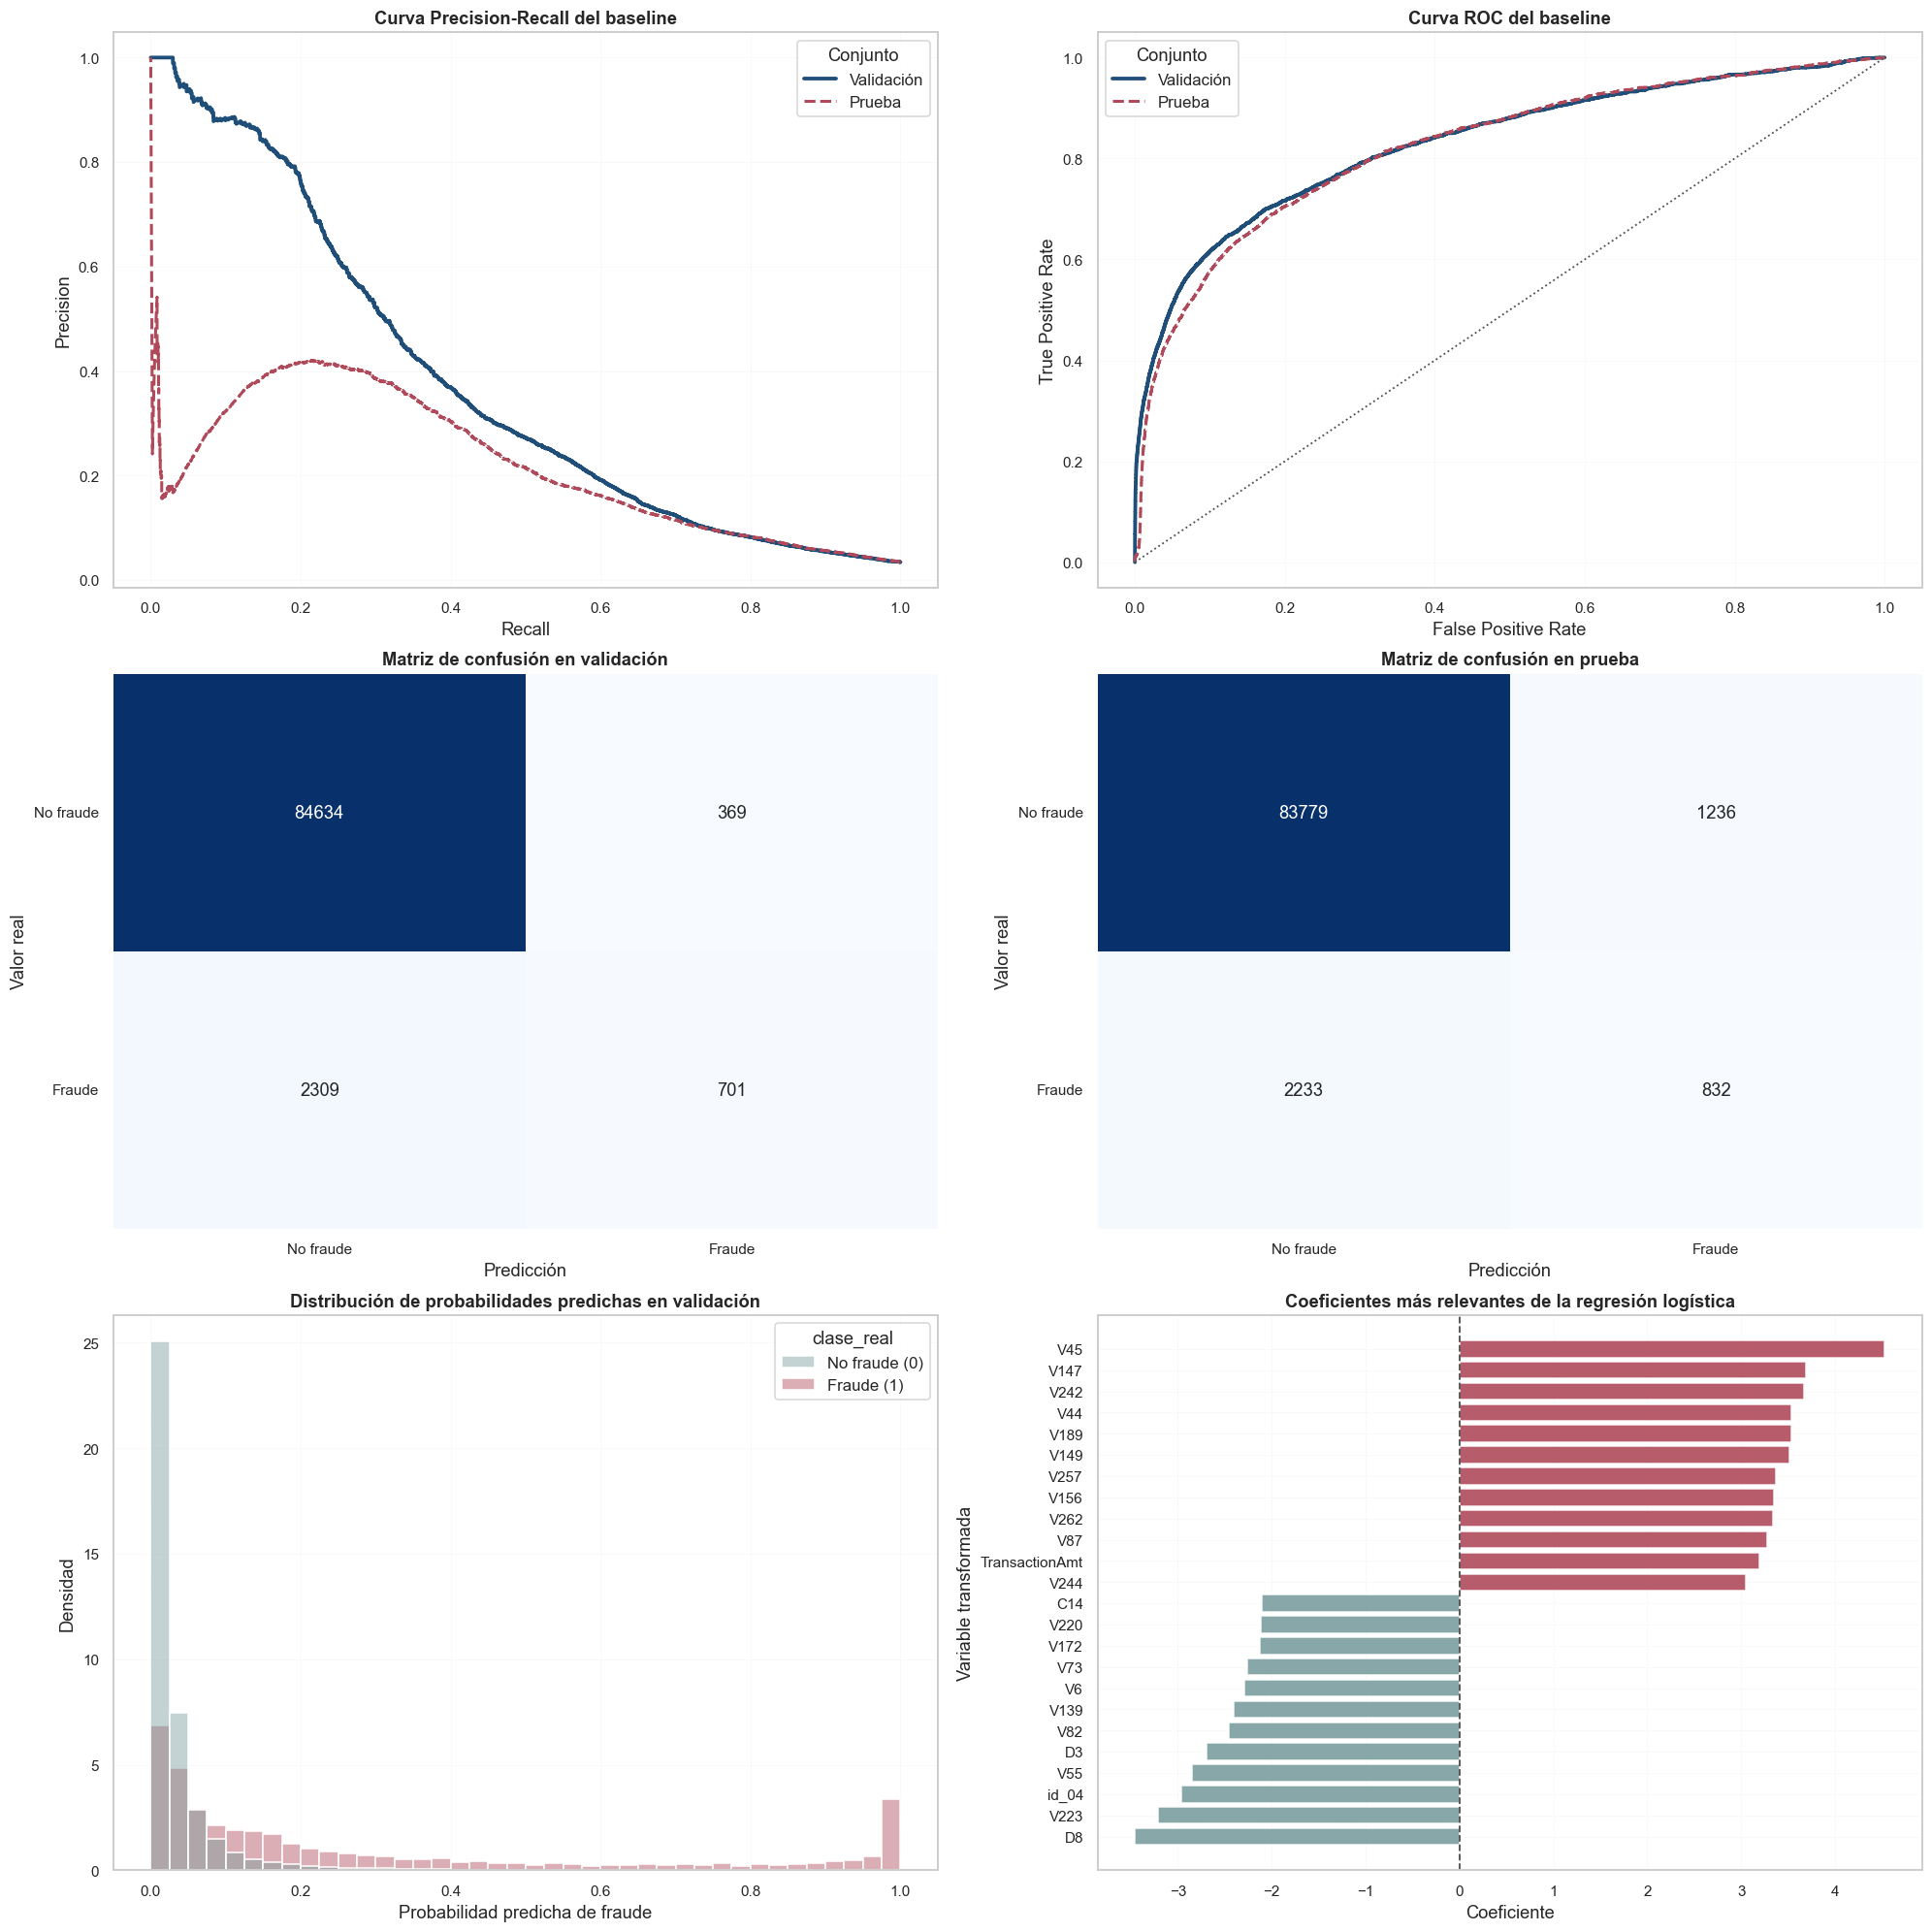

In [16]:
# Construcción de curvas Precision-Recall y ROC para validación y prueba del baseline principal.
validation_precision_curve, validation_recall_curve, _ = precision_recall_curve(y_validation, baseline_validation_score)
test_precision_curve, test_recall_curve, _ = precision_recall_curve(y_test, baseline_test_score)
validation_fpr, validation_tpr, _ = roc_curve(y_validation, baseline_validation_score)
test_fpr, test_tpr, _ = roc_curve(y_test, baseline_test_score)

# Preparación de probabilidades predichas por clase real para describir la separación lograda en validación.
validation_probability_frame = pd.DataFrame(
    {
        "probabilidad_predicha": baseline_validation_score,
        "clase_real": y_validation.map({0: "No fraude (0)", 1: "Fraude (1)"}).values,
    }
)

# Configuración del bloque gráfico principal del baseline interpretable.
fig, axes = plt.subplots(3, 2, figsize=(18, 18), constrained_layout=True)
axes = axes.flatten()

# Curva Precision-Recall con comparación explícita entre validación y prueba.
axes[0].plot(validation_recall_curve, validation_precision_curve, color="#1f4e79", linewidth=2.5, label="Validación")
axes[0].plot(test_recall_curve, test_precision_curve, color="#b04a5a", linewidth=2.0, linestyle="--", label="Prueba")
axes[0].set_title("Curva Precision-Recall del baseline", fontweight="semibold")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend(title="Conjunto")

# Curva ROC con trazado separado para validación y prueba.
axes[1].plot(validation_fpr, validation_tpr, color="#1f4e79", linewidth=2.5, label="Validación")
axes[1].plot(test_fpr, test_tpr, color="#b04a5a", linewidth=2.0, linestyle="--", label="Prueba")
axes[1].plot([0, 1], [0, 1], color="#4f4f4f", linestyle=":", linewidth=1.2)
axes[1].set_title("Curva ROC del baseline", fontweight="semibold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(title="Conjunto")

# Matriz de confusión en validación.
sns.heatmap(
    validation_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[2],
)
axes[2].set_title("Matriz de confusión en validación", fontweight="semibold")
axes[2].set_xlabel("Predicción")
axes[2].set_ylabel("Valor real")
axes[2].set_xticklabels(["No fraude", "Fraude"])
axes[2].set_yticklabels(["No fraude", "Fraude"], rotation=0)

# Matriz de confusión en prueba.
sns.heatmap(
    test_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[3],
)
axes[3].set_title("Matriz de confusión en prueba", fontweight="semibold")
axes[3].set_xlabel("Predicción")
axes[3].set_ylabel("Valor real")
axes[3].set_xticklabels(["No fraude", "Fraude"])
axes[3].set_yticklabels(["No fraude", "Fraude"], rotation=0)

# Distribución de probabilidades predichas según la clase real en validación.
sns.histplot(
    data=validation_probability_frame,
    x="probabilidad_predicha",
    hue="clase_real",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    palette=["#7a9e9f", "#b04a5a"],
    ax=axes[4],
)
axes[4].set_title("Distribución de probabilidades predichas en validación", fontweight="semibold")
axes[4].set_xlabel("Probabilidad predicha de fraude")
axes[4].set_ylabel("Densidad")

# Visualización de coeficientes más influyentes en sentido positivo y negativo.
coefficient_colors = ["#b04a5a" if value > 0 else "#7a9e9f" for value in top_coefficients["coeficiente"]]
axes[5].barh(top_coefficients["variable"], top_coefficients["coeficiente"], color=coefficient_colors, alpha=0.90)
axes[5].axvline(0, color="#4f4f4f", linestyle="--", linewidth=1.2)
axes[5].set_title("Coeficientes más relevantes de la regresión logística", fontweight="semibold")
axes[5].set_xlabel("Coeficiente")
axes[5].set_ylabel("Variable transformada")

# Ajustes comunes de estilo para mantener coherencia visual.
for axis in axes:
    axis.grid(alpha=0.20, linestyle="--", linewidth=0.5)
    axis.tick_params(labelsize=10)

plt.show()


### 11.1 Lectura de resultados

La regresión logística supera con claridad al `DummyClassifier`, lo que confirma que el baseline sí extrae señal útil del conjunto de variables transformadas. Frente a una referencia que solo reproduce la proporción base de fraude, el modelo lineal aporta capacidad real de discriminación.

La ROC-AUC en validación y prueba indica una capacidad razonable para ordenar transacciones de menor y mayor riesgo. Sin embargo, la PR-AUC y el recall muestran que la detección de fraude sigue siendo limitada, especialmente porque una parte importante de los casos positivos no es recuperada con el umbral estándar.

La caída de PR-AUC entre validación y prueba debe leerse como una advertencia metodológica breve: la señal asociada con la clase fraude es menos estable cuando cambia el tramo temporal evaluado. En este contexto, la exactitud no debe considerarse la métrica principal, ya que el desbalance puede inflarla sin reflejar bien la detección efectiva de fraude.

### 11.2 Lectura de gráficos del baseline logístico

La **curva Precision-Recall** muestra el equilibrio entre precisión y recall para distintos umbrales. Su lectura principal es que el baseline identifica señal útil, aunque la recuperación de fraude sigue siendo exigente en términos de falsos positivos.

La **curva ROC** resume la capacidad de discriminación global entre clases. El resultado sugiere un ordenamiento razonable del riesgo, pero esta visualización puede ser más optimista que la PR-AUC en un problema desbalanceado.

Las **matrices de confusión** muestran muchos verdaderos negativos y una cantidad todavía limitada de verdaderos positivos. El hallazgo central es que el modelo detecta parte del fraude, pero mantiene una fracción relevante de falsos negativos.

La **distribución de probabilidades predichas por clase** permite ver el solapamiento entre fraude y no fraude. Se observa cierta separación, aunque no suficiente para evitar una superposición importante entre ambas clases.

Los **coeficientes del baseline** indican señales lineales relevantes en el espacio transformado y ayudan a ubicar variables con mayor peso relativo. No implican causalidad y deben leerse como asociaciones dentro de un modelo lineal regularizado.


### 11.3 Lectura crítica del baseline

Como referencia metodológica, el baseline resulta útil porque combina interpretabilidad con una capacidad de discriminación claramente superior a la del dummy. Su principal límite es que las métricas centradas en fraude, especialmente PR-AUC y recall, siguen mostrando una recuperación restringida de la clase positiva.

En conjunto, el comportamiento observado sugiere un modelo lineal informativo, pero todavía sensible al desbalance y a la complejidad estructural del problema. Esto lo mantiene como una línea base válida y técnicamente legible, sin sobredimensionar su alcance.


## 12. Modelo principal: LightGBM

LightGBM es un método de gradient boosting sobre árboles de decisión diseñado para datos tabulares de alta dimensionalidad. En este proyecto se utiliza porque puede capturar relaciones no lineales, umbrales locales e interacciones entre variables que un modelo lineal no representa con la misma flexibilidad.

La detección de fraude en datos transaccionales suele depender de relaciones no lineales, umbrales locales e interacciones entre variables numéricas y categóricas que un modelo lineal no siempre captura con suficiente flexibilidad. Por esa razón, resulta pertinente incorporar un modelo tabular avanzado que pueda explotar patrones más complejos sobre el mismo espacio transformado ya definido en la preparación reproducible de datos.

Para preservar la comparabilidad metodológica, el modelo principal utiliza exactamente la misma partición temporal y el mismo preprocesamiento empleados en el baseline interpretable. La comparación contra la regresión logística y contra el `DummyClassifier` permite evaluar con mayor rigor cuánto aporta una estructura no lineal en este problema.


In [17]:
# Importaciones específicas para el modelo principal avanzado basado en gradientes sobre tablas.
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

# Configuración conservadora de LightGBM: busca buen desempeño tabular sin introducir una búsqueda extensa de hiperparámetros.
# Se mantiene una tasa de aprendizaje moderada, regularización ligera y muestreo parcial para controlar complejidad.
lightgbm_parameters = {
    "objective": "binary",
    "n_estimators": 800,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_child_samples": 100,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "reg_alpha": 0.10,
    "reg_lambda": 1.00,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

# Instanciación del clasificador principal sobre el mismo espacio transformado usado en la regresión logística.
lightgbm_model = LGBMClassifier(**lightgbm_parameters)

# Entrenamiento de LightGBM con monitoreo en validación y early stopping para controlar el número efectivo de árboles.
lightgbm_model.fit(
    X_train_prepared,
    y_train,
    eval_set=[(X_validation_prepared, y_validation)],
    eval_metric="average_precision",
    callbacks=[
        early_stopping(stopping_rounds=50, verbose=False),
        log_evaluation(period=0),
    ],
)

# Recuperación de la iteración a utilizar en predicción, respetando el resultado del monitoreo en validación.
lightgbm_best_iteration = lightgbm_model.best_iteration_ or lightgbm_parameters["n_estimators"]

# Obtención de probabilidades mediante el booster interno para evitar advertencias irrelevantes del envoltorio scikit-learn.
lightgbm_validation_score = lightgbm_model.booster_.predict(
    X_validation_prepared,
    num_iteration=lightgbm_best_iteration,
)
lightgbm_test_score = lightgbm_model.booster_.predict(
    X_test_prepared,
    num_iteration=lightgbm_best_iteration,
)

# Conversión inicial a etiquetas con umbral 0.5; se conserva como referencia antes del análisis específico de umbral.
lightgbm_validation_pred = (lightgbm_validation_score >= 0.5).astype(int)
lightgbm_test_pred = (lightgbm_test_score >= 0.5).astype(int)

# Consolidación de métricas del modelo principal en validación y prueba.
lightgbm_metrics = pd.DataFrame(
    [
        compute_classification_metrics(y_validation, lightgbm_validation_pred, lightgbm_validation_score, "Validación", "LightGBM"),
        compute_classification_metrics(y_test, lightgbm_test_pred, lightgbm_test_score, "Prueba", "LightGBM"),
    ]
)

# Matrices de confusión y reportes de clasificación del modelo principal.
lightgbm_validation_confusion = confusion_matrix(y_validation, lightgbm_validation_pred)
lightgbm_test_confusion = confusion_matrix(y_test, lightgbm_test_pred)
lightgbm_validation_report = pd.DataFrame(
    classification_report(y_validation, lightgbm_validation_pred, output_dict=True, zero_division=0)
).T.reset_index().rename(columns={"index": "clase"})
lightgbm_test_report = pd.DataFrame(
    classification_report(y_test, lightgbm_test_pred, output_dict=True, zero_division=0)
).T.reset_index().rename(columns={"index": "clase"})

# Recuperación de nombres de variables transformadas para mantener trazabilidad en la interpretación del modelo.
lightgbm_feature_names = [
    feature_name.replace("numericas__", "").replace("categoricas__", "")
    for feature_name in prepared_feature_names
]

# Importancia por ganancia acumulada: describe relevancia predictiva dentro del ensamblado, no causalidad.
lightgbm_importance_frame = pd.DataFrame(
    {
        "variable": lightgbm_feature_names,
        "importancia_gain": lightgbm_model.booster_.feature_importance(importance_type="gain"),
    }
).sort_values("importancia_gain", ascending=False)
lightgbm_importance_frame = lightgbm_importance_frame.loc[lightgbm_importance_frame["importancia_gain"] > 0].copy()
lightgbm_importance_frame["importancia_relativa_pct"] = (
    lightgbm_importance_frame["importancia_gain"] / lightgbm_importance_frame["importancia_gain"].sum()
) * 100
top_lightgbm_features = lightgbm_importance_frame.head(15).sort_values("importancia_relativa_pct", ascending=True)

# Tabla comparativa con dummy, baseline lineal y modelo principal avanzado.
model_comparison_metrics = pd.concat([baseline_metrics, lightgbm_metrics], ignore_index=True)
model_comparison_display = model_comparison_metrics.copy()
for metric_name in ["PR-AUC", "ROC-AUC", "precision", "recall", "F1", "balanced_accuracy"]:
    model_comparison_display[metric_name] = model_comparison_display[metric_name].map(lambda value: f"{value:.4f}")

# Preparación de una matriz comparativa para visualización compacta de métricas entre modelos y conjuntos.
comparison_heatmap_frame = model_comparison_metrics.copy()
comparison_heatmap_frame["modelo_conjunto"] = (
    comparison_heatmap_frame["modelo"] + " | " + comparison_heatmap_frame["conjunto"]
)
comparison_heatmap_frame = comparison_heatmap_frame.set_index("modelo_conjunto")[
    ["PR-AUC", "ROC-AUC", "precision", "recall", "F1", "balanced_accuracy"]
]

# Resumen tabular de hiperparámetros y estado del ajuste para documentar la configuración adoptada.
lightgbm_configuration = pd.DataFrame(
    {
        "hiperparámetro": [
            "n_estimators",
            "learning_rate",
            "num_leaves",
            "min_child_samples",
            "subsample",
            "colsample_bytree",
            "reg_alpha",
            "reg_lambda",
            "eval_metric",
        ],
        "valor": [
            str(lightgbm_parameters["n_estimators"]),
            f"{lightgbm_parameters['learning_rate']:.2f}",
            str(lightgbm_parameters["num_leaves"]),
            str(lightgbm_parameters["min_child_samples"]),
            f"{lightgbm_parameters['subsample']:.2f}",
            f"{lightgbm_parameters['colsample_bytree']:.2f}",
            f"{lightgbm_parameters['reg_alpha']:.2f}",
            f"{lightgbm_parameters['reg_lambda']:.2f}",
            "average_precision",
        ],
    }
)
lightgbm_training_summary = pd.DataFrame(
    {
        "métrica": [
            "Iteraciones máximas configuradas",
            "Iteración utilizada en predicción",
            "Variables transformadas disponibles",
            "Variables con importancia distinta de cero",
        ],
        "valor": [
            format_integer(lightgbm_parameters["n_estimators"]),
            format_integer(lightgbm_best_iteration),
            format_integer(len(lightgbm_feature_names)),
            format_integer(int((lightgbm_importance_frame["importancia_gain"] > 0).sum())),
        ],
    }
)

# Función auxiliar para presentar reportes de clasificación con formato homogéneo y legible.
def format_classification_report_table(report_frame: pd.DataFrame) -> pd.DataFrame:
    """Formatea el classification report para visualización en notebook."""

    report_display = report_frame.copy()
    for metric_name in ["precision", "recall", "f1-score"]:
        if metric_name in report_display.columns:
            report_display[metric_name] = report_display[metric_name].map(
                lambda value: "" if pd.isna(value) else f"{value:.4f}"
            )
    if "support" in report_display.columns:
        report_display["support"] = report_display["support"].map(
            lambda value: "" if pd.isna(value) else format_integer(int(round(value)))
        )
    return report_display


lightgbm_validation_report_display = format_classification_report_table(lightgbm_validation_report)
lightgbm_test_report_display = format_classification_report_table(lightgbm_test_report)

print("Configuración del modelo principal LightGBM")
display(lightgbm_configuration.style.hide(axis="index"))
print("\nResumen del ajuste del modelo principal")
display(lightgbm_training_summary.style.hide(axis="index"))
print("\nComparación de métricas entre modelos")
display(model_comparison_display.style.hide(axis="index"))
print("\nClassification report en validación para LightGBM")
display(lightgbm_validation_report_display.style.hide(axis="index"))
print("\nClassification report en prueba para LightGBM")
display(lightgbm_test_report_display.style.hide(axis="index"))


Configuración del modelo principal LightGBM


hiperparámetro,valor
n_estimators,800
learning_rate,0.05
num_leaves,31
min_child_samples,100
subsample,0.80
colsample_bytree,0.80
reg_alpha,0.10
reg_lambda,1.00
eval_metric,average_precision



Resumen del ajuste del modelo principal


métrica,valor
Iteraciones máximas configuradas,800
Iteración utilizada en predicción,800
Variables transformadas disponibles,928
Variables con importancia distinta de cero,564



Comparación de métricas entre modelos


modelo,conjunto,PR-AUC,ROC-AUC,precision,recall,F1,balanced_accuracy
Dummy prior,Validación,0.0342,0.5000,0.0000,0.0000,0.0000,0.5000
Regresión logística,Validación,0.3758,0.8326,0.6551,0.2329,0.3436,0.6143
Dummy prior,Prueba,0.0348,0.5000,0.0000,0.0000,0.0000,0.5000
Regresión logística,Prueba,0.2181,0.8249,0.4023,0.2715,0.3242,0.6285
LightGBM,Validación,0.5960,0.9235,0.8299,0.3874,0.5282,0.6923
LightGBM,Prueba,0.5440,0.9049,0.8058,0.3615,0.4991,0.6792



Classification report en validación para LightGBM


clase,precision,recall,f1-score,support
0,0.9787,0.9972,0.9879,"85,003"
1,0.8299,0.3874,0.5282,"3,010"
accuracy,0.9763,0.9763,0.9763,1
macro avg,0.9043,0.6923,0.7580,"88,013"
weighted avg,0.9736,0.9763,0.9721,"88,013"



Classification report en prueba para LightGBM


clase,precision,recall,f1-score,support
0,0.9774,0.9969,0.9870,"85,015"
1,0.8058,0.3615,0.4991,"3,065"
accuracy,0.9748,0.9748,0.9748,1
macro avg,0.8916,0.6792,0.7431,"88,080"
weighted avg,0.9715,0.9748,0.9701,"88,080"


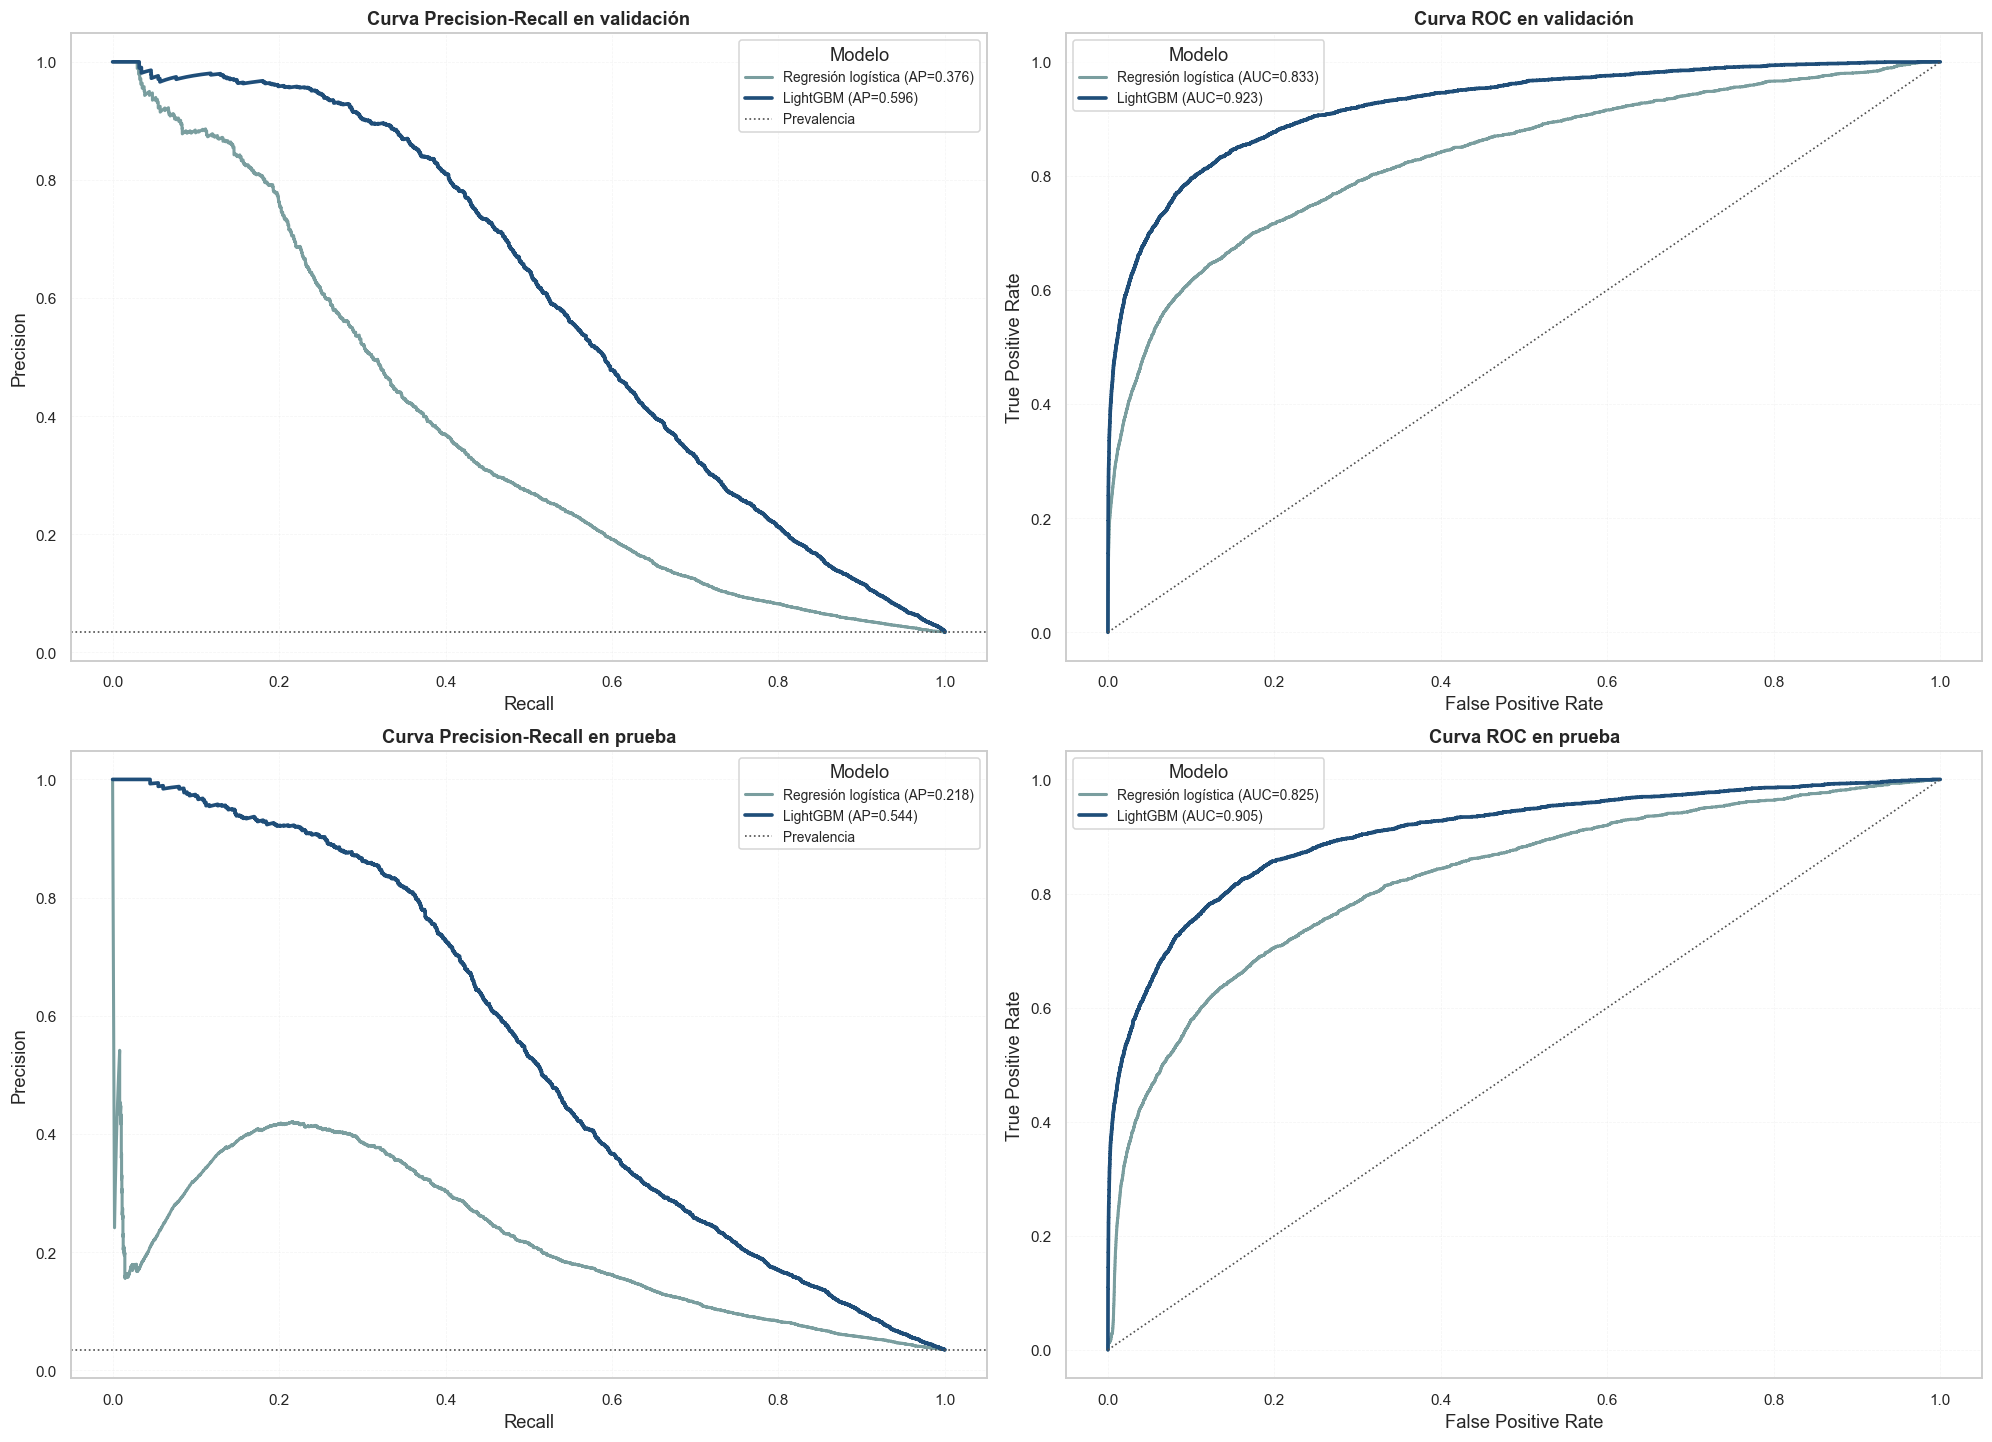

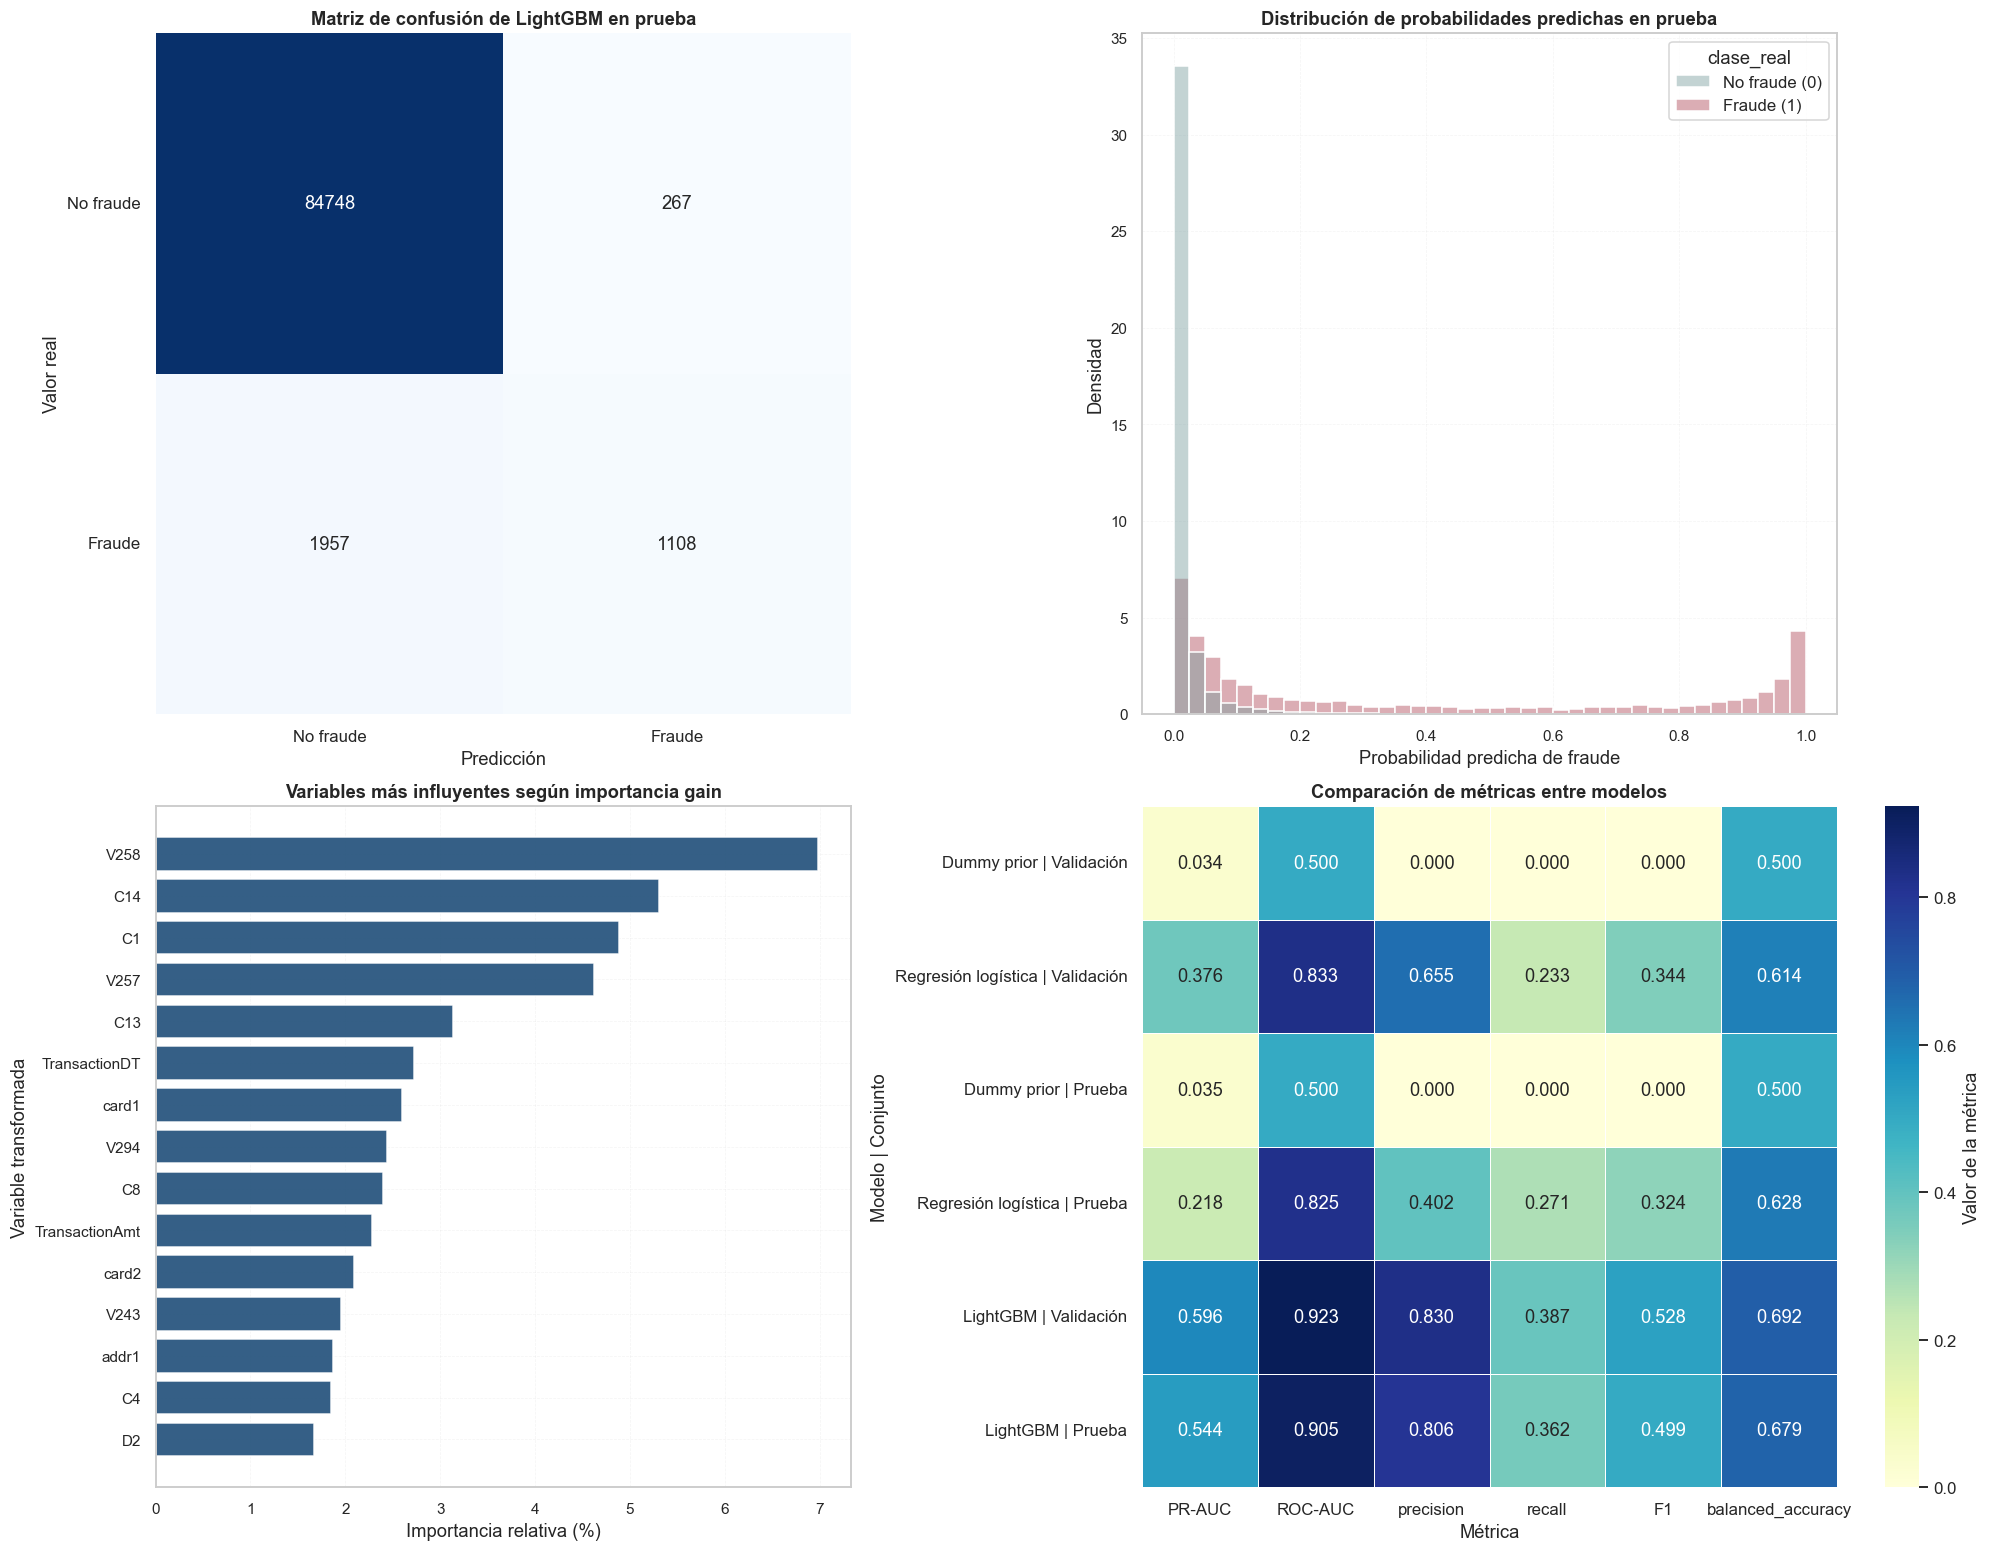

In [18]:
# Construcción de curvas comparativas entre la regresión logística y el modelo principal en validación y prueba.
lightgbm_validation_precision_curve, lightgbm_validation_recall_curve, _ = precision_recall_curve(
    y_validation,
    lightgbm_validation_score,
)
lightgbm_test_precision_curve, lightgbm_test_recall_curve, _ = precision_recall_curve(
    y_test,
    lightgbm_test_score,
)
lightgbm_validation_fpr, lightgbm_validation_tpr, _ = roc_curve(y_validation, lightgbm_validation_score)
lightgbm_test_fpr, lightgbm_test_tpr, _ = roc_curve(y_test, lightgbm_test_score)

# Construcción de una tabla auxiliar para describir probabilidades predichas por clase real en prueba.
lightgbm_test_probability_frame = pd.DataFrame(
    {
        "probabilidad_predicha": lightgbm_test_score,
        "clase_real": y_test.map({0: "No fraude (0)", 1: "Fraude (1)"}).values,
    }
)

# Primer bloque gráfico: comparación directa de curvas Precision-Recall y ROC entre baseline y modelo principal.
fig, axes = plt.subplots(2, 2, figsize=(18, 13), constrained_layout=True)
axes = axes.flatten()

axes[0].plot(
    validation_recall_curve,
    validation_precision_curve,
    color="#7a9e9f",
    linewidth=2.0,
    label=f"Regresión logística (AP={average_precision_score(y_validation, baseline_validation_score):.3f})",
)
axes[0].plot(
    lightgbm_validation_recall_curve,
    lightgbm_validation_precision_curve,
    color="#1f4e79",
    linewidth=2.4,
    label=f"LightGBM (AP={average_precision_score(y_validation, lightgbm_validation_score):.3f})",
)
axes[0].axhline(y=y_validation.mean(), color="#4f4f4f", linestyle=":", linewidth=1.1, label="Prevalencia")
axes[0].set_title("Curva Precision-Recall en validación", fontweight="semibold")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend(title="Modelo", fontsize=9)

axes[1].plot(
    validation_fpr,
    validation_tpr,
    color="#7a9e9f",
    linewidth=2.0,
    label=f"Regresión logística (AUC={roc_auc_score(y_validation, baseline_validation_score):.3f})",
)
axes[1].plot(
    lightgbm_validation_fpr,
    lightgbm_validation_tpr,
    color="#1f4e79",
    linewidth=2.4,
    label=f"LightGBM (AUC={roc_auc_score(y_validation, lightgbm_validation_score):.3f})",
)
axes[1].plot([0, 1], [0, 1], color="#4f4f4f", linestyle=":", linewidth=1.1)
axes[1].set_title("Curva ROC en validación", fontweight="semibold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(title="Modelo", fontsize=9)

axes[2].plot(
    test_recall_curve,
    test_precision_curve,
    color="#7a9e9f",
    linewidth=2.0,
    label=f"Regresión logística (AP={average_precision_score(y_test, baseline_test_score):.3f})",
)
axes[2].plot(
    lightgbm_test_recall_curve,
    lightgbm_test_precision_curve,
    color="#1f4e79",
    linewidth=2.4,
    label=f"LightGBM (AP={average_precision_score(y_test, lightgbm_test_score):.3f})",
)
axes[2].axhline(y=y_test.mean(), color="#4f4f4f", linestyle=":", linewidth=1.1, label="Prevalencia")
axes[2].set_title("Curva Precision-Recall en prueba", fontweight="semibold")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend(title="Modelo", fontsize=9)

axes[3].plot(
    test_fpr,
    test_tpr,
    color="#7a9e9f",
    linewidth=2.0,
    label=f"Regresión logística (AUC={roc_auc_score(y_test, baseline_test_score):.3f})",
)
axes[3].plot(
    lightgbm_test_fpr,
    lightgbm_test_tpr,
    color="#1f4e79",
    linewidth=2.4,
    label=f"LightGBM (AUC={roc_auc_score(y_test, lightgbm_test_score):.3f})",
)
axes[3].plot([0, 1], [0, 1], color="#4f4f4f", linestyle=":", linewidth=1.1)
axes[3].set_title("Curva ROC en prueba", fontweight="semibold")
axes[3].set_xlabel("False Positive Rate")
axes[3].set_ylabel("True Positive Rate")
axes[3].legend(title="Modelo", fontsize=9)

for axis in axes:
    axis.grid(alpha=0.20, linestyle="--", linewidth=0.5)
    axis.tick_params(labelsize=10)

plt.show()

# Segundo bloque gráfico: lectura operativa del modelo principal y comparación compacta de métricas entre modelos.
fig, axes = plt.subplots(2, 2, figsize=(18, 14), constrained_layout=True)

sns.heatmap(
    lightgbm_test_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Matriz de confusión de LightGBM en prueba", fontweight="semibold")
axes[0, 0].set_xlabel("Predicción")
axes[0, 0].set_ylabel("Valor real")
axes[0, 0].set_xticklabels(["No fraude", "Fraude"])
axes[0, 0].set_yticklabels(["No fraude", "Fraude"], rotation=0)

sns.histplot(
    data=lightgbm_test_probability_frame,
    x="probabilidad_predicha",
    hue="clase_real",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    palette=["#7a9e9f", "#b04a5a"],
    ax=axes[0, 1],
)
axes[0, 1].set_title("Distribución de probabilidades predichas en prueba", fontweight="semibold")
axes[0, 1].set_xlabel("Probabilidad predicha de fraude")
axes[0, 1].set_ylabel("Densidad")

axes[1, 0].barh(
    top_lightgbm_features["variable"],
    top_lightgbm_features["importancia_relativa_pct"],
    color="#1f4e79",
    alpha=0.90,
)
axes[1, 0].set_title("Variables más influyentes según importancia gain", fontweight="semibold")
axes[1, 0].set_xlabel("Importancia relativa (%)")
axes[1, 0].set_ylabel("Variable transformada")

sns.heatmap(
    comparison_heatmap_frame,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.4,
    cbar_kws={"label": "Valor de la métrica"},
    ax=axes[1, 1],
)
axes[1, 1].set_title("Comparación de métricas entre modelos", fontweight="semibold")
axes[1, 1].set_xlabel("Métrica")
axes[1, 1].set_ylabel("Modelo | Conjunto")

for axis in [axes[0, 1], axes[1, 0]]:
    axis.grid(alpha=0.20, linestyle="--", linewidth=0.5)
    axis.tick_params(labelsize=10)

plt.show()


### 12.1 Interpretación de resultados de LightGBM

LightGBM mejora de forma clara al baseline interpretable en validación y prueba. La PR-AUC pasa de `0.3758` a `0.5960` en validación y de `0.2181` a `0.5440` en prueba; la ROC-AUC sube de `0.8326` a `0.9235` y de `0.8249` a `0.9049`, respectivamente. Esta mejora indica una capacidad superior para ordenar observaciones por riesgo y para recuperar fraude en un problema fuertemente desbalanceado.

El avance no se limita al ranking global. El recall del fraude aumenta desde `0.2329` hasta `0.3874` en validación y desde `0.2715` hasta `0.3615` en prueba, mientras que la precisión también mejora frente a la regresión logística. Como resultado, F1 y la exactitud balanceada crecen de manera consistente, lo que sugiere un equilibrio más sólido entre detección de fraude y control de falsos positivos.

Los gráficos refuerzan esta lectura. Las curvas Precision-Recall y ROC sitúan a LightGBM por encima del baseline lineal en ambos conjuntos; la matriz de confusión en prueba muestra un aumento visible de verdaderos positivos; la distribución de probabilidades exhibe una separación más clara entre clases; y la importancia de variables indica que el modelo concentra parte de su señal en un subconjunto acotado del espacio transformado.

El principal trade-off es que el problema sigue siendo difícil incluso con un modelo más expresivo. Persiste una cantidad relevante de falsos negativos, la PR-AUC continúa bastante por debajo de la ROC-AUC y la importancia de variables debe leerse como relevancia predictiva dentro del ensamblado, no como causalidad.


### 12.2 Lectura crítica del modelo principal

Los hallazgos principales muestran que un modelo tabular no lineal captura mejor la estructura del problema que la regresión logística. La mejora es real en validación y se sostiene en prueba, especialmente en PR-AUC, recall, F1 y exactitud balanceada, lo que fortalece la solidez metodológica de la comparación.

Frente al baseline interpretable, LightGBM aporta una recuperación más amplia del fraude y una mejor capacidad de ranking, sin perder precisión relativa. Esa ganancia es particularmente valiosa porque el objetivo analítico del proyecto no es solo ordenar riesgo, sino distinguir con mayor claridad la clase positiva dentro de un contexto severamente desbalanceado.

Las limitaciones que permanecen también son relevantes. El modelo todavía deja escapar una fracción importante de transacciones fraudulentas, la lectura de importancias no sustituye un análisis fino de explicabilidad y la dependencia del umbral estándar sigue condicionando parte de las métricas discretas. Aun con esas reservas, LightGBM queda justificado como modelo principal del proyecto por su mejora consistente frente a la línea base.


## 13. Explicabilidad, calibración y análisis de umbral en LightGBM

Las métricas globales resumen desempeño, pero no agotan la comprensión de un modelo de fraude. En un problema desbalanceado y sensible al costo de error, también es necesario examinar qué variables sostienen las predicciones, cuán confiables son las probabilidades estimadas y cómo cambia la decisión cuando se modifica el umbral de clasificación.

Este bloque complementa la evaluación del modelo principal desde tres perspectivas: explicabilidad con SHAP, calibración de probabilidades y análisis del umbral. En conjunto, estas herramientas permiten pasar de la sola comparación de desempeño a una lectura más fina del comportamiento interno y operativo de LightGBM.


### 13.1 Explicabilidad global y local con SHAP

SHAP es una herramienta de explicabilidad basada en valores aditivos que cuantifica cuánto aporta cada variable a la salida del modelo. En este proyecto se utiliza para complementar el desempeño predictivo con una lectura global y local de las señales que sostienen las decisiones de LightGBM.

Se utiliza SHAP para descomponer la contribución de las variables sobre la salida del modelo. Para mantener el costo computacional en un rango razonable y preservar legibilidad, el análisis global se calcula sobre una muestra estratificada del conjunto de prueba, conservando observaciones de fraude y no fraude.


Variables con mayor impacto global según SHAP


variable,mean_abs_shap,importancia_relativa_pct
TransactionAmt,0.2733,4.67%
C13,0.2407,4.12%
TransactionDT,0.2053,3.51%
C14,0.1923,3.29%
C1,0.1714,2.93%
card2,0.1202,2.05%
V70,0.1198,2.05%
card1,0.1169,2.00%
C5,0.1008,1.72%
card6_credit,0.0984,1.68%



Casos locales seleccionados para explicación puntual


caso,TransactionID,TransactionDT,clase_real,Predicción con umbral 0.5,probabilidad
Fraude correctamente detectado,"3,556,658","15,110,762",Fraude (1),Fraude (1),0.9998
No fraude con score alto,"3,569,645","15,557,752",No fraude (0),Fraude (1),0.9956
Fraude subestimado cerca del umbral,"3,534,397","14,441,429",Fraude (1),No fraude (0),0.4995


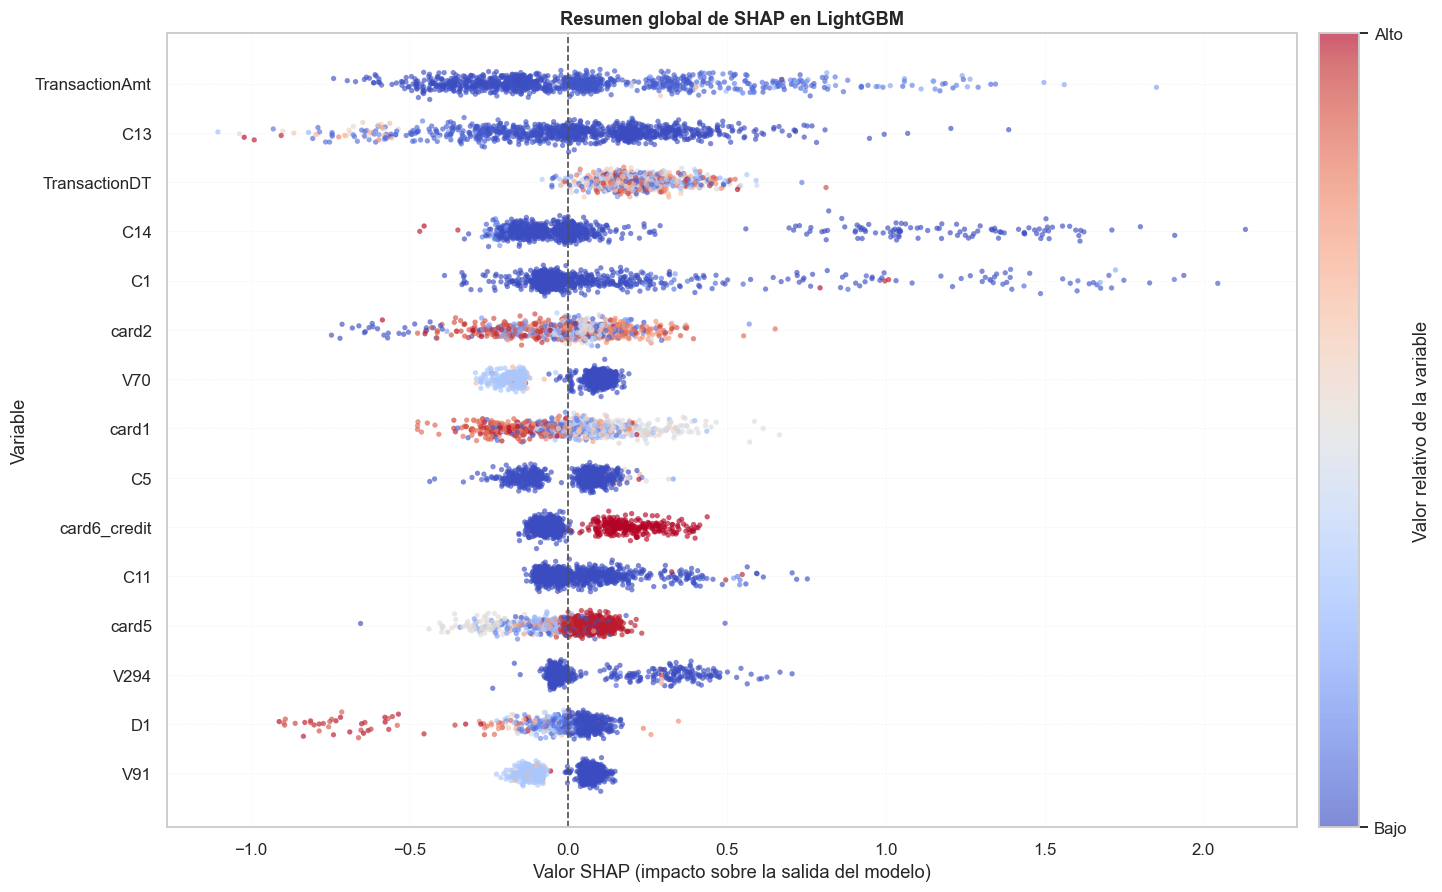

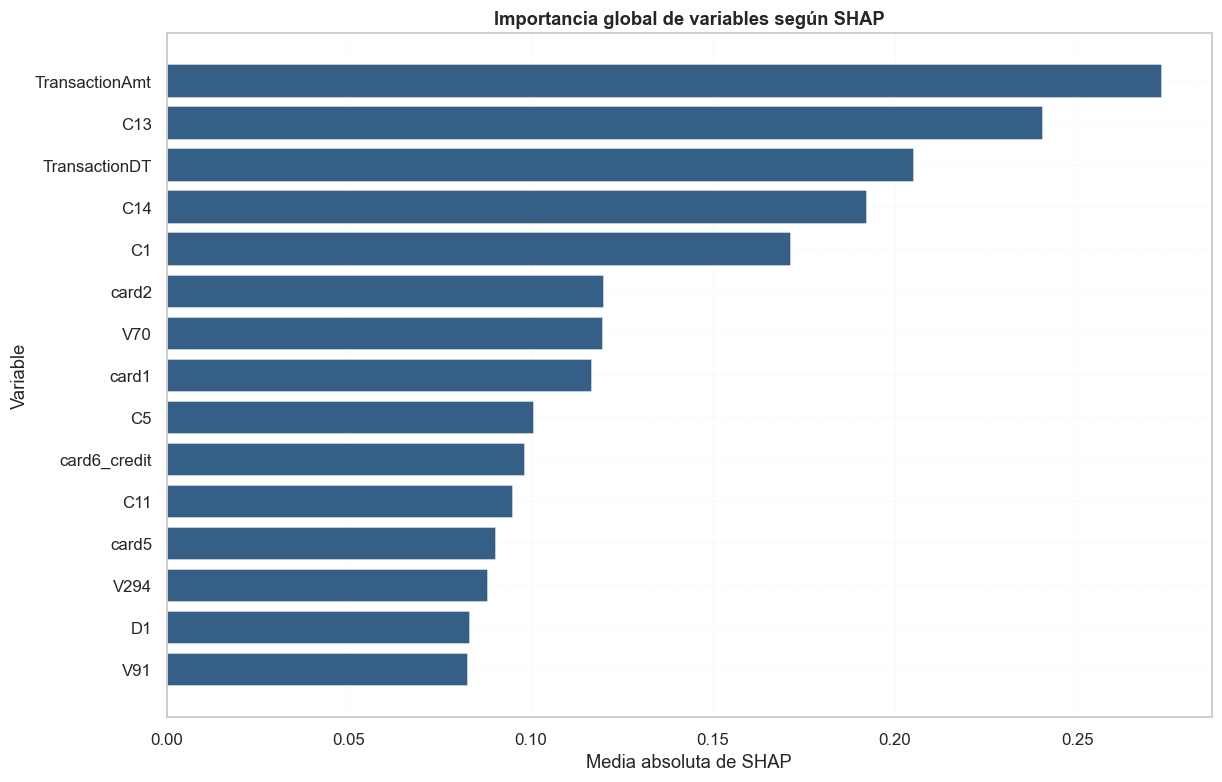

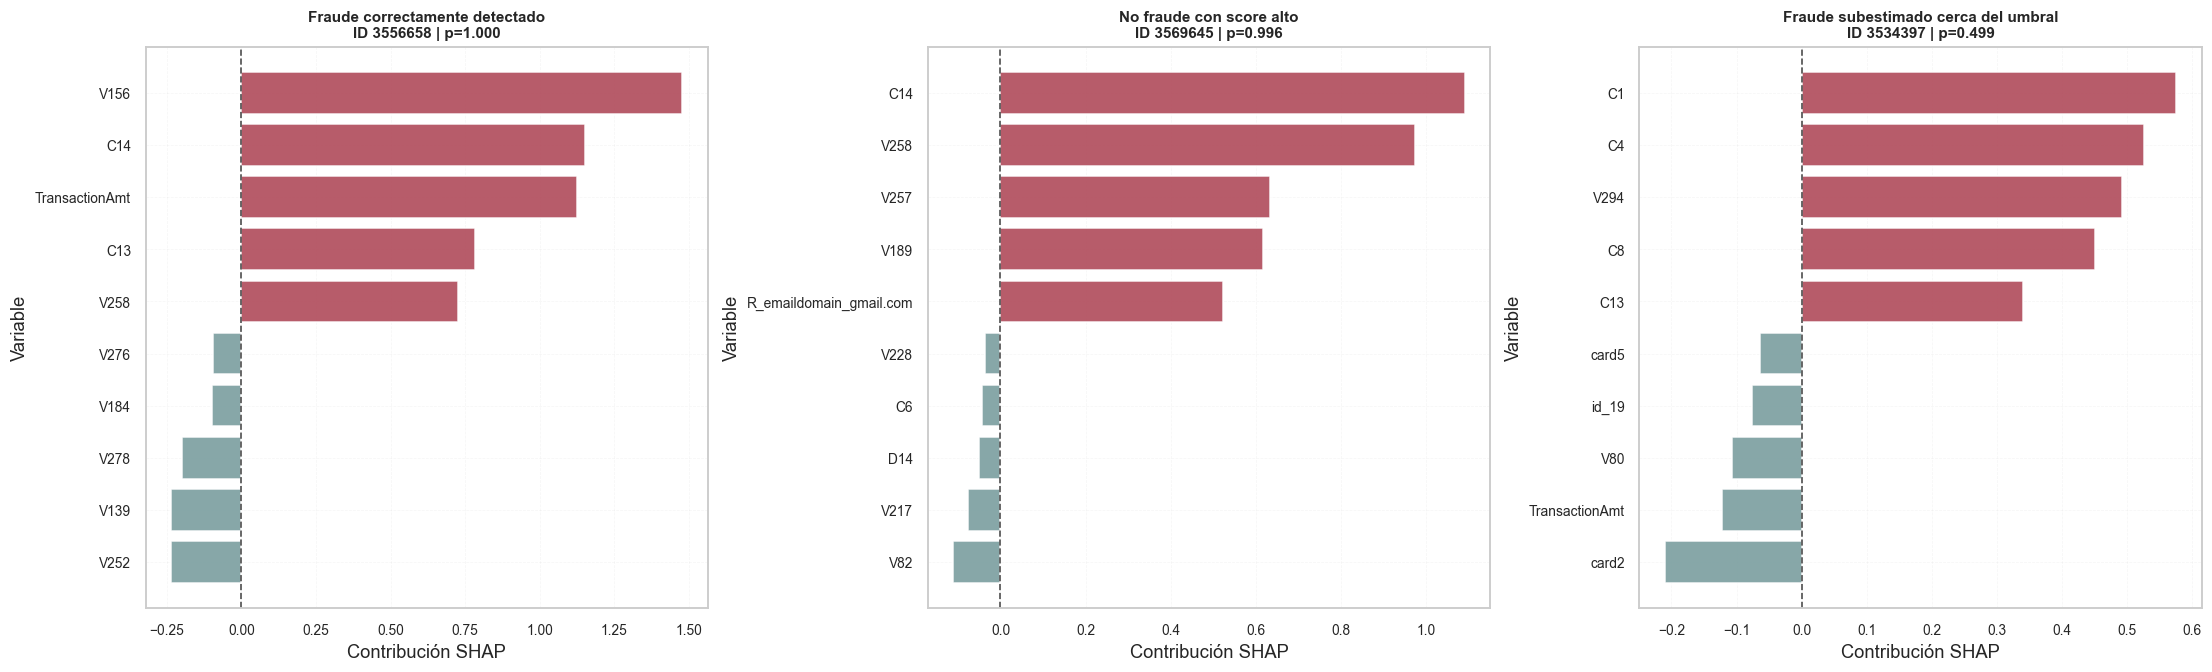

In [19]:
# Importaciones específicas para explicabilidad, calibración y evaluación probabilística.
import shap
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss

# Muestra estratificada para SHAP: conserva casos de fraude y no fraude sin calcular explicaciones sobre todo el conjunto.
# Se limita el tamaño para equilibrar costo computacional, representación de fraude y legibilidad gráfica.
shap_positive_n = min(250, int((y_test == 1).sum()))
shap_negative_n = min(750, int((y_test == 0).sum()))
shap_positive_index = y_test[y_test == 1].sample(n=shap_positive_n, random_state=42).index
shap_negative_index = y_test[y_test == 0].sample(n=shap_negative_n, random_state=42).index
shap_sample_index = pd.Index(list(shap_negative_index) + list(shap_positive_index))
shap_sample_positions = y_test.index.get_indexer(shap_sample_index)

# Recuperación de la matriz preparada para SHAP y conversión a formato denso por claridad visual.
X_test_shap_sample = X_test_prepared[shap_sample_positions]
if hasattr(X_test_shap_sample, "toarray"):
    X_test_shap_sample = X_test_shap_sample.toarray()
X_test_shap_sample_df = pd.DataFrame(
    X_test_shap_sample,
    columns=lightgbm_feature_names,
    index=shap_sample_index,
)

# Inicialización del explicador SHAP sobre el LightGBM ya entrenado; no se modifica el modelo.
lightgbm_shap_explainer = shap.TreeExplainer(lightgbm_model)
lightgbm_shap_sample = lightgbm_shap_explainer(X_test_shap_sample_df)

# Función auxiliar para normalizar valores y usarlos como escala de color en el gráfico resumen.
def normalize_feature_values(values: pd.Series) -> np.ndarray:
    """Escala valores de una variable al intervalo [0, 1] para fines gráficos."""

    numeric_values = pd.to_numeric(values, errors="coerce")
    finite_values = numeric_values.replace([np.inf, -np.inf], np.nan)
    min_value = finite_values.min(skipna=True)
    max_value = finite_values.max(skipna=True)
    if pd.isna(min_value) or pd.isna(max_value) or max_value == min_value:
        return np.full(len(values), 0.5)
    normalized = (finite_values.fillna(min_value) - min_value) / (max_value - min_value)
    return normalized.clip(0, 1).to_numpy()


# Cálculo de importancia global mediante el valor absoluto medio de SHAP.
shap_global_importance = pd.DataFrame(
    {
        "variable": lightgbm_feature_names,
        "mean_abs_shap": np.abs(lightgbm_shap_sample.values).mean(axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)
shap_global_importance["importancia_relativa_pct"] = (
    shap_global_importance["mean_abs_shap"] / shap_global_importance["mean_abs_shap"].sum()
) * 100
top_shap_features = shap_global_importance.head(15).copy()
top_shap_features_display = top_shap_features.copy()
top_shap_features_display["mean_abs_shap"] = top_shap_features_display["mean_abs_shap"].map(lambda value: f"{value:.4f}")
top_shap_features_display["importancia_relativa_pct"] = top_shap_features_display["importancia_relativa_pct"].map(
    format_percentage
)

# Selección de casos locales representativos para explicación puntual.
lightgbm_test_case_frame = split_frames["Prueba"][["TransactionID", "TransactionDT", target_column]].copy()
lightgbm_test_case_frame["probabilidad_lightgbm"] = lightgbm_test_score
lightgbm_test_case_frame["prediccion_umbral_05"] = lightgbm_test_pred

local_case_specs = [
    ("Fraude correctamente detectado", (lightgbm_test_case_frame[target_column] == 1) & (lightgbm_test_case_frame["prediccion_umbral_05"] == 1)),
    ("No fraude con score alto", (lightgbm_test_case_frame[target_column] == 0) & (lightgbm_test_case_frame["prediccion_umbral_05"] == 1)),
    ("Fraude subestimado cerca del umbral", (lightgbm_test_case_frame[target_column] == 1) & (lightgbm_test_case_frame["prediccion_umbral_05"] == 0)),
]

local_case_rows = []
local_case_plots = []
for case_name, case_mask in local_case_specs:
    selected_case = lightgbm_test_case_frame.loc[case_mask].sort_values(
        "probabilidad_lightgbm",
        ascending=False,
    ).head(1)
    if selected_case.empty:
        continue

    selected_index = selected_case.index[0]
    selected_position = y_test.index.get_indexer([selected_index])[0]
    X_local_case = X_test_prepared[selected_position]
    if hasattr(X_local_case, "toarray"):
        X_local_case = X_local_case.toarray()
    X_local_case_df = pd.DataFrame(
        X_local_case,
        columns=lightgbm_feature_names,
        index=[selected_index],
    )
    local_shap_explanation = lightgbm_shap_explainer(X_local_case_df)

    local_contributions = pd.DataFrame(
        {
            "variable": lightgbm_feature_names,
            "shap_value": local_shap_explanation.values[0],
        }
    )
    top_positive_local = local_contributions.sort_values("shap_value", ascending=False).head(5)
    top_negative_local = local_contributions.sort_values("shap_value", ascending=True).head(5)
    local_plot_frame = pd.concat([top_positive_local, top_negative_local], ignore_index=True).sort_values(
        "shap_value",
        ascending=True,
    )

    local_case_plots.append(
        {
            "nombre_caso": case_name,
            "transaction_id": int(selected_case["TransactionID"].iloc[0]),
            "plot_frame": local_plot_frame,
            "probabilidad": float(selected_case["probabilidad_lightgbm"].iloc[0]),
            "clase_real": int(selected_case[target_column].iloc[0]),
            "prediccion": int(selected_case["prediccion_umbral_05"].iloc[0]),
        }
    )
    local_case_rows.append(
        {
            "caso": case_name,
            "TransactionID": format_integer(int(selected_case["TransactionID"].iloc[0])),
            "TransactionDT": format_integer(int(selected_case["TransactionDT"].iloc[0])),
            "clase_real": "Fraude (1)" if int(selected_case[target_column].iloc[0]) == 1 else "No fraude (0)",
            "Predicción con umbral 0.5": "Fraude (1)" if int(selected_case["prediccion_umbral_05"].iloc[0]) == 1 else "No fraude (0)",
            "probabilidad": f"{float(selected_case['probabilidad_lightgbm'].iloc[0]):.4f}",
        }
    )

local_case_summary = pd.DataFrame(local_case_rows)

print("Variables con mayor impacto global según SHAP")
display(top_shap_features_display.style.hide(axis="index"))
print("\nCasos locales seleccionados para explicación puntual")
display(local_case_summary.style.hide(axis="index"))

# Gráfico resumen global con dispersión de contribuciones SHAP por variable.
summary_feature_order = top_shap_features["variable"].tolist()[::-1]
fig, ax = plt.subplots(figsize=(13, 8), constrained_layout=True)
rng = np.random.default_rng(42)
last_scatter = None
for row_position, feature_name in enumerate(summary_feature_order):
    feature_values = X_test_shap_sample_df[feature_name]
    feature_colors = normalize_feature_values(feature_values)
    shap_column_values = lightgbm_shap_sample.values[:, lightgbm_feature_names.index(feature_name)]
    jitter = rng.normal(loc=0.0, scale=0.10, size=len(shap_column_values))
    last_scatter = ax.scatter(
        shap_column_values,
        np.full(len(shap_column_values), row_position) + jitter,
        c=feature_colors,
        cmap="coolwarm",
        s=12,
        alpha=0.65,
        edgecolors="none",
    )

ax.axvline(0, color="#4f4f4f", linestyle="--", linewidth=1.1)
ax.set_title("Resumen global de SHAP en LightGBM", fontweight="semibold")
ax.set_xlabel("Valor SHAP (impacto sobre la salida del modelo)")
ax.set_ylabel("Variable")
ax.set_yticks(range(len(summary_feature_order)))
ax.set_yticklabels(summary_feature_order)
ax.grid(alpha=0.18, linestyle="--", linewidth=0.5)
colorbar = fig.colorbar(last_scatter, ax=ax, pad=0.02)
colorbar.set_label("Valor relativo de la variable")
colorbar.set_ticks([0, 1])
colorbar.set_ticklabels(["Bajo", "Alto"])
plt.show()

# Gráfico de barras con importancia global agregada mediante media absoluta de SHAP.
fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)
ax.barh(
    top_shap_features["variable"][::-1],
    top_shap_features["mean_abs_shap"][::-1],
    color="#1f4e79",
    alpha=0.90,
)
ax.set_title("Importancia global de variables según SHAP", fontweight="semibold")
ax.set_xlabel("Media absoluta de SHAP")
ax.set_ylabel("Variable")
ax.grid(alpha=0.18, linestyle="--", linewidth=0.5)
plt.show()

# Visualizaciones locales con las contribuciones SHAP más relevantes en tres casos representativos.
fig, axes = plt.subplots(1, len(local_case_plots), figsize=(20, 6), constrained_layout=True)
if len(local_case_plots) == 1:
    axes = [axes]

for axis, case_info in zip(axes, local_case_plots):
    contribution_colors = ["#b04a5a" if value > 0 else "#7a9e9f" for value in case_info["plot_frame"]["shap_value"]]
    axis.barh(
        case_info["plot_frame"]["variable"],
        case_info["plot_frame"]["shap_value"],
        color=contribution_colors,
        alpha=0.90,
    )
    axis.axvline(0, color="#4f4f4f", linestyle="--", linewidth=1.1)
    axis.set_title(
        f"{case_info['nombre_caso']}\nID {case_info['transaction_id']} | p={case_info['probabilidad']:.3f}",
        fontweight="semibold",
        fontsize=10,
    )
    axis.set_xlabel("Contribución SHAP")
    axis.set_ylabel("Variable")
    axis.grid(alpha=0.18, linestyle="--", linewidth=0.5)
    axis.tick_params(labelsize=9)

plt.show()


La lectura global de SHAP muestra que variables como `TransactionAmt`, `C13`, `TransactionDT`, `C14` y `C1` concentran una fracción importante de la explicación del modelo. Esto sugiere que LightGBM no solo aprovecha montos transaccionales, sino también señales temporales y agregados derivados del comportamiento de la operación.

En los casos locales se observa con claridad que una predicción surge de la combinación de empujes positivos y negativos sobre el riesgo estimado. Cuando una variable aporta un valor SHAP positivo, desplaza la salida del modelo hacia mayor riesgo; cuando el aporte es negativo, la desplaza hacia menor riesgo. Esa lectura ayuda a entender por qué un caso puede ser clasificado como fraude, confundido con fraude o quedar subestimado cerca del umbral.

SHAP mejora la interpretabilidad del modelo, pero no implica causalidad. Las contribuciones identifican asociaciones predictivas dentro del espacio transformado y del ensamblado de árboles, no mecanismos causales del fenómeno fraudulento.


### 13.2 Calibración de probabilidades

La calibración isotónica es una técnica no paramétrica que ajusta una transformación monótona entre los puntajes del modelo y la frecuencia observada del evento. En este proyecto se emplea para evaluar si las probabilidades de LightGBM representan el riesgo con suficiente fidelidad y si una corrección posterior mejora su confiabilidad.

Una probabilidad útil no solo debe ordenar correctamente las observaciones; también debe reflejar con razonable fidelidad el riesgo observado. Por ello se contrasta la salida original de LightGBM contra una calibración isotónica ajustada sobre el conjunto de validación y evaluada en prueba, sin reentrenar el modelo principal.


Resumen de calibración de probabilidades en prueba


versión,PR-AUC en prueba,ROC-AUC en prueba,Puntaje de Brier,Pérdida logarítmica,Probabilidad media,Tasa de fraude observada
Original,0.5440,0.9049,0.0219,0.0903,0.0336,0.0348
Calibrado isotónico,0.5296,0.9043,0.0220,0.0909,0.0359,0.0348


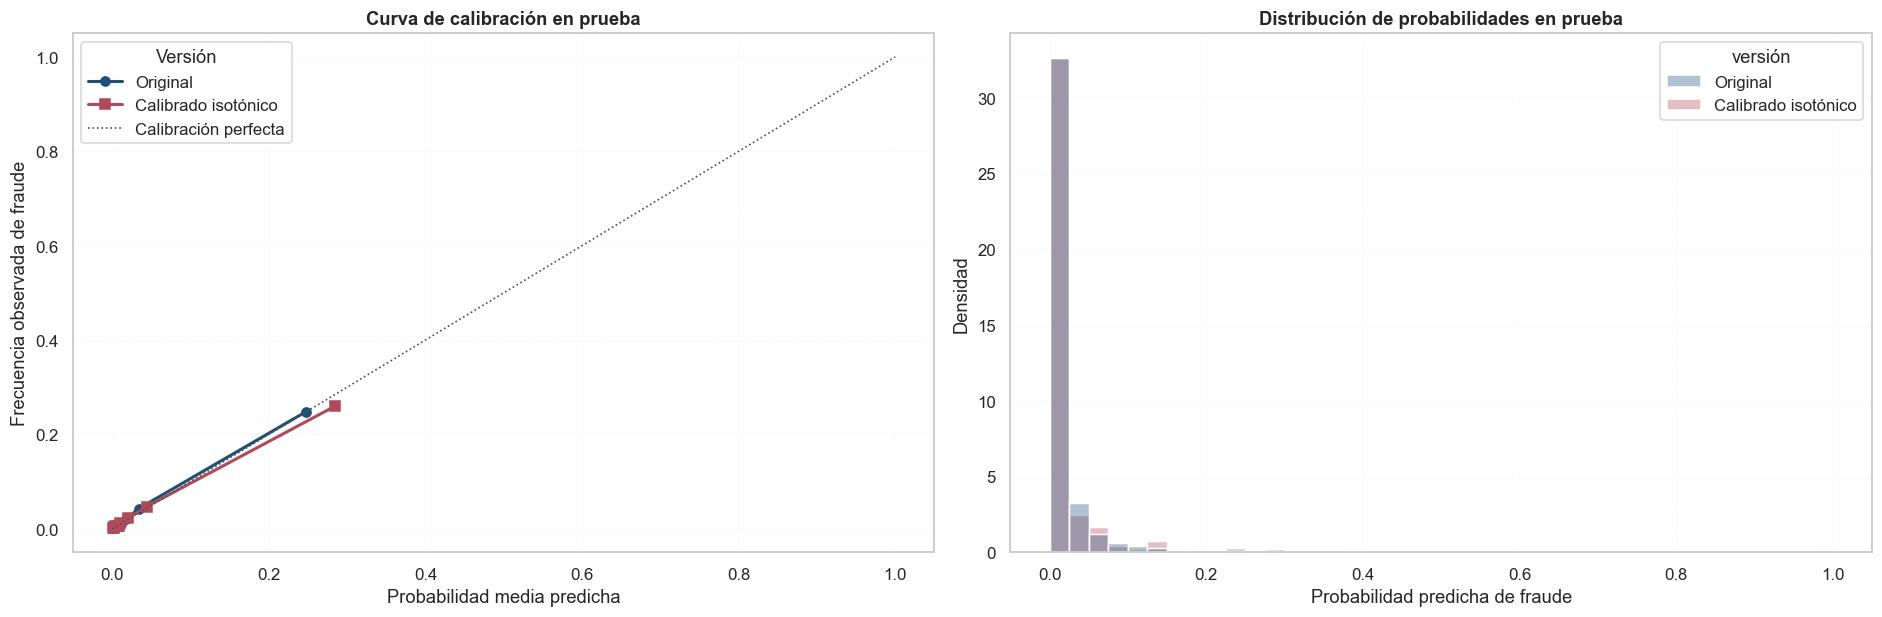

In [20]:
# Construcción de series indexadas para trabajar con probabilidades originales de LightGBM.
lightgbm_validation_score_series = pd.Series(
    lightgbm_validation_score,
    index=y_validation.index,
    name="probabilidad_original",
)
lightgbm_test_score_series = pd.Series(
    lightgbm_test_score,
    index=y_test.index,
    name="probabilidad_original",
)

# Calibración isotónica ajustada en validación para contrastar si el score se alinea mejor con la frecuencia observada.
lightgbm_isotonic_calibrator = IsotonicRegression(out_of_bounds="clip")
lightgbm_isotonic_calibrator.fit(lightgbm_validation_score_series, y_validation)

# Obtención de probabilidades calibradas en prueba para comparar confiabilidad contra la salida original.
lightgbm_test_score_calibrated = lightgbm_isotonic_calibrator.predict(lightgbm_test_score_series)

# Clipping suave para evitar problemas numéricos en log loss cuando aparecen probabilidades extremas.
lightgbm_test_score_clipped = np.clip(lightgbm_test_score_series, 1e-6, 1 - 1e-6)
lightgbm_test_score_calibrated_clipped = np.clip(lightgbm_test_score_calibrated, 1e-6, 1 - 1e-6)

# Resumen de calibración en prueba: compara confiabilidad probabilística sin cambiar el entrenamiento del modelo principal.
calibration_summary = pd.DataFrame(
    [
        {
            "versión": "Original",
            "PR-AUC en prueba": average_precision_score(y_test, lightgbm_test_score_series),
            "ROC-AUC en prueba": roc_auc_score(y_test, lightgbm_test_score_series),
            "Puntaje de Brier": brier_score_loss(y_test, lightgbm_test_score_series),
            "Pérdida logarítmica": log_loss(y_test, lightgbm_test_score_clipped, labels=[0, 1]),
            "Probabilidad media": float(np.mean(lightgbm_test_score_series)),
            "Tasa de fraude observada": float(y_test.mean()),
        },
        {
            "versión": "Calibrado isotónico",
            "PR-AUC en prueba": average_precision_score(y_test, lightgbm_test_score_calibrated),
            "ROC-AUC en prueba": roc_auc_score(y_test, lightgbm_test_score_calibrated),
            "Puntaje de Brier": brier_score_loss(y_test, lightgbm_test_score_calibrated),
            "Pérdida logarítmica": log_loss(y_test, lightgbm_test_score_calibrated_clipped, labels=[0, 1]),
            "Probabilidad media": float(np.mean(lightgbm_test_score_calibrated)),
            "Tasa de fraude observada": float(y_test.mean()),
        },
    ]
)
calibration_summary_display = calibration_summary.copy()
for metric_name in [
    "PR-AUC en prueba",
    "ROC-AUC en prueba",
    "Puntaje de Brier",
    "Pérdida logarítmica",
    "Probabilidad media",
    "Tasa de fraude observada",
]:
    calibration_summary_display[metric_name] = calibration_summary_display[metric_name].map(lambda value: f"{value:.4f}")

# Construcción de curvas de calibración en prueba usando bins por cuantiles para conservar observaciones en cada tramo.
raw_fraction_positives, raw_mean_predicted = calibration_curve(
    y_test,
    lightgbm_test_score_series,
    n_bins=10,
    strategy="quantile",
)
calibrated_fraction_positives, calibrated_mean_predicted = calibration_curve(
    y_test,
    lightgbm_test_score_calibrated,
    n_bins=10,
    strategy="quantile",
)

# Tabla auxiliar para describir la distribución de probabilidades antes y después de la calibración.
calibration_probability_frame = pd.concat(
    [
        pd.DataFrame(
            {
                "probabilidad": lightgbm_test_score_series,
                "versión": "Original",
            }
        ),
        pd.DataFrame(
            {
                "probabilidad": lightgbm_test_score_calibrated,
                "versión": "Calibrado isotónico",
            }
        ),
    ],
    ignore_index=True,
)

print("Resumen de calibración de probabilidades en prueba")
display(calibration_summary_display.style.hide(axis="index"))

# Visualización de la curva de calibración y del cambio en la distribución de probabilidades.
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), constrained_layout=True)

axes[0].plot(
    raw_mean_predicted,
    raw_fraction_positives,
    marker="o",
    linewidth=2.0,
    color="#1f4e79",
    label="Original",
)
axes[0].plot(
    calibrated_mean_predicted,
    calibrated_fraction_positives,
    marker="s",
    linewidth=2.0,
    color="#b04a5a",
    label="Calibrado isotónico",
)
axes[0].plot([0, 1], [0, 1], linestyle=":", color="#4f4f4f", linewidth=1.1, label="Calibración perfecta")
axes[0].set_title("Curva de calibración en prueba", fontweight="semibold")
axes[0].set_xlabel("Probabilidad media predicha")
axes[0].set_ylabel("Frecuencia observada de fraude")
axes[0].legend(title="Versión")
axes[0].grid(alpha=0.18, linestyle="--", linewidth=0.5)

sns.histplot(
    data=calibration_probability_frame,
    x="probabilidad",
    hue="versión",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.35,
    palette=["#1f4e79", "#b04a5a"],
    ax=axes[1],
)
axes[1].set_title("Distribución de probabilidades en prueba", fontweight="semibold")
axes[1].set_xlabel("Probabilidad predicha de fraude")
axes[1].set_ylabel("Densidad")
axes[1].grid(alpha=0.18, linestyle="--", linewidth=0.5)

plt.show()


La calibración muestra que las probabilidades originales de LightGBM ya presentan una alineación razonable en prueba. La versión isotónica acerca la probabilidad media al nivel observado de fraude, pero no mejora los indicadores resumidos de confiabilidad: `puntaje de Brier` y `pérdida logarítmica` empeoran ligeramente, y también se observa una reducción marginal en PR-AUC.

En este caso, la lectura técnica sugiere que el modelo no exhibe una descalibración severa bajo la salida original y que una corrección isotónica simple no añade valor claro bajo el esquema actual. La calibración, por tanto, resulta útil como diagnóstico de confiabilidad, aunque no modifica de forma favorable el comportamiento probabilístico en prueba.

Conviene mantener una interpretación prudente: la calibración se aprendió sobre el conjunto de validación ya reservado para monitoreo del modelo, por lo que el contraste más informativo es el observado en prueba. Bajo esa referencia, persiste una ligera discrepancia entre ranking fuerte y confiabilidad probabilística perfecta.


### 13.3 Análisis de umbral de decisión

El umbral define el intercambio entre precisión y recall. En fraude, asumir automáticamente `0.5` puede ser poco informativo, por lo que se examina cómo cambian las métricas al recorrer una malla de umbrales y se identifica un punto simple basado en la maximización de F1 sobre validación.


Umbrales representativos para LightGBM


Umbral,Precisión en validación,Recall en validación,F1 en validación,Precisión en prueba,Recall en prueba,F1 en prueba
0.100000,0.4247,0.6326,0.5082,0.3638,0.6039,0.4541
0.250000,0.6689,0.4880,0.5643,0.5980,0.4649,0.5231
0.500000,0.8299,0.3874,0.5282,0.8058,0.3615,0.4991
0.750000,0.9078,0.2977,0.4483,0.8792,0.2754,0.4194



Comparación operativa en prueba entre umbral estándar y umbral seleccionado


Criterio,Precisión en prueba,Recall en prueba,F1 en prueba
Umbral seleccionado por F1 (0.25),0.5980,0.4649,0.5231
Umbral estándar (0.50),0.8058,0.3615,0.4991


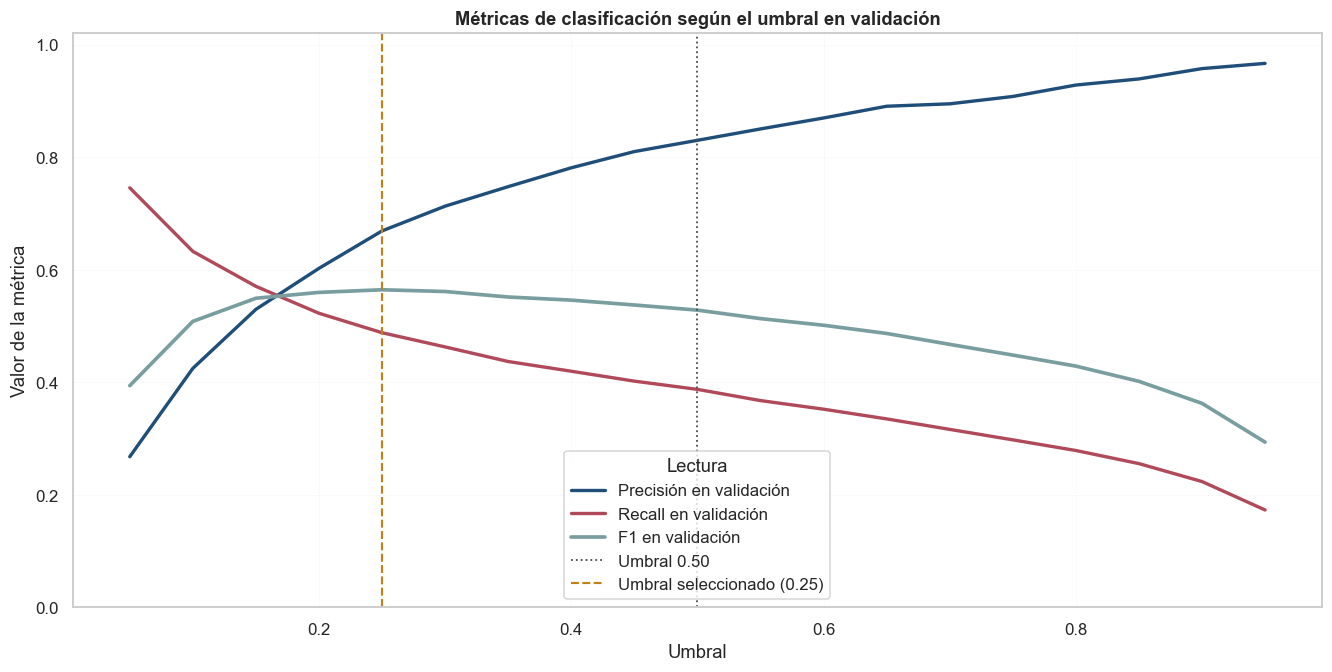

In [21]:
# Malla de umbrales: permite observar cómo cambian precisión, recall y F1 sin fijar automáticamente el corte en 0.5.
threshold_grid = np.round(np.arange(0.05, 0.951, 0.05), 2)
threshold_analysis_rows = []
for threshold_value in threshold_grid:
    validation_pred_threshold = (lightgbm_validation_score >= threshold_value).astype(int)
    test_pred_threshold = (lightgbm_test_score >= threshold_value).astype(int)
    threshold_analysis_rows.append(
        {
            "threshold": threshold_value,
            "precision_validación": precision_score(y_validation, validation_pred_threshold, zero_division=0),
            "recall_validación": recall_score(y_validation, validation_pred_threshold, zero_division=0),
            "F1_validación": f1_score(y_validation, validation_pred_threshold, zero_division=0),
            "precision_prueba": precision_score(y_test, test_pred_threshold, zero_division=0),
            "recall_prueba": recall_score(y_test, test_pred_threshold, zero_division=0),
            "F1_prueba": f1_score(y_test, test_pred_threshold, zero_division=0),
        }
    )

threshold_analysis = pd.DataFrame(threshold_analysis_rows)

# Selección del umbral por F1 en validación; el criterio se documenta para no elegir el corte de forma implícita.
selected_threshold_row = threshold_analysis.sort_values(
    by=["F1_validación", "precision_validación"],
    ascending=[False, False],
).iloc[0]
selected_threshold = float(selected_threshold_row["threshold"])

# Tabla breve con umbrales representativos para lectura comparativa en validación y prueba.
representative_thresholds = sorted(set([0.10, 0.25, 0.50, 0.75, round(selected_threshold, 2)]))
threshold_representative = threshold_analysis.loc[
    threshold_analysis["threshold"].isin(representative_thresholds)
].copy()
threshold_representative_display = threshold_representative.copy().rename(columns={"threshold": "Umbral", "precision_validación": "Precisión en validación", "recall_validación": "Recall en validación", "F1_validación": "F1 en validación", "precision_prueba": "Precisión en prueba", "recall_prueba": "Recall en prueba", "F1_prueba": "F1 en prueba"})
for metric_name in [
    "Precisión en validación",
    "Recall en validación",
    "F1 en validación",
    "Precisión en prueba",
    "Recall en prueba",
    "F1 en prueba",
]:
    threshold_representative_display[metric_name] = threshold_representative_display[metric_name].map(
        lambda value: f"{value:.4f}"
    )

# Comparación compacta en prueba entre el umbral estándar y el umbral seleccionado en validación.
test_threshold_decision = threshold_analysis.loc[
    threshold_analysis["threshold"].isin([0.50, round(selected_threshold, 2)])
].copy()
test_threshold_decision["criterio"] = test_threshold_decision["threshold"].map(
    {
        0.50: "Umbral estándar (0.50)",
        round(selected_threshold, 2): f"Umbral seleccionado por F1 ({selected_threshold:.2f})",
    }
)
test_threshold_decision_display = test_threshold_decision[
    ["criterio", "precision_prueba", "recall_prueba", "F1_prueba"]
].copy().rename(columns={"criterio": "Criterio", "precision_prueba": "Precisión en prueba", "recall_prueba": "Recall en prueba", "F1_prueba": "F1 en prueba"})
for metric_name in ["Precisión en prueba", "Recall en prueba", "F1 en prueba"]:
    test_threshold_decision_display[metric_name] = test_threshold_decision_display[metric_name].map(
        lambda value: f"{value:.4f}"
    )

print("Umbrales representativos para LightGBM")
display(threshold_representative_display.style.hide(axis="index"))
print("\nComparación operativa en prueba entre umbral estándar y umbral seleccionado")
display(test_threshold_decision_display.style.hide(axis="index"))

# Gráfico del comportamiento de precisión, recall y F1 al variar el umbral en validación.
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
ax.plot(
    threshold_analysis["threshold"],
    threshold_analysis["precision_validación"],
    color="#1f4e79",
    linewidth=2.2,
    label="Precisión en validación",
)
ax.plot(
    threshold_analysis["threshold"],
    threshold_analysis["recall_validación"],
    color="#b04a5a",
    linewidth=2.2,
    label="Recall en validación",
)
ax.plot(
    threshold_analysis["threshold"],
    threshold_analysis["F1_validación"],
    color="#7a9e9f",
    linewidth=2.4,
    label="F1 en validación",
)
ax.axvline(0.50, color="#4f4f4f", linestyle=":", linewidth=1.2, label="Umbral 0.50")
ax.axvline(
    selected_threshold,
    color="#c47f17",
    linestyle="--",
    linewidth=1.4,
    label=f"Umbral seleccionado ({selected_threshold:.2f})",
)
ax.set_title("Métricas de clasificación según el umbral en validación", fontweight="semibold")
ax.set_xlabel("Umbral")
ax.set_ylabel("Valor de la métrica")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.18, linestyle="--", linewidth=0.5)
ax.legend(title="Lectura")
plt.show()


El análisis de umbral confirma un intercambio clásico: al reducir el umbral aumenta el recall del fraude, pero disminuye la precisión; al elevarlo ocurre lo contrario. Por ello, el umbral `0.5` no debe asumirse automáticamente como óptimo en un problema donde el costo de omitir fraude puede ser elevado.

Bajo un criterio técnico simple y explícito, el umbral que maximiza F1 en validación es `0.25`. En prueba, ese valor incrementa el recall y mejora ligeramente F1 respecto al umbral estándar, aunque lo hace a costa de una caída visible en precisión. Esto sugiere que `0.25` es un punto razonable si se prioriza una recuperación más amplia del fraude con un equilibrio moderado entre cobertura y exactitud.

La elección final del umbral sigue dependiendo del costo operativo relativo entre falsos positivos y falsos negativos. Este bloque no fija una decisión única, pero sí muestra que el comportamiento operativo del modelo cambia de manera material cuando el umbral se trata como una variable analítica y no como una constante arbitraria.


### 13.4 Lectura integrada de explicabilidad, calibración y decisión

SHAP aporta una lectura estructural del modelo: identifica las variables que dominan la explicación global y permite revisar casos concretos para entender cómo diferentes señales empujan el riesgo estimado hacia arriba o hacia abajo. Con ello, LightGBM deja de verse solo como un clasificador de alto desempeño y pasa a ser un sistema parcialmente trazable en su lógica predictiva.

La calibración revela una dimensión distinta: no basta con ordenar bien las observaciones si las probabilidades no representan adecuadamente el riesgo observado. En este notebook, la salida original del modelo ya conserva una confiabilidad razonable y la calibración isotónica no mejora el comportamiento en prueba, lo que constituye un resultado metodológico tan informativo como una mejora.

El análisis de umbral agrega la dimensión decisional. Muestra que precisión, recall y F1 responden con sensibilidad al punto de corte y que el umbral estándar de `0.5` no es neutral. En conjunto, explicabilidad, calibración y análisis de umbral enriquecen la comprensión del modelo principal porque conectan desempeño, confiabilidad probabilística y criterio de decisión en una sola lectura técnica.


## 14. Componente de incertidumbre: predicción conformal en LightGBM

Las probabilidades calibradas ayudan a ordenar riesgo, pero no expresan por sí solas cuánta incertidumbre acompaña cada decisión. En fraude, esta distinción es importante porque no siempre basta con un score alto o bajo: también conviene saber cuándo el modelo puede emitir una decisión puntual y cuándo la evidencia es demasiado débil para sostener una recomendación nítida.

La predicción conformal aporta justamente esa capa adicional. En lugar de entregar solo una clase o una probabilidad, produce conjuntos de predicción con garantía de cobertura aproximada bajo supuestos de intercambio. En términos operativos, una predicción puntual corresponde a un conjunto singleton como `{0}` o `{1}`, mientras que una predicción ambigua incluye más de una etiqueta posible. En la implementación binaria usada aquí también puede aparecer un conjunto vacío `{}`, que se interpreta como una abstención o salida inconclusa.


### 14.1 Esquema de conformalización temporal con MAPIE

MAPIE es una librería orientada a inferencia conformal que permite construir conjuntos de predicción con cobertura empírica controlada. En este proyecto se utiliza para complementar las probabilidades del modelo con una medida operativa de incertidumbre, especialmente útil cuando la decisión no debería reducirse a una sola etiqueta puntual.

Se utiliza `SplitConformalClassifier` de `mapie` sobre el LightGBM ya entrenado, sin reentrenar el modelo principal. Para evitar el uso del conjunto de prueba en el ajuste conformal, se toma el tramo más reciente del conjunto de validación como conjunto de conformalización. Esta decisión mantiene el orden temporal: entrenamiento, luego conformalización y finalmente prueba.

El método seleccionado es `lac`, que en la versión binaria actual de `mapie` es la opción válida para clasificación. Se evalúan dos niveles nominales de confianza, `90%` y `95%`, con énfasis en cobertura empírica, tamaño del conjunto, proporción de salidas puntuales y comportamiento por clase.


Resumen del conjunto de conformalización


métrica,valor
Observaciones en validación,"88,013"
Observaciones usadas para conformalización,"35,206"
Participación de conformalización,40.00%
Inicio del tramo de conformalización,"12,034,014"
Fin del tramo de conformalización,"13,179,648"


Resumen del componente conformal en prueba


Nivel nominal,Cobertura nominal,Cobertura empírica,Tamaño promedio del conjunto,Predicciones puntuales,Predicciones ambiguas,Predicciones inconclusas
90%,0.9000,0.8949,0.9052,0.9052,0.0000,0.0948
95%,0.9500,0.9471,0.9632,0.9632,0.0000,0.0368



Cobertura por clase


Nivel nominal,Clase real,Cobertura por clase
90%,No fraude (0),0.9216
90%,Fraude (1),0.1556
95%,No fraude (0),0.9731
95%,Fraude (1),0.2258



Distribución de tipos de predicción


Nivel nominal,Tipo de predicción,Proporción
90%,{0},0.8994
90%,{1},0.0058
90%,"{0,1}",0.0000
90%,{},0.0948
95%,{0},0.9546
95%,{1},0.0086
95%,"{0,1}",0.0000
95%,{},0.0368


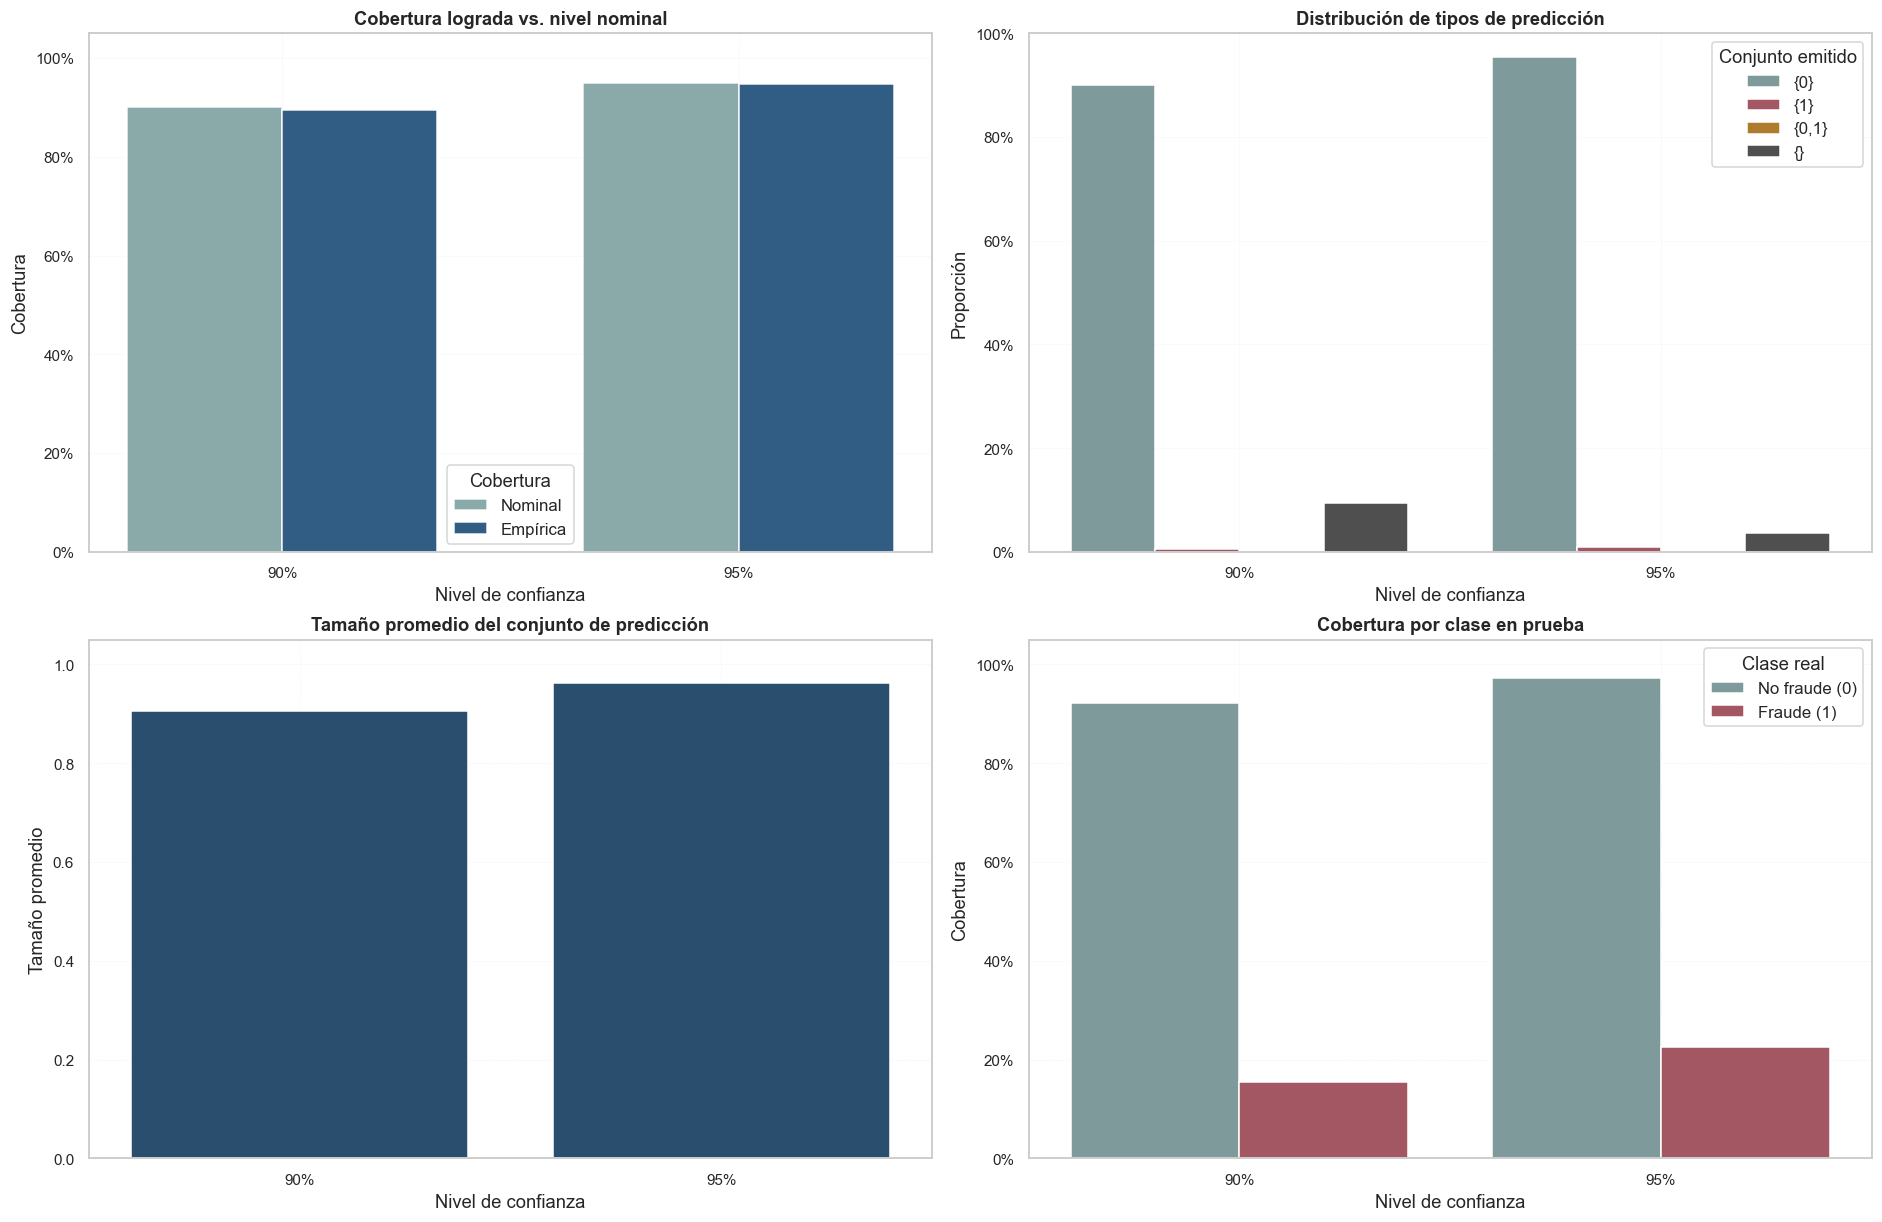

In [22]:
# Importaciones específicas para predicción conformal en clasificación binaria.
import gc
import warnings

try:
    from mapie.classification import SplitConformalClassifier
except ImportError as exc:
    raise ImportError(
        "La librería 'mapie' no está instalada. Instala las dependencias de requirements.txt antes de ejecutar esta sección."
    ) from exc


# Definición de niveles nominales de confianza para evaluar el componente de incertidumbre.
conformal_confidence_levels = [0.90, 0.95]
conformal_level_labels = {0.90: "90%", 0.95: "95%"}

# Selección del conjunto de conformalización: se toma el tramo más reciente de validación para mantener orden temporal.
# Se reserva el 40% final de validación para respetar el orden temporal y evitar utilizar prueba.
validation_key = list(split_frames.keys())[1]
validation_ordered_frame = split_frames[validation_key][["TransactionID", time_column, target_column]].copy()
validation_ordered_frame = validation_ordered_frame.sort_values(time_column)
conformal_split_index = int(len(validation_ordered_frame) * 0.60)
conformalization_index = validation_ordered_frame.index[conformal_split_index:]

# Resumen descriptivo del conjunto usado para conformalización.
conformalization_summary = pd.DataFrame(
    {
        "métrica": [
            "Observaciones en validación",
            "Observaciones usadas para conformalización",
            "Participación de conformalización",
            "Inicio del tramo de conformalización",
            "Fin del tramo de conformalización",
        ],
        "valor": [
            format_integer(len(validation_ordered_frame)),
            format_integer(len(conformalization_index)),
            format_percentage((len(conformalization_index) / len(validation_ordered_frame)) * 100),
            format_integer(int(validation_ordered_frame.loc[conformalization_index, time_column].min())),
            format_integer(int(validation_ordered_frame.loc[conformalization_index, time_column].max())),
        ],
    }
)
print("Resumen del conjunto de conformalización")
display(conformalization_summary.style.hide(axis="index"))

# MAPIE 1.3.0 opera de forma más estable con entradas densas en esta configuración binaria.
# Se construyen matrices densas temporales en float32 solo para la sección conformal.
X_conformal_dense = pd.DataFrame(
    X_validation_prepared[y_validation.index.get_indexer(conformalization_index)].toarray().astype("float32"),
    columns=prepared_feature_names,
    index=conformalization_index,
)
X_test_conformal_dense = pd.DataFrame(
    X_test_prepared.toarray().astype("float32"),
    columns=prepared_feature_names,
    index=y_test.index,
)
y_conformal = y_validation.loc[conformalization_index]

# Conformalización sobre el LightGBM ya entrenado: el componente de incertidumbre no reentrena el modelo principal.
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
        category=UserWarning,
    )
    lightgbm_conformal = SplitConformalClassifier(
        estimator=lightgbm_model,
        confidence_level=conformal_confidence_levels,
        conformity_score="lac",
        prefit=True,
    )
    lightgbm_conformal.conformalize(X_conformal_dense, y_conformal)
    conformal_point_predictions, conformal_prediction_sets = lightgbm_conformal.predict_set(X_test_conformal_dense)

conformal_prediction_sets = np.asarray(conformal_prediction_sets)
test_labels_array = y_test.to_numpy()
conformal_type_order = ["{0}", "{1}", "{0,1}", "{}"]


# Función auxiliar para transformar el vector booleano de un conjunto de predicción en una etiqueta legible.
def encode_prediction_set(binary_membership: np.ndarray) -> str:
    """Convierte un conjunto booleano de clases en una etiqueta textual."""

    left_class = bool(binary_membership[0])
    right_class = bool(binary_membership[1])
    if left_class and not right_class:
        return "{0}"
    if not left_class and right_class:
        return "{1}"
    if left_class and right_class:
        return "{0,1}"
    return "{}"


# Métricas conformales: resumen cobertura global, cobertura por clase y tipo de conjunto emitido para cada confianza.
conformal_metrics_rows = []
conformal_type_rows = []
conformal_class_rows = []
for level_position, confidence_level in enumerate(conformal_confidence_levels):
    prediction_membership = conformal_prediction_sets[:, :, level_position]
    set_size = prediction_membership.sum(axis=1)
    encoded_sets = pd.Series(
        [encode_prediction_set(row) for row in prediction_membership],
        name="tipo_conjunto",
    )

    coverage_empirical = prediction_membership[np.arange(len(test_labels_array)), test_labels_array].mean()
    singleton_rate = (set_size == 1).mean()
    ambiguous_rate = (set_size == 2).mean()
    empty_rate = (set_size == 0).mean()

    conformal_metrics_rows.append(
        {
            "Nivel nominal": conformal_level_labels[confidence_level],
            "Cobertura nominal": confidence_level,
            "Cobertura empírica": coverage_empirical,
            "Tamaño promedio del conjunto": set_size.mean(),
            "Predicciones puntuales": singleton_rate,
            "Predicciones ambiguas": ambiguous_rate,
            "Predicciones inconclusas": empty_rate,
        }
    )

    for class_value, class_label in [(0, "No fraude (0)"), (1, "Fraude (1)")]:
        class_mask = test_labels_array == class_value
        class_coverage = prediction_membership[class_mask, class_value].mean()
        conformal_class_rows.append(
            {
                "Nivel nominal": conformal_level_labels[confidence_level],
                "Clase real": class_label,
                "Cobertura por clase": class_coverage,
            }
        )

    type_distribution = encoded_sets.value_counts(normalize=True).reindex(conformal_type_order, fill_value=0.0)
    for prediction_type, proportion in type_distribution.items():
        conformal_type_rows.append(
            {
                "Nivel nominal": conformal_level_labels[confidence_level],
                "Tipo de predicción": prediction_type,
                "Proporción": proportion,
            }
        )


conformal_metrics = pd.DataFrame(conformal_metrics_rows)
conformal_metrics_display = conformal_metrics.copy()
for metric_name in [
    "Cobertura nominal",
    "Cobertura empírica",
    "Tamaño promedio del conjunto",
    "Predicciones puntuales",
    "Predicciones ambiguas",
    "Predicciones inconclusas",
]:
    conformal_metrics_display[metric_name] = conformal_metrics_display[metric_name].map(lambda value: f"{value:.4f}")

conformal_class_coverage = pd.DataFrame(conformal_class_rows)
conformal_class_display = conformal_class_coverage.copy()
conformal_class_display["Cobertura por clase"] = conformal_class_display["Cobertura por clase"].map(lambda value: f"{value:.4f}")

conformal_type_distribution = pd.DataFrame(conformal_type_rows)
conformal_type_distribution["Tipo de predicción"] = pd.Categorical(
    conformal_type_distribution["Tipo de predicción"],
    categories=conformal_type_order,
    ordered=True,
)
conformal_type_distribution = conformal_type_distribution.sort_values(
    by=["Nivel nominal", "Tipo de predicción"]
).reset_index(drop=True)
conformal_type_display = conformal_type_distribution.copy()
conformal_type_display["Proporción"] = conformal_type_display["Proporción"].map(lambda value: f"{value:.4f}")

print("Resumen del componente conformal en prueba")
display(conformal_metrics_display.style.hide(axis="index"))
print("\nCobertura por clase")
display(conformal_class_display.style.hide(axis="index"))
print("\nDistribución de tipos de predicción")
display(conformal_type_display.style.hide(axis="index"))

# Preparación de tablas auxiliares para visualización.
coverage_plot_frame = conformal_metrics[["Nivel nominal", "Cobertura nominal", "Cobertura empírica"]].copy()
set_size_plot_frame = conformal_metrics[["Nivel nominal", "Tamaño promedio del conjunto"]].copy()
type_distribution_plot = conformal_type_distribution.copy()
class_coverage_plot = conformal_class_coverage.copy()

# Visualización integrada del comportamiento conformal en prueba con una presentación simple y directa.
fig, axes = plt.subplots(2, 2, figsize=(17, 11), constrained_layout=True)

# Cobertura nominal y empírica por nivel de confianza.
coverage_x = np.arange(len(coverage_plot_frame))
bar_width = 0.34
axes[0, 0].bar(
    coverage_x - bar_width / 2,
    coverage_plot_frame["Cobertura nominal"],
    width=bar_width,
    color="#7a9e9f",
    alpha=0.88,
    label="Nominal",
)
axes[0, 0].bar(
    coverage_x + bar_width / 2,
    coverage_plot_frame["Cobertura empírica"],
    width=bar_width,
    color="#1f4e79",
    alpha=0.92,
    label="Empírica",
)
axes[0, 0].set_title("Cobertura lograda vs. nivel nominal", fontweight="semibold")
axes[0, 0].set_xticks(coverage_x)
axes[0, 0].set_xticklabels(coverage_plot_frame["Nivel nominal"])
axes[0, 0].set_xlabel("Nivel de confianza")
axes[0, 0].set_ylabel("Cobertura")
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0%}"))
axes[0, 0].legend(title="Cobertura")

# Distribución de tipos de predicción por nivel de confianza.
sns.barplot(
    data=type_distribution_plot,
    x="Nivel nominal",
    y="Proporción",
    hue="Tipo de predicción",
    hue_order=conformal_type_order,
    palette=["#7a9e9f", "#b04a5a", "#c47f17", "#4f4f4f"],
    ax=axes[0, 1],
)
axes[0, 1].set_title("Distribución de tipos de predicción", fontweight="semibold")
axes[0, 1].set_xlabel("Nivel de confianza")
axes[0, 1].set_ylabel("Proporción")
axes[0, 1].set_ylim(0, 1.0)
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0%}"))
axes[0, 1].legend(title="Conjunto emitido")

# Tamaño promedio del conjunto de predicción.
sns.barplot(
    data=set_size_plot_frame,
    x="Nivel nominal",
    y="Tamaño promedio del conjunto",
    color="#1f4e79",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Tamaño promedio del conjunto de predicción", fontweight="semibold")
axes[1, 0].set_xlabel("Nivel de confianza")
axes[1, 0].set_ylabel("Tamaño promedio")
axes[1, 0].set_ylim(0, 1.05)

# Cobertura por clase en prueba.
sns.barplot(
    data=class_coverage_plot,
    x="Nivel nominal",
    y="Cobertura por clase",
    hue="Clase real",
    palette=["#7a9e9f", "#b04a5a"],
    ax=axes[1, 1],
)
axes[1, 1].set_title("Cobertura por clase en prueba", fontweight="semibold")
axes[1, 1].set_xlabel("Nivel de confianza")
axes[1, 1].set_ylabel("Cobertura")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0%}"))
axes[1, 1].legend(title="Clase real")

for axis in axes.flatten():
    axis.grid(alpha=0.18, linestyle="--", linewidth=0.5)
    axis.tick_params(labelsize=10)

plt.show()

# Liberación explícita de las matrices densas temporales usadas por MAPIE.
del X_conformal_dense, X_test_conformal_dense
_ = gc.collect()


La cobertura global queda razonablemente cerca del nivel nominal en `90%` y `95%`, lo que indica que el procedimiento conformal preserva una garantía agregada útil sobre el conjunto de prueba. Sin embargo, esa garantía no se distribuye de manera homogénea: la cobertura de `Fraude (1)` es claramente menor que la de `No fraude (0)`, lo que refleja la dificultad del problema y el peso del desbalance de clases.

Al comparar `90%` frente a `95%`, la confianza más alta incrementa la cobertura global y reduce las salidas inconclusas `{}`, pero lo hace con un conjunto promedio ligeramente mayor. En esta configuración con `lac`, la incertidumbre aparece sobre todo como abstención `{}` y no como ambigüedad `{0,1}`, por lo que el componente conformal funciona más como un mecanismo de cautela que como una expansión explícita del conjunto de clases plausibles.

**Cobertura lograda vs. nivel nominal.** Este gráfico compara el objetivo teórico de cobertura con la cobertura observada en prueba. Su lectura principal es que el procedimiento se aproxima bien al nivel nominal, aunque con pequeñas desviaciones esperables en evaluación finita.

**Distribución de tipos de predicción.** Este bloque muestra qué proporción de observaciones recibe `{0}`, `{1}`, `{0,1}` o `{}`. El hallazgo central es que predominan las decisiones puntuales y que la incertidumbre se expresa casi exclusivamente como abstención `{}`.

**Tamaño promedio del conjunto.** Este gráfico resume cuántas etiquetas incluye, en promedio, cada conjunto conformal. Debe interpretarse junto con la cobertura: al subir la confianza, el tamaño medio crece ligeramente, lo que indica una decisión algo menos específica.

**Cobertura por clase.** Aquí se observa si la garantía conformal se reparte de forma equilibrada entre `No fraude (0)` y `Fraude (1)`. La diferencia marcada entre ambas clases es el resultado más importante desde el punto de vista aplicado, porque muestra que la incertidumbre protege mucho mejor la clase mayoritaria que la minoritaria.

En fraude, este comportamiento es relevante porque permite distinguir entre transacciones con decisión puntual y casos donde conviene abstenerse o escalar a revisión. La utilidad práctica del componente no está solo en cubrir el nivel nominal, sino en señalar cuándo el modelo no sostiene una decisión suficientemente confiable sobre una operación.


### 14.2 Lectura crítica del componente de incertidumbre

La predicción conformal aporta una capa moderna de incertidumbre que las probabilidades por sí solas no entregan: transforma el score del modelo en conjuntos de decisión con cobertura verificable de forma empírica. Esto enriquece el proyecto porque introduce una salida operacional más prudente que la clasificación puntual simple.

La principal limitación observada es que, bajo `mapie` y el puntaje `lac` válido para este caso binario, la incertidumbre aparece sobre todo como conjunto vacío `{}` y no como conjunto ambiguo `{0,1}`. Además, la cobertura por clase resulta muy desigual: la clase no fraude queda mucho mejor cubierta que la clase fraude, lo que refleja el efecto del fuerte desbalance y del comportamiento base del modelo.

Los casos inciertos, por tanto, no son necesariamente los más fraudulentos, sino aquellos para los que el procedimiento conformal no logra sostener una etiqueta suficientemente confiable. Aun con ese límite, esta salida sigue siendo valiosa porque permite distinguir entre decisiones puntuales y decisiones que conviene tratar con cautela, algo que el score clásico no expresa de forma explícita.


## 15. Análisis de errores y robustez del modelo principal

El desempeño agregado resume la capacidad promedio del modelo, pero no muestra dónde falla ni si esos fallos se concentran en segmentos específicos del problema. En detección de fraude, esta lectura es importante porque un modelo puede exhibir métricas globales competitivas y, al mismo tiempo, conservar debilidades relevantes en ciertos montos, ventanas temporales o perfiles transaccionales.

Por ello se examina la estructura de errores de LightGBM sobre el conjunto de prueba y su estabilidad relativa en segmentos interpretables del dataset original. Para mantener comparabilidad con la evaluación principal, se utiliza la predicción puntual del modelo con umbral estándar de `0.5`. Este bloque fortalece el cierre técnico del proyecto porque conecta desempeño, heterogeneidad del error y cautela metodológica en una sola lectura aplicada.


Tipología básica de resultados de LightGBM en prueba


Tipo de resultado,Cantidad,Proporción sobre prueba,Participación dentro de errores
Verdaderos positivos,"1,108",1.26%,-
Verdaderos negativos,"84,748",96.22%,-
Falsos positivos,267,0.30%,12.01%
Falsos negativos,"1,957",2.22%,87.99%



Resumen por rangos de TransactionAmt


Rango de monto,Observaciones,Participación en prueba,Fraudes observados,Tasa de fraude,Error total,Falsos positivos,Falsos negativos,Recall del fraude
Rango 1: 0 - 44,"22,026",25.01%,"1,052",4.78%,2.92%,112,532,49.43%
Rango 2: 44 - 68,"22,062",25.05%,519,2.35%,1.90%,22,398,23.31%
Rango 3: 68 - 117,"22,172",25.17%,620,2.80%,2.26%,49,452,27.10%
Rango 4: 117 - 265,"13,077",14.85%,426,3.26%,2.32%,38,266,37.56%
"Rango 5: 265 - 5,367","8,743",9.93%,448,5.12%,4.06%,46,309,31.03%



Resumen por bloques temporales


...

ProductCD,Observaciones,Participación en prueba,Fraudes observados,Tasa de fraude,Error total,Falsos positivos,Falsos negativos,Recall del fraude
W,"69,023",78.36%,"1,286",1.86%,1.85%,56,"1,218",5.29%
C,"9,369",10.64%,"1,268",13.53%,6.97%,168,485,61.75%
R,"4,178",4.74%,210,5.03%,1.84%,16,61,70.95%
S,"2,961",3.36%,144,4.86%,3.41%,4,97,32.64%
H,"2,549",2.89%,157,6.16%,4.67%,23,96,38.85%



Resumen por DeviceType


DeviceType,Observaciones,Participación en prueba,Fraudes observados,Tasa de fraude,Error total,Falsos positivos,Falsos negativos,Recall del fraude
Sin información,"69,953",79.42%,"1,349",1.93%,1.88%,60,"1,258",6.75%
desktop,"10,427",11.84%,794,7.61%,3.65%,84,297,62.59%
mobile,"7,700",8.74%,922,11.97%,6.82%,123,402,56.40%



Lectura comparativa de robustez entre segmentos


Dimensión,Rango del error total,Rango del recall fraude,Segmento con mayor error,Segmento con menor recall
Rangos de TransactionAmt,1.90% - 4.06%,23.31% - 49.43%,"Rango 5: 265 - 5,367",Rango 2: 44 - 68
Bloques temporales,1.97% - 2.96%,31.38% - 42.06%,Bloque 6,Bloque 3
ProductCD,1.84% - 6.97%,5.29% - 70.95%,C,W
DeviceType,1.88% - 6.82%,6.75% - 62.59%,mobile,Sin información


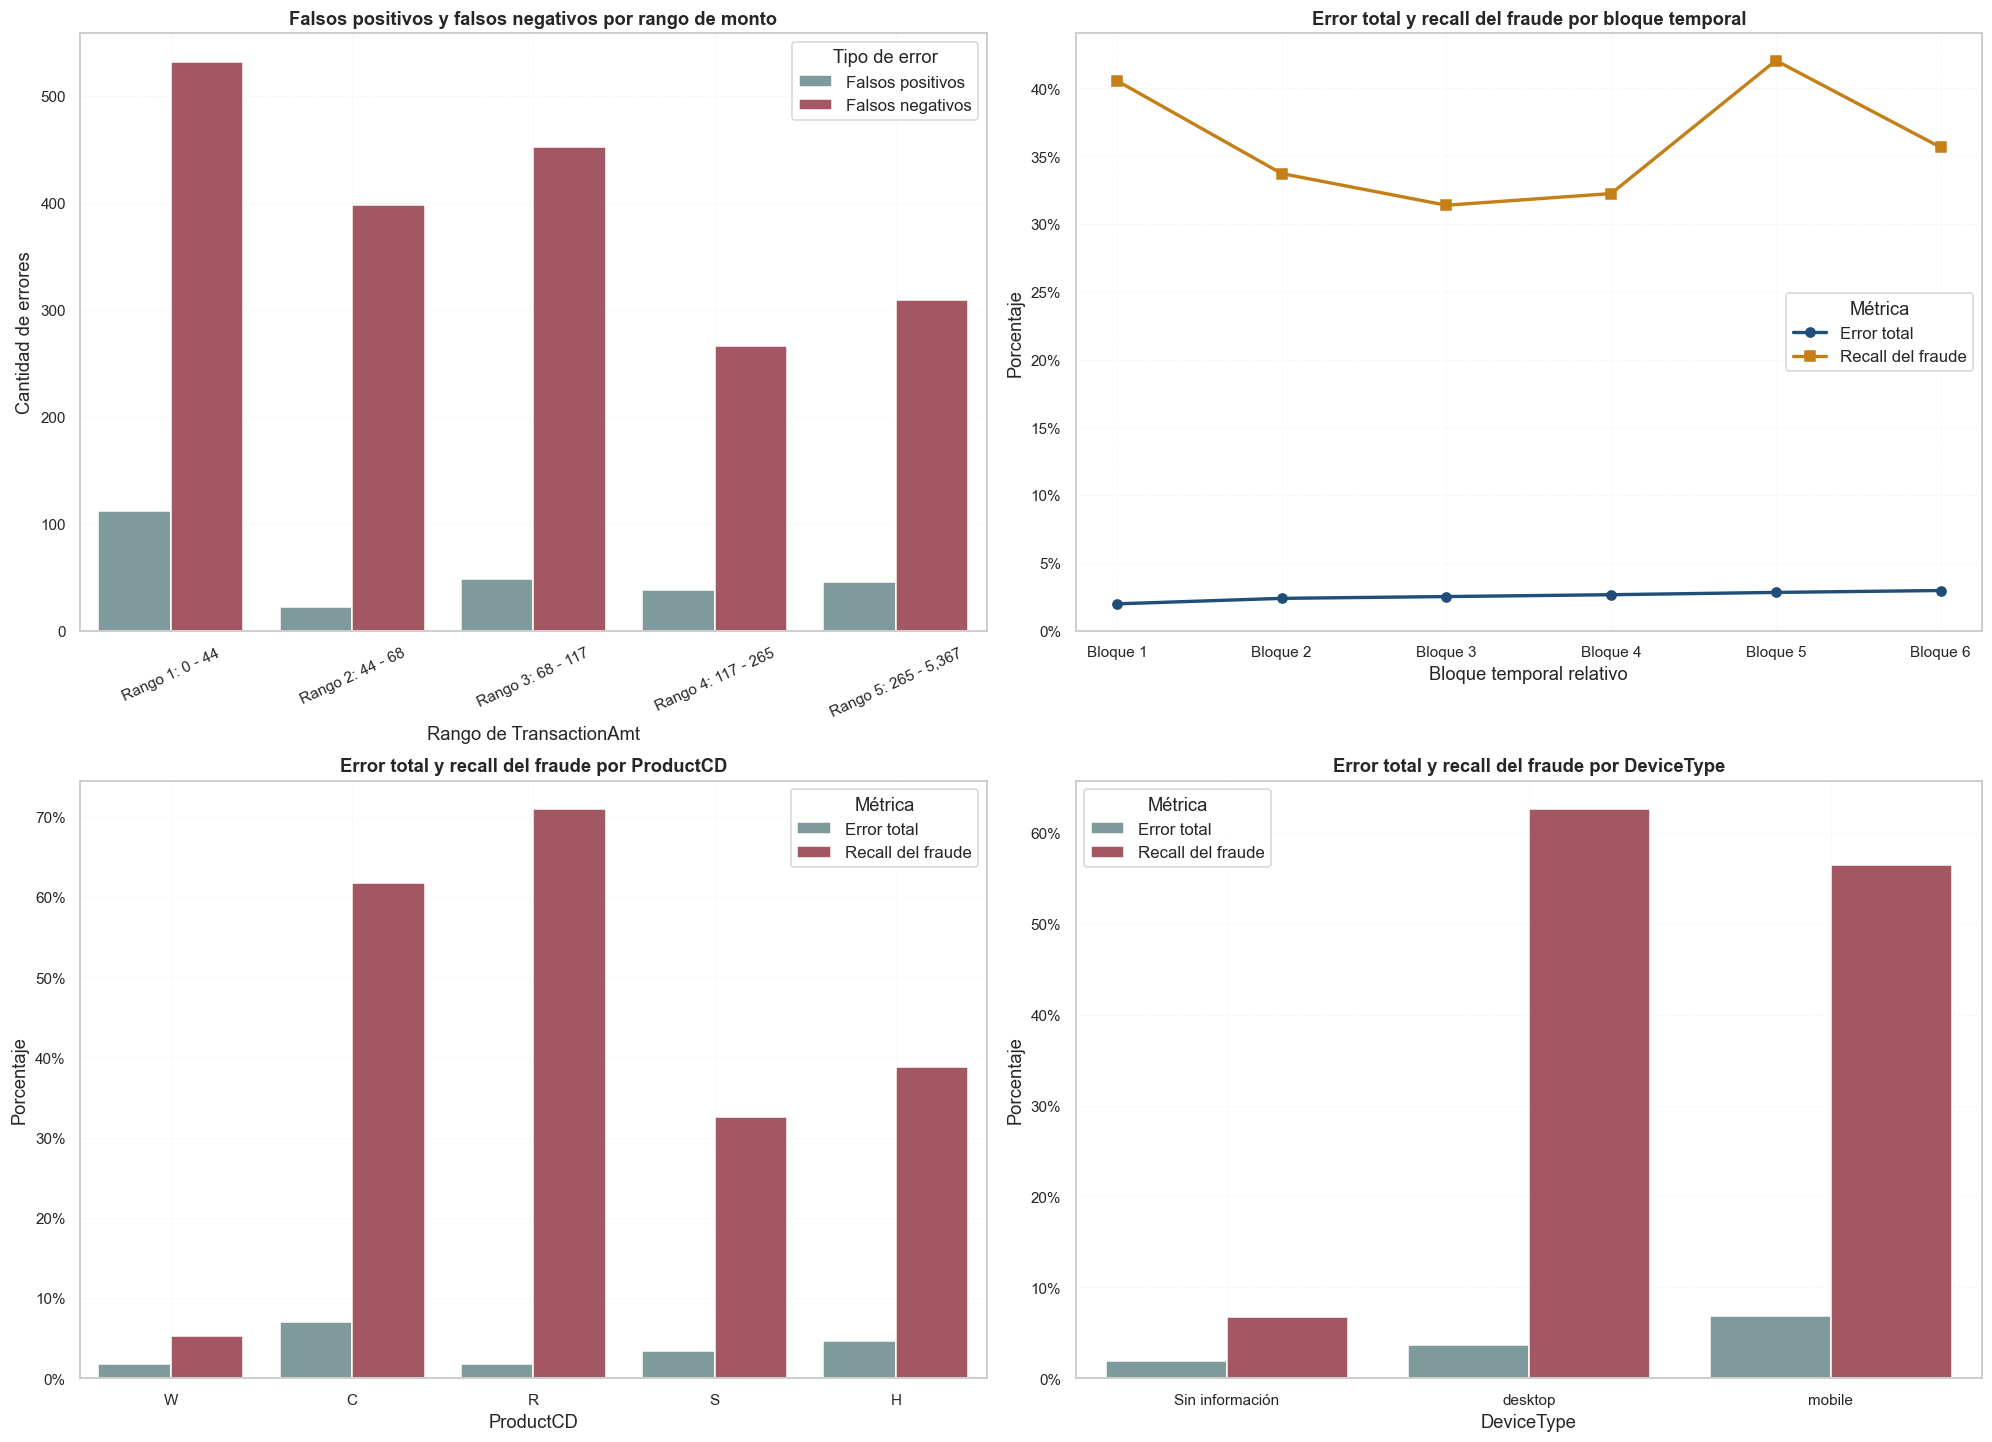

In [23]:
# Base de errores en prueba: combina variables originales, probabilidades y predicciones de LightGBM para análisis segmentado.
lightgbm_error_analysis = split_frames["Prueba"].copy()
lightgbm_error_analysis["prediccion_lightgbm"] = lightgbm_test_pred
lightgbm_error_analysis["probabilidad_lightgbm"] = lightgbm_test_score

# Tipología de resultados: separa verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.
result_conditions = [
    (lightgbm_error_analysis[target_column] == 1) & (lightgbm_error_analysis["prediccion_lightgbm"] == 1),
    (lightgbm_error_analysis[target_column] == 0) & (lightgbm_error_analysis["prediccion_lightgbm"] == 0),
    (lightgbm_error_analysis[target_column] == 0) & (lightgbm_error_analysis["prediccion_lightgbm"] == 1),
    (lightgbm_error_analysis[target_column] == 1) & (lightgbm_error_analysis["prediccion_lightgbm"] == 0),
]
result_labels = [
    "Verdaderos positivos",
    "Verdaderos negativos",
    "Falsos positivos",
    "Falsos negativos",
]
lightgbm_error_analysis["tipo_resultado"] = np.select(
    result_conditions,
    result_labels,
    default="No clasificado",
)

# Función auxiliar para construir rangos de monto legibles usando cuantiles del conjunto de prueba.
def build_amount_segments(amount_series: pd.Series) -> pd.Series:
    """Genera segmentos ordenados de TransactionAmt con etiquetas interpretables."""

    quantile_edges = amount_series.quantile([0.00, 0.25, 0.50, 0.75, 0.90, 1.00]).to_numpy()
    unique_edges = np.unique(quantile_edges)

    if len(unique_edges) < 3:
        fallback_edges = np.unique(np.linspace(amount_series.min(), amount_series.max(), 6))
        unique_edges = fallback_edges

    if len(unique_edges) < 3:
        return pd.Series(["Monto único"] * len(amount_series), index=amount_series.index, dtype="object")

    labels = [
        f"Rango {position}: {left:,.0f} - {right:,.0f}"
        for position, (left, right) in enumerate(zip(unique_edges[:-1], unique_edges[1:]), start=1)
    ]
    return pd.cut(
        amount_series,
        bins=unique_edges,
        labels=labels,
        include_lowest=True,
    )


# Función auxiliar para resumir estabilidad por segmento: error total, falsos positivos, falsos negativos y recall del fraude.
def summarize_segment_errors(frame: pd.DataFrame, segment_column: str, order: list[str] | None = None) -> pd.DataFrame:
    """Resume el comportamiento del modelo en un segmento interpretable del conjunto de prueba."""

    rows = []
    grouped = frame.groupby(segment_column, dropna=False)
    for segment_name, segment_df in grouped:
        segment_label = "Sin información" if pd.isna(segment_name) else str(segment_name)
        observations = len(segment_df)
        fraud_count = int(segment_df[target_column].sum())
        fp_count = int(
            ((segment_df[target_column] == 0) & (segment_df["prediccion_lightgbm"] == 1)).sum()
        )
        fn_count = int(
            ((segment_df[target_column] == 1) & (segment_df["prediccion_lightgbm"] == 0)).sum()
        )
        tp_count = int(
            ((segment_df[target_column] == 1) & (segment_df["prediccion_lightgbm"] == 1)).sum()
        )
        error_count = int((segment_df[target_column] != segment_df["prediccion_lightgbm"]).sum())

        rows.append(
            {
                "segmento": segment_label,
                "observaciones": observations,
                "participacion_prueba_pct": (observations / len(frame)) * 100,
                "fraudes_observados": fraud_count,
                "tasa_fraude_pct": (fraud_count / observations) * 100,
                "error_total_pct": (error_count / observations) * 100,
                "falsos_positivos": fp_count,
                "falsos_negativos": fn_count,
                "recall_fraude_pct": (tp_count / fraud_count) * 100 if fraud_count > 0 else np.nan,
            }
        )

    summary = pd.DataFrame(rows)
    if order is not None:
        summary["segmento"] = pd.Categorical(summary["segmento"], categories=order, ordered=True)
        summary = summary.sort_values("segmento").reset_index(drop=True)
        summary["segmento"] = summary["segmento"].astype(str)
    return summary


# Segmentación por rangos de monto y por bloques temporales uniformes dentro de prueba.
lightgbm_error_analysis["segmento_monto"] = build_amount_segments(lightgbm_error_analysis["TransactionAmt"])
amount_order = (
    [str(category) for category in lightgbm_error_analysis["segmento_monto"].cat.categories]
    if hasattr(lightgbm_error_analysis["segmento_monto"], "cat")
    else sorted(lightgbm_error_analysis["segmento_monto"].astype(str).unique().tolist())
)

time_block_labels = [f"Bloque {block_id}" for block_id in range(1, 7)]
lightgbm_error_analysis["bloque_temporal"] = pd.cut(
    lightgbm_error_analysis["TransactionDT"],
    bins=len(time_block_labels),
    labels=time_block_labels,
    include_lowest=True,
)
time_order = time_block_labels

# Segmentación categórica priorizando variables interpretables del dataset original.
lightgbm_error_analysis["ProductCD_segmento"] = lightgbm_error_analysis["ProductCD"].fillna("Sin información")
product_order = lightgbm_error_analysis["ProductCD_segmento"].value_counts().index.tolist()

if "DeviceType" in lightgbm_error_analysis.columns and lightgbm_error_analysis["DeviceType"].notna().mean() >= 0.10:
    secondary_segment_column = "DeviceType_segmento"
    secondary_segment_title = "DeviceType"
    lightgbm_error_analysis[secondary_segment_column] = lightgbm_error_analysis["DeviceType"].fillna("Sin información")
else:
    secondary_segment_column = "card4_segmento"
    secondary_segment_title = "card4"
    lightgbm_error_analysis[secondary_segment_column] = lightgbm_error_analysis["card4"].fillna("Sin información")
secondary_order = lightgbm_error_analysis[secondary_segment_column].value_counts().index.tolist()

# Resumen cuantitativo de la tipología global de resultados en prueba.
total_errors = int(lightgbm_error_analysis["tipo_resultado"].isin(["Falsos positivos", "Falsos negativos"]).sum())
error_typology = pd.DataFrame(
    [
        {
            "tipo_resultado": result_name,
            "cantidad": int((lightgbm_error_analysis["tipo_resultado"] == result_name).sum()),
        }
        for result_name in result_labels
    ]
)
error_typology["proporcion_prueba_pct"] = (error_typology["cantidad"] / len(lightgbm_error_analysis)) * 100
error_typology["participacion_en_errores_pct"] = error_typology.apply(
    lambda row: (row["cantidad"] / total_errors) * 100
    if row["tipo_resultado"] in ["Falsos positivos", "Falsos negativos"]
    else np.nan,
    axis=1,
)
error_typology_display = error_typology.copy().rename(
    columns={
        "tipo_resultado": "Tipo de resultado",
        "cantidad": "Cantidad",
        "proporcion_prueba_pct": "Proporción sobre prueba",
        "participacion_en_errores_pct": "Participación dentro de errores",
    }
)
error_typology_display["Cantidad"] = error_typology_display["Cantidad"].map(format_integer)
error_typology_display["Proporción sobre prueba"] = error_typology_display["Proporción sobre prueba"].map(format_percentage)
error_typology_display["Participación dentro de errores"] = error_typology_display[
    "Participación dentro de errores"
].map(lambda value: "-" if pd.isna(value) else format_percentage(value))

# Resúmenes por segmentos para monto, tiempo y categorías interpretables.
amount_error_summary = summarize_segment_errors(lightgbm_error_analysis, "segmento_monto", order=amount_order)
time_error_summary = summarize_segment_errors(lightgbm_error_analysis, "bloque_temporal", order=time_order)
product_error_summary = summarize_segment_errors(lightgbm_error_analysis, "ProductCD_segmento", order=product_order)
secondary_error_summary = summarize_segment_errors(
    lightgbm_error_analysis,
    secondary_segment_column,
    order=secondary_order,
)


# Función auxiliar para preparar tablas de lectura en el notebook.
def format_segment_display(summary: pd.DataFrame, segment_label: str) -> pd.DataFrame:
    """Devuelve una versión formateada y legible del resumen por segmento."""

    display_frame = summary.copy().rename(
        columns={
            "segmento": segment_label,
            "observaciones": "Observaciones",
            "participacion_prueba_pct": "Participación en prueba",
            "fraudes_observados": "Fraudes observados",
            "tasa_fraude_pct": "Tasa de fraude",
            "error_total_pct": "Error total",
            "falsos_positivos": "Falsos positivos",
            "falsos_negativos": "Falsos negativos",
            "recall_fraude_pct": "Recall del fraude",
        }
    )

    for column_name in ["Observaciones", "Fraudes observados", "Falsos positivos", "Falsos negativos"]:
        display_frame[column_name] = display_frame[column_name].map(format_integer)

    for column_name in ["Participación en prueba", "Tasa de fraude", "Error total", "Recall del fraude"]:
        display_frame[column_name] = display_frame[column_name].map(
            lambda value: "-" if pd.isna(value) else format_percentage(value)
        )

    return display_frame


amount_error_display = format_segment_display(amount_error_summary, "Rango de monto")
time_error_display = format_segment_display(time_error_summary, "Bloque temporal")
product_error_display = format_segment_display(product_error_summary, "ProductCD")
secondary_error_display = format_segment_display(secondary_error_summary, secondary_segment_title)

# Resumen breve de robustez para comparar la amplitud del error entre dimensiones analíticas.
def build_robustness_row(summary: pd.DataFrame, dimension_label: str) -> dict:
    """Construye una fila comparativa de robustez a partir de una dimensión segmentada."""

    highest_error_row = summary.sort_values(["error_total_pct", "observaciones"], ascending=[False, False]).iloc[0]
    recall_candidates = summary.dropna(subset=["recall_fraude_pct"]).copy()
    lowest_recall_row = recall_candidates.sort_values(
        ["recall_fraude_pct", "observaciones"],
        ascending=[True, False],
    ).iloc[0]

    return {
        "Dimensión": dimension_label,
        "Rango del error total": f"{summary['error_total_pct'].min():.2f}% - {summary['error_total_pct'].max():.2f}%",
        "Rango del recall fraude": f"{summary['recall_fraude_pct'].min():.2f}% - {summary['recall_fraude_pct'].max():.2f}%",
        "Segmento con mayor error": str(highest_error_row["segmento"]),
        "Segmento con menor recall": str(lowest_recall_row["segmento"]),
    }


robustness_summary = pd.DataFrame(
    [
        build_robustness_row(amount_error_summary, "Rangos de TransactionAmt"),
        build_robustness_row(time_error_summary, "Bloques temporales"),
        build_robustness_row(product_error_summary, "ProductCD"),
        build_robustness_row(secondary_error_summary, secondary_segment_title),
    ]
)

print("Tipología básica de resultados de LightGBM en prueba")
display(error_typology_display.style.hide(axis="index"))

print("\nResumen por rangos de TransactionAmt")
display(amount_error_display.style.hide(axis="index"))

print("\nResumen por bloques temporales")
display(time_error_display.style.hide(axis="index"))

print("\nResumen por ProductCD")
display(product_error_display.style.hide(axis="index"))

print(f"\nResumen por {secondary_segment_title}")
display(secondary_error_display.style.hide(axis="index"))

print("\nLectura comparativa de robustez entre segmentos")
display(robustness_summary.style.hide(axis="index"))

# Preparación de tablas en formato largo para construir gráficos comparativos sobrios y legibles.
amount_error_plot = amount_error_summary.melt(
    id_vars="segmento",
    value_vars=["falsos_positivos", "falsos_negativos"],
    var_name="tipo_error",
    value_name="cantidad",
)
amount_error_plot["tipo_error"] = amount_error_plot["tipo_error"].map(
    {
        "falsos_positivos": "Falsos positivos",
        "falsos_negativos": "Falsos negativos",
    }
)

product_metric_plot = product_error_summary.melt(
    id_vars="segmento",
    value_vars=["error_total_pct", "recall_fraude_pct"],
    var_name="métrica",
    value_name="porcentaje",
)
product_metric_plot["métrica"] = product_metric_plot["métrica"].map(
    {
        "error_total_pct": "Error total",
        "recall_fraude_pct": "Recall del fraude",
    }
)

secondary_metric_plot = secondary_error_summary.melt(
    id_vars="segmento",
    value_vars=["error_total_pct", "recall_fraude_pct"],
    var_name="métrica",
    value_name="porcentaje",
)
secondary_metric_plot["métrica"] = secondary_metric_plot["métrica"].map(
    {
        "error_total_pct": "Error total",
        "recall_fraude_pct": "Recall del fraude",
    }
)

# Bloque gráfico integrado para examinar errores y estabilidad por segmentos clave.
fig, axes = plt.subplots(2, 2, figsize=(18, 13), constrained_layout=True)

sns.barplot(
    data=amount_error_plot,
    x="segmento",
    y="cantidad",
    hue="tipo_error",
    palette=["#7a9e9f", "#b04a5a"],
    ax=axes[0, 0],
)
axes[0, 0].set_title("Falsos positivos y falsos negativos por rango de monto", fontweight="semibold")
axes[0, 0].set_xlabel("Rango de TransactionAmt")
axes[0, 0].set_ylabel("Cantidad de errores")
axes[0, 0].tick_params(axis="x", rotation=25)
axes[0, 0].legend(title="Tipo de error")

axes[0, 1].plot(
    time_error_summary["segmento"],
    time_error_summary["error_total_pct"],
    marker="o",
    linewidth=2.2,
    color="#1f4e79",
    label="Error total",
)
axes[0, 1].plot(
    time_error_summary["segmento"],
    time_error_summary["recall_fraude_pct"],
    marker="s",
    linewidth=2.2,
    color="#c47f17",
    label="Recall del fraude",
)
axes[0, 1].set_title("Error total y recall del fraude por bloque temporal", fontweight="semibold")
axes[0, 1].set_xlabel("Bloque temporal relativo")
axes[0, 1].set_ylabel("Porcentaje")
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0f}%"))
axes[0, 1].legend(title="Métrica")

sns.barplot(
    data=product_metric_plot,
    x="segmento",
    y="porcentaje",
    hue="métrica",
    palette=["#7a9e9f", "#b04a5a"],
    ax=axes[1, 0],
)
axes[1, 0].set_title("Error total y recall del fraude por ProductCD", fontweight="semibold")
axes[1, 0].set_xlabel("ProductCD")
axes[1, 0].set_ylabel("Porcentaje")
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0f}%"))
axes[1, 0].legend(title="Métrica")

sns.barplot(
    data=secondary_metric_plot,
    x="segmento",
    y="porcentaje",
    hue="métrica",
    palette=["#7a9e9f", "#b04a5a"],
    ax=axes[1, 1],
)
axes[1, 1].set_title(f"Error total y recall del fraude por {secondary_segment_title}", fontweight="semibold")
axes[1, 1].set_xlabel(secondary_segment_title)
axes[1, 1].set_ylabel("Porcentaje")
axes[1, 1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.0f}%"))
axes[1, 1].legend(title="Métrica")

for axis in axes.flatten():
    axis.grid(alpha=0.18, linestyle="--", linewidth=0.5)
    axis.tick_params(labelsize=10)

plt.show()


### 15.1 Lectura de errores por segmentos

La tipología básica de resultados en prueba muestra que el costo principal del modelo no es sobredetectar fraude, sino dejarlo escapar: los falsos negativos superan con amplitud a los falsos positivos. Esta asimetría es coherente con las métricas ya observadas y confirma que, aun con una mejora clara frente al baseline, la recuperación de la clase positiva sigue siendo el punto más exigente del problema.

Por rango de monto, los errores no se distribuyen de forma uniforme. El tramo superior concentra la mayor tasa de error, pero también se observa una carga importante de falsos negativos en montos bajos por efecto del volumen de transacciones. Esto sugiere que el fraude no se restringe a una sola banda monetaria y que el modelo enfrenta dificultades distintas según la escala transaccional observada.

En la dimensión temporal aparece una señal de heterogeneidad moderada: la tasa de error tiende a aumentar hacia los bloques más recientes del conjunto de prueba, mientras el recall del fraude fluctúa entre ventanas. Esta lectura es compatible con un fenómeno transaccional cambiante, donde el modelo conserva capacidad de ranking, pero no mantiene una sensibilidad homogénea en todo el tramo cronológico evaluado.

En las variables categóricas, la comparación entre frecuencia y riesgo resulta especialmente importante. Segmentos como `ProductCD = W` o el grupo `Sin información` en `DeviceType` pueden exhibir error total relativamente bajo por el peso dominante de no fraude, pero al mismo tiempo mostrar un recall del fraude claramente débil. En sentido contrario, segmentos como `ProductCD = C` o el tráfico `mobile` presentan un costo de error más alto, aunque con una recuperación del fraude comparativamente mejor.

### 15.2 Robustez del comportamiento por segmentos

La tabla comparativa de robustez sugiere que el comportamiento del modelo es más estable por bloques temporales que por producto o dispositivo, donde los rangos de error total y recall del fraude son sensiblemente más amplios. En otras palabras, LightGBM no se comporta de manera uniforme en todo el espacio operativo del dataset.

La lectura prudente es que el modelo principal mejora el desempeño agregado y ofrece una base sólida de decisión, pero conserva segmentos claramente más frágiles, sobre todo cuando domina la información incompleta o cuando ciertas categorías concentran perfiles transaccionales atípicos. Este hallazgo fortalece la evaluación final del proyecto porque desplaza la atención desde el promedio global hacia la robustez real del comportamiento predictivo.


## 16. Conclusiones

### 16.1 Hallazgos principales

El análisis exploratorio mostró desde el inicio un problema estructuralmente exigente: fuerte desbalance de clases, incompletitud elevada, cobertura parcial de variables de identidad y heterogeneidad temporal del comportamiento transaccional. Esa lectura justificó tanto la unión cuidadosa de tablas como la necesidad de una partición cronológica y de un pipeline reproducible que evitara fuga de información.

Sobre esa base, la comparación de modelos fue metodológicamente consistente. El `DummyClassifier` estableció una referencia mínima, la regresión logística confirmó que el espacio transformado contiene señal útil y LightGBM aportó la mejora principal en ranking y recuperación de fraude. Sin embargo, el análisis de errores muestra que esa ganancia no elimina la asimetría del problema: los falsos negativos siguen dominando y el desempeño cambia de forma visible entre montos, bloques temporales y segmentos categóricos.

La explicabilidad con SHAP añadió trazabilidad sobre el modelo principal al destacar variables transaccionales, temporales y agregados de comportamiento como fuentes dominantes de señal. La calibración mostró que las probabilidades originales de LightGBM ya eran razonablemente utilizables y que la corrección isotónica no mejoró su confiabilidad en prueba. La predicción conformal, por su parte, incorporó una salida de incertidumbre útil para distinguir decisiones puntuales de abstenciones, aunque con una cobertura por clase claramente más favorable para no fraude que para fraude.

### 16.2 Limitaciones del estudio

Las limitaciones observadas son relevantes y deben mantenerse explícitas. El problema conserva un fuerte desbalance de clases, una estructura temporal no estacionaria y un volumen considerable de variables muy incompletas, incluso después de la depuración inicial. Además, la cobertura parcial de identidad limita la uniformidad descriptiva entre transacciones y genera segmentos donde la ausencia de información se vuelve parte del problema analítico.

Desde la perspectiva del modelo, LightGBM mejora de forma clara al baseline, pero no resuelve por completo la detección de fraude: persiste una cantidad importante de falsos negativos, la sensibilidad cambia entre segmentos y la interpretación de importancias o contribuciones no debe confundirse con causalidad. De manera similar, la cobertura conformal global cercana al nivel nominal no implica una protección homogénea por clase, y la calibración adecuada en promedio no equivale a confiabilidad perfecta en cada subconjunto operativo.

### 16.3 Valor metodológico del proyecto

El principal valor del proyecto reside en la construcción de un flujo analítico trazable, reproducible y defendible. El notebook integra auditoría estructural, análisis exploratorio, partición temporal, preprocesamiento explícito, comparación de modelos, explicabilidad, calibración, análisis de umbral y una capa moderna de incertidumbre sin fragmentar la lógica metodológica.
